# Report Data Analysis

## 1. libraries

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from tqdm import tqdm 
import time
from datetime import datetime, timedelta, timezone, date
import datetime as dt
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import force_defs as force_defs
#import ir_defs.ipynb as ir_defs
import math
importlib.reload(force_defs)


<module 'force_defs' from 'c:\\Users\\kmh\\Documents\\GitHub\\shed-tits\\force_defs.py'>

In [2]:
importlib.reload(force_defs)
print(dir(force_defs))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'append_csv_files', 'append_force_text_files', 'apply_butterfilt', 'assign', 'butter_filt', 'compute_Ftotal', 'convert_time_IR', 'convert_time_force', 'convert_time_rfid', 'datetime', 'describe_FTs', 'detect_bw_Ftot', 'detect_bw_Fx', 'detect_plateaus', 'fft', 'fftfreq', 'find_and_filter_sequence', 'firstbroken', 'full_merge_Frfid', 'full_merge_irfid', 'get_force', 'get_impulse', 'get_longest_continuous_block', 'halve_frame', 'halve_frame2', 'irfid_allign', 'isolate_takeoff', 'match_keys_preparation', 'match_keys_preparation_0216', 'match_visits_force', 'match_visits_irfid', 'np', 'os', 'pd', 'plt', 'process_row', 'return_bw_Ftot', 'scare_control', 'scare_ordering', 'signal', 'sns', 'speed_calculation', 'sys', 'time', 'timedelta', 'timezone', 'tqdm', 'tqdm_notebook', 'zero_centering']


## 2. RFID prep

### 2.1 all experiment days 
- appended RFIDs for experimental days

##### SCARE read
- 'SCARE' is all the scare files appended, has 'scare_outcome' which 'RFID_match' does not have

In [27]:
#remake SCARE 
folder_path = 'C:\\Users\\kmh\\Documents\\DATA\\2024-5\\RFID\\SCARE'
output_file = 'SCARE.csv'

force_defs.append_csv_files(folder_path, output_file)

In [2]:
#cheeky direct formating at the csv. 
SCARE = pd.read_csv('SCARE.csv') #somehow this still leaves out Dec23 and Jan24
SCARE['date'].unique()
#don't know why but need to open the csv ad format the date into 'yyyy-mm-dd' format

array(['2024-12-12', '2024-12-15', '2024-12-23', '2024-12-31',
       '2025-01-03', '2025-01-21', '2025-01-24', '2025-01-30',
       '2025-02-06', '2025-02-12', '2025-02-16', '2025-02-19'],
      dtype=object)

In [5]:
Dec12 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2024-12-12_SCARE.csv', index_col = 0)
Dec15 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2024-12-15_SCARE.csv', index_col = 0)
Dec23 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2024-12-23_SCARE.csv', index_col = 0)
Dec31 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2024-12-31_SCARE.csv', index_col = 0)
Jan3 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-01-03_SCARE.csv', index_col = 0)
Jan21 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-01-21_SCARE.csv', index_col = 0)
Jan24 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-01-24_SCARE.csv', index_col = 0)
Jan30 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-01-30_SCARE.csv', index_col = 0)
Feb6 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-02-06_SCARE.csv', index_col = 0)
Feb12 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-02-12_SCARE.csv', index_col = 0)
Feb16 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-02-16_SCARE.csv', index_col = 0)
Feb19 = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\RFID\SCARE\2025-02-19_SCARE.csv', index_col = 0)


In [6]:
print(Dec12.head(3))
print(Dec15.head(3))
print(Dec23.head(3))
print(Dec31.head(3))
print(Jan3.head(3))
print(Jan21.head(3))
print(Jan24.head(3))
print(Jan30.head(3))
print(Feb6.head(3))
print(Feb12.head(3))
print(Feb16.head(3))
print(Feb19.head(3))


                  visit scare_control    group        date             time  \
id                                                                            
3B00185CB8  first visit           nah  control  12/12/2024  09:09:28:584496   
3B00485E69  first visit           nah  control  12/12/2024  09:10:00:774473   
3B0018A99B  first visit           nah  control  12/12/2024  09:10:06:270987   

            scare_outcome  
id                         
3B00185CB8            0.0  
3B00485E69            0.0  
3B0018A99B            0.0  
                      visit scare_control      group        date  \
id                                                                 
3B004CD4DE      first visit         SCARE  treatment  15/12/2024   
3B0019B8CC      first visit         SCARE  treatment  15/12/2024   
3B0019B8CC  not first visit         SCARE  treatment  15/12/2024   

                       time  scare_outcome  
id                                          
3B004CD4DE  09:28:40:677458      

In [3]:
print(SCARE['date'].unique())
print(SCARE.columns)

['2024-12-12' '2024-12-15' '2024-12-23' '2024-12-31' '2025-01-03'
 '2025-01-21' '2025-01-24' '2025-01-30' '2025-02-06' '2025-02-12'
 '2025-02-16' '2025-02-19']
Index(['id', 'visit', 'scare_control', 'group', 'date', 'time',
       'scare_outcome'],
      dtype='object')


In [4]:
print(SCARE['date'].dtype)
print(SCARE['time'].dtype)

object
object


In [5]:
SCARE['time'] = SCARE['time'].astype(str).apply(lambda x: ".".join(x.rsplit(":", 1)))


In [6]:
SCARE.head(3)

,id,visit,scare_control,group,date,time,scare_outcome
0,3B00185CB8,first visit,nah,control,2024-12-12,09:09:28.584496,0
1,3B00485E69,first visit,nah,control,2024-12-12,09:10:00.774473,0
2,3B0018A99B,first visit,nah,control,2024-12-12,09:10:06.270987,0


In [7]:
# merge into 'datetime' column and change to datetime format. 
# Convert 'date' to datetime format
SCARE['datetime'] = SCARE['date']+ ' '+SCARE['time']
SCARE['datetime'] = pd.to_datetime(SCARE['datetime'])
SCARE.head(3)


,id,visit,scare_control,group,date,time,scare_outcome,datetime
0,3B00185CB8,first visit,nah,control,2024-12-12,09:09:28.584496,0,2024-12-12 09:09:28.584496
1,3B00485E69,first visit,nah,control,2024-12-12,09:10:00.774473,0,2024-12-12 09:10:00.774473
2,3B0018A99B,first visit,nah,control,2024-12-12,09:10:06.270987,0,2024-12-12 09:10:06.270987


In [8]:
scare_filtered = SCARE[['id','visit','datetime','group','scare_control','scare_outcome',]]
scare_filtered.head(5)
print(scare_filtered.dtypes)

scare_filtered['scare_outcome'] = scare_filtered['scare_outcome'].fillna(0)


id                       object
visit                    object
datetime         datetime64[ns]
group                    object
scare_control            object
scare_outcome            object
dtype: object


C:\Users\kmh\AppData\Local\Temp\ipykernel_20928\1832059667.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scare_filtered['scare_outcome'] = scare_filtered['scare_outcome'].fillna(0)


In [9]:
scare_filtered.loc[:, 'id'] = scare_filtered['id'].astype(str)
scare_filtered = scare_filtered[(scare_filtered['id'].str.len() == 10) 
                        & (~scare_filtered['id'].str.contains('?', regex=False))]

In [10]:
scare_filtered.head(8) #scare_outcome correct

,id,visit,datetime,group,scare_control,scare_outcome
0,3B00185CB8,first visit,2024-12-12 09:09:28.584496,control,nah,0
1,3B00485E69,first visit,2024-12-12 09:10:00.774473,control,nah,0
2,3B0018A99B,first visit,2024-12-12 09:10:06.270987,control,nah,0
3,3B0018C6F9,first visit,2024-12-12 09:10:24.049161,control,nah,0
4,3B00190DF0,first visit,2024-12-12 09:10:39.664911,treatment,SCARE,1
5,3B0019B8CC,first visit,2024-12-12 09:10:47.773249,treatment,SCARE,1
6,3B00485E69,not first visit,2024-12-12 09:10:55.736410,control,nah,0
7,3B00190DF0,not first visit,2024-12-12 09:11:12.541564,treatment,nah,0


In [ ]:
scare_filtered.shape #6369 after fixing Dec23 and Jan24 #6319 without faulty rfids

(6319, 6)

In [12]:
scare_filtered['datetime'] =pd.to_datetime(scare_filtered['datetime'])
scare_filtered['day'] = scare_filtered['datetime'].dt.date
scare_filtered['day'].unique()

array([datetime.date(2024, 12, 12), datetime.date(2024, 12, 15),
       datetime.date(2024, 12, 23), datetime.date(2024, 12, 31),
       datetime.date(2025, 1, 3), datetime.date(2025, 1, 21),
       datetime.date(2025, 1, 24), datetime.date(2025, 1, 30),
       datetime.date(2025, 2, 6), datetime.date(2025, 2, 12),
       datetime.date(2025, 2, 16), datetime.date(2025, 2, 19)],
      dtype=object)

### 2.2 control and treatment visits 
- Only on experimental days there are treatment visits

In [13]:
treatment_visits = scare_filtered[scare_filtered['group']== "treatment"]
print(treatment_visits.shape) #3173-> 3152
control_visits = scare_filtered[scare_filtered['group']== "control"]
print(control_visits.shape) #3196 ->3167

(3152, 7)
(3167, 7)


#### save control and treatment_visits.csv

In [ ]:
treatment_visits.to_csv('treatment_visits.csv')
control_visits.to_csv('control_visits.csv')
#good to use - the 50 rows that are missing are from faulty RFID reading

### 2.3 first visits

In [14]:
# Create the 'day' column using .loc to avoid the SettingWithCopyWarning
scare_filtered.loc[:, 'day'] = scare_filtered['datetime'].dt.date  # Extract the date part (year-month-day)

# Initialize a list to store results
result_rows = []

# Iterate over each day in the 'day' column
for day, day_group in scare_filtered.groupby('day'):
    # Handle the 'control' group
    control_rows = day_group[(day_group['group'] == 'control') & (day_group['visit'] == 'first visit')]
    result_rows.extend(control_rows.to_dict('records'))  # Add all matching rows to the results

    # Handle the 'treatment' group
    treatment_groups = day_group[day_group['group'] == 'treatment']
    
    for unique_id, id_group in treatment_groups.groupby('id'):
        first_visit_rows = id_group[(id_group['visit'] == 'first visit') & (id_group['scare_outcome'] == 1.0)]
        if not first_visit_rows.empty:
            result_rows.append(first_visit_rows.iloc[0].to_dict())  # Add the valid first visit row
        else:
            # Fallback: Find the next row with 'scare_outcome' == 1.0
            next_scare_rows = id_group[id_group['scare_outcome'] == "1.0"].sort_values(by='datetime')
            if not next_scare_rows.empty:
                result_rows.append(next_scare_rows.iloc[0].to_dict())  # Add the first valid row based on 'datetime'

# Convert results into a DataFrame
final_result = pd.DataFrame(result_rows)

# Verify the result
print(final_result)

             id        visit                   datetime    group  \
0    3B00185CB8  first visit 2024-12-12 09:09:28.584496  control   
1    3B00485E69  first visit 2024-12-12 09:10:00.774473  control   
2    3B0018A99B  first visit 2024-12-12 09:10:06.270987  control   
3    3B0018C6F9  first visit 2024-12-12 09:10:24.049161  control   
4    3B00192E1E  first visit 2024-12-12 09:14:07.308664  control   
..          ...          ...                        ...      ...   
170  01103FD2E8  first visit 2025-02-19 13:03:56.130069  control   
171  3B001870F2  first visit 2025-02-19 13:42:05.436224  control   
172  3B001886D3  first visit 2025-02-19 14:32:11.257782  control   
173  3B004CC5C5  first visit 2025-02-19 17:26:25.219954  control   
174  3B001816CC  first visit 2025-02-19 17:41:21.860971  control   

    scare_control scare_outcome         day  
0             nah             0  2024-12-12  
1             nah             0  2024-12-12  
2             nah             0  2024-12-12  

In [15]:
final_result.shape #200 -> #175

(175, 7)

#### save first_visits.csv

In [16]:
final_result.to_csv('first_visits.csv')

### 2.4 load day1 // day-1

In [17]:
RFID_match_dayminus1 = pd.read_csv('RFID_match_day-1.csv', index_col = 0 )
RFID_match_day0 = pd.read_csv('RFID_match_scares.csv', index_col = 0 ) 
RFID_match_day1 = pd.read_csv('RFID_match_day1.csv', index_col = 0 ) 
print(RFID_match_dayminus1.head(5))
print(RFID_match_day0.head(5))
print(RFID_match_day1.head(5))

RFID_match_dayminus1['rfid_datetime'] = pd.to_datetime(RFID_match_dayminus1['rfid_datetime'], format='%Y-%m-%d %H:%M:%S.%f')
RFID_match_day0['rfid_datetime'] = pd.to_datetime(RFID_match_day0['rfid_datetime'], format='%Y-%m-%d %H:%M:%S.%f')
RFID_match_day1['rfid_datetime'] = pd.to_datetime(RFID_match_day1['rfid_datetime'], format='%Y-%m-%d %H:%M:%S.%f')

RFID_match_dayminus1['day'] = pd.to_datetime(RFID_match_dayminus1['rfid_datetime']).dt.date
RFID_match_day0['day'] = pd.to_datetime(RFID_match_day0['rfid_datetime']).dt.date
RFID_match_day1['day'] = pd.to_datetime(RFID_match_day1['rfid_datetime']).dt.date

print(f"day-1: {RFID_match_dayminus1['day'].unique()}") 
print(f"day0: {RFID_match_day0['day'].unique()}") 
print(f"day1: {RFID_match_day1['day'].unique()}")

           id  status               rfid_datetime
0  3B00185E23  Arrive  2024-12-11 07:59:35.920756
1  3B00185E23  Depart  2024-12-11 07:59:38.329956
2  3B0018C6F9  Arrive  2024-12-11 08:00:47.726152
3  3B0018C6F9  Depart  2024-12-11 08:00:50.939834
4  3B00185E23  Arrive  2024-12-11 08:02:36.441403
           id  status               rfid_datetime
0  3B00185CB8  Arrive  2024-12-12 08:09:28.583949
1  3B00185CB8  Depart  2024-12-12 08:09:30.994259
2  3B00485E69  Arrive  2024-12-12 08:10:00.773757
3  3B00485E69  Depart  2024-12-12 08:10:03.386858
4  3B0018A99B  Arrive  2024-12-12 08:10:06.270185
           id  status               rfid_datetime
0  3B00190DF0  Arrive  2024-12-13 09:07:04.359618
1  3B00190DF0  Depart  2024-12-13 09:07:06.771829
2  3B00185E23  Arrive  2024-12-13 09:20:00.998900
3  3B00185E23  Depart  2024-12-13 09:20:04.211711
4  3B00192E1E  Arrive  2024-12-13 09:20:15.615671
day-1: [datetime.date(2024, 12, 11) datetime.date(2024, 12, 14)
 datetime.date(2024, 12, 22) datetim

In [18]:
RFID_match_dayminus1

,id,status,rfid_datetime,day
0,3B00185E23,Arrive,2024-12-11 07:59:35.920756,2024-12-11
1,3B00185E23,Depart,2024-12-11 07:59:38.329956,2024-12-11
2,3B0018C6F9,Arrive,2024-12-11 08:00:47.726152,2024-12-11
3,3B0018C6F9,Depart,2024-12-11 08:00:50.939834,2024-12-11
4,3B00185E23,Arrive,2024-12-11 08:02:36.441403,2024-12-11
...,...,...,...,...
15414,01103F9664,Depart,2025-02-18 17:16:55.508685,2025-02-18
15415,01103F9664,Arrive,2025-02-18 17:17:00.270008,2025-02-18
15416,01103F9664,Depart,2025-02-18 17:17:04.487794,2025-02-18
15417,01103F9664,Arrive,2025-02-18 17:19:43.572718,2025-02-18


In [19]:
RFID_match_day0['day'].unique()

array([datetime.date(2024, 12, 12), datetime.date(2024, 12, 15),
       datetime.date(2024, 12, 23), datetime.date(2024, 12, 31),
       datetime.date(2025, 1, 3), datetime.date(2025, 1, 21),
       datetime.date(2025, 1, 24), datetime.date(2025, 1, 30),
       datetime.date(2025, 2, 6), datetime.date(2025, 2, 12),
       datetime.date(2025, 2, 16), datetime.date(2025, 2, 19)],
      dtype=object)

In [26]:
#change 'rfid_datetime' to 'datetime' 
RFID_match_day1.rename(columns={'rfid_datetime': 'datetime'}, inplace=True)
RFID_match_dayminus1.rename(columns = {'rfid_datetime': 'datetime'}, inplace=True)

## 3. Merge IR - RFID
- combine with IRFID with just acc1 -3 

### 3.1 IR dataset

In [21]:
irfid_calc_day0 = pd.read_csv('irfid_calc_scares.csv',index_col = 0)
irfid_calc_day1 = pd.read_csv('irfid_calc_day1.csv', index_col =0)
irfid_calc_dayminus1 = pd.read_csv('irfid_calc_day-1.csv', index_col =0 )

print(f"irfid day-1: {irfid_calc_dayminus1.head(5)}")
print(f"irfid day0: {irfid_calc_day0.head(5)}")
print(f"irfid day1: {irfid_calc_day1.head(5)}")

irfid_calc_dayminus1['datetime'] = pd.to_datetime(irfid_calc_dayminus1['datetime'], format='%Y-%m-%d %H:%M:%S.%f')
irfid_calc_day0['datetime'] = pd.to_datetime(irfid_calc_day0['datetime'], format='%Y-%m-%d %H:%M:%S.%f')
irfid_calc_day1['datetime'] = pd.to_datetime(irfid_calc_day1['datetime'], format='%Y-%m-%d %H:%M:%S.%f')

irfid_calc_dayminus1['day'] = irfid_calc_dayminus1['datetime'].dt.date
print(f"day-1 unique days: {irfid_calc_dayminus1['day'].unique()}") 

irfid_calc_day0['day'] = irfid_calc_day0['datetime'].dt.date
print(f"day0 unique days: {irfid_calc_day0['day'].unique()}") 

irfid_calc_day1['day'] = irfid_calc_day1['datetime'].dt.date
print(f"day1 unique days: {irfid_calc_day1['day'].unique()}") 


irfid day-1:          RFID  firstbroken1  firstbroken2  firstbroken3  firstbroken4  \
0  3B0018C6F9  1.733904e+09  1.733904e+09  1.733904e+09  1.733904e+09   
1  3B00185E23  1.733904e+09  1.733904e+09  1.733904e+09  1.733904e+09   
2  3B00185CB8  1.733904e+09  1.733904e+09  1.733904e+09  1.733904e+09   
3  3B00185CB8  1.733904e+09  1.733904e+09  1.733904e+09  1.733904e+09   
4  01103FA4B2  1.733904e+09  1.733904e+09  1.733904e+09  1.733904e+09   

   firstbroken5  level_0                 datetime  takeoff_event         day  \
0  1.733904e+09        0  2024-12-11 08:00:48.289              1  2024-12-11   
1  1.733904e+09       37  2024-12-11 08:02:36.599              3  2024-12-11   
2  1.733904e+09       86  2024-12-11 08:05:55.755              6  2024-12-11   
3  1.733904e+09      101  2024-12-11 08:05:57.182              7  2024-12-11   
4  1.733904e+09      127  2024-12-11 08:06:16.031              8  2024-12-11   

   ...    t45        v1        v2        v3        v4     avg.v    

#### day-1

In [22]:
irfid_filt_dayminus1 =  irfid_calc_dayminus1[['RFID','datetime','t12','t23','t34','t45','v1','v2','v3','v4','avg.v','acc1','acc2','acc3','avg.acc']]
irfid_filt_dayminus1 = irfid_filt_dayminus1.rename(columns={'RFID': 'id'})

irfid_filt_dayminus1['datetime'] = pd.to_datetime(irfid_filt_dayminus1['datetime'], format='%Y-%m-%d %H:%M:%S.%f')

irfid_filt_dayminus1.loc[:, 'day'] = irfid_filt_dayminus1['datetime'].dt.date  # Extract the date part (year-month-day)
irfid_filt_dayminus1.head(10)
irfid_filt_dayminus1['day'].unique()

array([datetime.date(2024, 12, 11), datetime.date(2024, 12, 14),
       datetime.date(2024, 12, 22), datetime.date(2024, 12, 30),
       datetime.date(2025, 1, 2), datetime.date(2025, 1, 20),
       datetime.date(2025, 1, 23), datetime.date(2025, 1, 29),
       datetime.date(2025, 2, 5), datetime.date(2025, 2, 11),
       datetime.date(2025, 2, 15), datetime.date(2025, 2, 18)],
      dtype=object)

#### day 0 

In [23]:
irfid_filt_day0 =  irfid_calc_day0[['RFID','datetime','t12','t23','t34','t45','v1','v2','v3','v4','avg.v','acc1','acc2','acc3','avg.acc']]
irfid_filt_day0 = irfid_filt_day0.rename(columns={'RFID': 'id'})

irfid_filt_day0['datetime'] = pd.to_datetime(irfid_filt_day0['datetime'], format='%Y-%m-%d %H:%M:%S.%f')

irfid_filt_day0.loc[:, 'day'] = irfid_filt_day0['datetime'].dt.date  # Extract the date part (year-month-day)
irfid_filt_day0.head(10)

,id,datetime,t12,t23,t34,t45,v1,v2,v3,v4,avg.v,acc1,acc2,acc3,avg.acc,day
0,3B00485E69,2024-12-12 08:10:01.013,0.148,0.148,0.074,0.074,0.912162,0.912162,1.824327,1.824321,1.216216,0.000000,8.217708,-0.000079,-0.914905,2024-12-12
1,3B0018A99B,2024-12-12 08:10:07.141,0.314,0.074,0.147,0.069,0.429936,1.824321,0.918367,1.956528,0.894040,7.187551,-8.198676,9.612613,0.914258,2024-12-12
2,3B0018C6F9,2024-12-12 08:10:24.817,0.227,0.148,0.079,10.644,0.594714,0.912162,1.708861,0.012683,0.048657,1.693059,7.019372,-0.316363,-0.092343,2024-12-12
3,3B0019B8CC,2024-12-12 08:10:48.366,0.133,0.074,0.074,0.074,1.015037,1.824327,1.824321,1.824327,1.521127,7.819233,-0.000079,0.000079,-2.211603,2024-12-12
4,01103FA4B2,2024-12-12 08:11:28.788,0.143,0.074,0.074,0.073,0.944057,1.824321,1.824327,1.849316,1.483517,8.113038,0.000079,0.339987,-1.838406,2024-12-12
5,3B00182A81,2024-12-12 08:11:30.765,0.143,0.074,0.074,0.073,0.944057,1.824321,1.824327,1.849316,1.483517,8.113038,0.000079,0.339987,-1.838406,2024-12-12
6,3B00185CB8,2024-12-12 08:12:19.323,0.412,0.074,0.074,9.107,0.327670,1.824321,1.824327,0.014824,0.055860,6.159059,0.000079,-0.394184,-0.051945,2024-12-12
7,3B0019B8CC,2024-12-12 08:12:40.302,2.817,0.074,0.074,0.074,0.047923,1.824321,1.824327,1.824321,0.177690,1.228916,0.000079,-0.000079,1.794247,2024-12-12
8,3B00182A81,2024-12-12 08:13:18.692,0.148,0.074,0.074,0.074,0.912162,1.824321,1.824327,1.824321,1.459459,8.217646,0.000079,-0.000079,-1.697539,2024-12-12
9,01103F9A64,2024-12-12 08:13:59.051,4.461,0.074,0.074,0.074,0.030262,1.824327,1.824321,1.824327,0.115311,0.791208,-0.000079,0.000079,1.811799,2024-12-12


#### day 1

In [24]:
irfid_filt_day1 =  irfid_calc_day1[['RFID','datetime','t12','t23','t34','t45','v1','v2','v3','v4','avg.v','acc1','acc2','acc3','avg.acc']]
irfid_filt_day1 = irfid_filt_day1.rename(columns={'RFID': 'id'})

irfid_filt_day1['datetime'] = pd.to_datetime(irfid_filt_day1['datetime'], format='%Y-%m-%d %H:%M:%S.%f')

irfid_filt_day1.loc[:, 'day'] = irfid_filt_day1['datetime'].dt.date  # Extract the date part (year-month-day)
irfid_filt_day1.head(10)

,id,datetime,t12,t23,t34,t45,v1,v2,v3,v4,avg.v,acc1,acc2,acc3,avg.acc,day
0,3B00192E1E,2024-12-13 09:20:16.689,0.516,0.146,0.073,0.062,0.261628,0.924657,1.849316,2.177418,0.677541,2.003107,8.444376,4.860769,1.662403,2024-12-13
1,3B00185CB8,2024-12-13 09:20:19.356,0.145,0.068,0.072,37.440,0.931035,1.985292,1.874999,0.003606,0.014314,9.899126,-1.575606,-0.099776,-0.045571,2024-12-13
2,01103F97C4,2024-12-13 09:21:08.931,1.939,0.073,0.068,0.072,0.069624,1.849310,1.985299,1.874999,0.250929,1.769072,1.928916,-1.575709,1.814272,2024-12-13
3,01103F97C4,2024-12-13 09:21:11.156,1.222,0.074,0.153,0.069,0.110475,1.824327,0.882352,1.956522,0.355731,2.644834,-8.299339,9.677196,1.829903,2024-12-13
4,01103F97C4,2024-12-13 09:22:10.424,0.074,0.147,0.069,0.074,1.824327,0.918367,1.956522,1.824321,1.483516,-8.198738,9.612540,-1.848952,-4.466460,2024-12-13
5,3B001874E8,2024-12-13 09:22:51.755,0.152,0.069,0.074,0.073,0.888158,1.956522,1.824327,1.849316,1.467392,9.668449,-1.848873,0.339987,-1.626843,2024-12-13
6,01103FD2E8,2024-12-13 09:23:25.914,0.147,0.074,0.074,0.073,0.918367,1.824327,1.824321,1.849316,1.467391,8.198738,-0.000079,0.340066,-1.710245,2024-12-13
7,3B004AB6A7,2024-12-13 09:23:35.147,0.142,0.074,0.074,0.074,0.950704,1.824327,1.824321,1.824327,1.483517,8.089105,-0.000079,0.000079,-1.889363,2024-12-13
8,3B001874E8,2024-12-13 09:23:58.140,0.148,0.142,0.075,0.073,0.912162,0.950704,1.799999,1.849316,1.232877,0.265809,7.827598,0.666451,-0.935912,2024-12-13
9,3B00192E1E,2024-12-13 09:24:17.968,0.145,0.062,0.072,0.063,0.931035,2.177418,1.874999,2.142858,1.578947,12.042351,-4.513711,3.968283,-1.769051,2024-12-13


### 3.2 load visit RFIDs

In [25]:
treatment_visits = pd.read_csv('treatment_visits.csv', index_col = 0)
control_visits = pd.read_csv('control_visits.csv', index_col = 0 )
first_visits = pd.read_csv('first_visits.csv', index_col =0)
print(f"treatment_visits head:{treatment_visits.head(3)}")
print(f"control_visits head:{control_visits.head(3)}")
print(f"first_visits head:{first_visits.head(3)}")

treatment_visits head:           id            visit                    datetime      group  \
4  3B00190DF0      first visit  2024-12-12 09:10:39.664911  treatment   
5  3B0019B8CC      first visit  2024-12-12 09:10:47.773249  treatment   
7  3B00190DF0  not first visit  2024-12-12 09:11:12.541564  treatment   

  scare_control scare_outcome         day  
4         SCARE             1  2024-12-12  
5         SCARE             1  2024-12-12  
7           nah             0  2024-12-12  
control_visits head:           id        visit                    datetime    group scare_control  \
0  3B00185CB8  first visit  2024-12-12 09:09:28.584496  control           nah   
1  3B00485E69  first visit  2024-12-12 09:10:00.774473  control           nah   
2  3B0018A99B  first visit  2024-12-12 09:10:06.270987  control           nah   

  scare_outcome         day  
0             0  2024-12-12  
1             0  2024-12-12  
2             0  2024-12-12  
first_visits head:           id        visit

In [26]:
RFID_match_day0

,id,status,rfid_datetime,day
0,3B00185CB8,Arrive,2024-12-12 08:09:28.583949,2024-12-12
1,3B00185CB8,Depart,2024-12-12 08:09:30.994259,2024-12-12
2,3B00485E69,Arrive,2024-12-12 08:10:00.773757,2024-12-12
3,3B00485E69,Depart,2024-12-12 08:10:03.386858,2024-12-12
4,3B0018A99B,Arrive,2024-12-12 08:10:06.270185,2024-12-12
...,...,...,...,...
12375,3B001816CC,Depart,2025-02-19 16:41:25.073358,2025-02-19
12376,3B004CC5C5,Arrive,2025-02-19 16:41:55.191011,2025-02-19
12377,3B004CC5C5,Depart,2025-02-19 16:41:57.599502,2025-02-19
12378,3B004CC5C5,Arrive,2025-02-19 16:41:57.775591,2025-02-19


### 3.3 match IR - RFID 
- find out the matching arrive and depart time and then match by IR time between arrive and depart by 4 seconds 

- there is sub 1s difference between the epoch_time_converted in RFID and the logged %Y:%m:%s data in SCARE, and the difference between arrive and depart time is usually below 5. 

In [ ]:
#just run once as otherwise -1 hr every run. 
control_visits_ir = force_defs.match_visits_irfid(control_visits, irfid_filt_day0, True)
treatment_visits_ir = force_defs.match_visits_irfid(treatment_visits, irfid_filt_day0, True)
print(f"control_visits_ir shape: {control_visits_ir.shape}") #1693
print(f"treatment_visits_ir shape: {treatment_visits_ir.shape}") #1728 #both replicated 2025-06-15

control_visits_ir shape: (1693, 21)
treatment_visits_ir shape: (1728, 21)


In [28]:
control_visits.head(3)
control_visits['day'].dtype
control_visits['day'] = pd.to_datetime(control_visits['day'],errors = "coerce")
control_visits[control_visits['day'] == pd.Timestamp("2025-01-30")]

,id,visit,datetime,group,scare_control,scare_outcome,day
3138,3B00192E1E,first visit,2025-01-30 07:59:30.091048,control,nah,0,2025-01-30
3139,3B001816CC,first visit,2025-01-30 07:59:39.191091,control,nah,0,2025-01-30
3140,3B00192E1E,not first visit,2025-01-30 08:01:08.481149,control,nah,0,2025-01-30
3142,3B001816CC,not first visit,2025-01-30 08:01:53.847093,control,nah,0,2025-01-30
3143,3B00186A36,first visit,2025-01-30 08:02:37.184982,control,nah,0,2025-01-30
...,...,...,...,...,...,...,...
3317,3B00182A81,not first visit,2025-01-30 16:32:48.761937,control,nah,0,2025-01-30
3318,3B00484043,not first visit,2025-01-30 16:33:02.163270,control,nah,0,2025-01-30
3320,3B00182A81,not first visit,2025-01-30 16:34:25.071261,control,nah,0,2025-01-30
3323,3B00182A81,not first visit,2025-01-30 16:37:09.533871,control,nah,0,2025-01-30


In [29]:
print(treatment_visits.head(3))
treatment_visits['day'].dtype
treatment_visits['day'] = pd.to_datetime(treatment_visits['day'],errors = "coerce")
treatment_visits[treatment_visits['day'] == pd.Timestamp("2025-01-24")]

           id            visit                   datetime      group  \
4  3B00190DF0      first visit 2024-12-12 08:10:39.664911  treatment   
5  3B0019B8CC      first visit 2024-12-12 08:10:47.773249  treatment   
7  3B00190DF0  not first visit 2024-12-12 08:11:12.541564  treatment   

  scare_control scare_outcome         day  
4         SCARE             1  2024-12-12  
5         SCARE             1  2024-12-12  
7           nah             0  2024-12-12  


,id,visit,datetime,group,scare_control,scare_outcome,day
2543,3B004CD4DE,first visit,2025-01-24 08:00:25.828121,treatment,SCARE,0,2025-01-24
2544,3B004CD4DE,not first visit,2025-01-24 08:01:19.063677,treatment,nah,0,2025-01-24
2545,3B00185CB8,first visit,2025-01-24 08:08:30.463659,treatment,SCARE,0,2025-01-24
2546,3B004CD4DE,not first visit,2025-01-24 08:09:05.231335,treatment,nah,0,2025-01-24
2547,3B0018C6F9,first visit,2025-01-24 08:09:40.113319,treatment,SCARE,1,2025-01-24
...,...,...,...,...,...,...,...
3129,3B004CD4DE,not first visit,2025-01-24 16:32:08.472116,treatment,SCARE,0,2025-01-24
3131,3B004CD4DE,not first visit,2025-01-24 16:33:05.510681,treatment,SCARE,1,2025-01-24
3132,3B0019B8CC,not first visit,2025-01-24 16:33:22.689984,treatment,SCARE,1,2025-01-24
3135,3B004CD4DE,not first visit,2025-01-24 16:40:42.505220,treatment,SCARE,0,2025-01-24


In [30]:
first_visits_ir = force_defs.match_visits_irfid(first_visits, irfid_filt_day0, True)
print(f"first_visits_ir shape: {first_visits_ir.shape}") #85

first_visits_ir shape: (85, 21)


In [ ]:
print(RFID_match_day1.head(5))
RFID_match_day1.rename(columns={'rfid_datetime': 'datetime'}, inplace=True)
print(RFID_match_day1.head(5))
print(irfid_filt_day1.head(5))

           id  status              rfid_datetime         day
0  3B00190DF0  Arrive 2024-12-13 09:07:04.359618  2024-12-13
1  3B00190DF0  Depart 2024-12-13 09:07:06.771829  2024-12-13
2  3B00185E23  Arrive 2024-12-13 09:20:00.998900  2024-12-13
3  3B00185E23  Depart 2024-12-13 09:20:04.211711  2024-12-13
4  3B00192E1E  Arrive 2024-12-13 09:20:15.615671  2024-12-13
           id  status                   datetime         day
0  3B00190DF0  Arrive 2024-12-13 09:07:04.359618  2024-12-13
1  3B00190DF0  Depart 2024-12-13 09:07:06.771829  2024-12-13
2  3B00185E23  Arrive 2024-12-13 09:20:00.998900  2024-12-13
3  3B00185E23  Depart 2024-12-13 09:20:04.211711  2024-12-13
4  3B00192E1E  Arrive 2024-12-13 09:20:15.615671  2024-12-13
           id                datetime    t12    t23    t34     t45        v1  \
0  3B00192E1E 2024-12-13 09:20:16.689  0.516  0.146  0.073   0.062  0.261628   
1  3B00185CB8 2024-12-13 09:20:19.356  0.145  0.068  0.072  37.440  0.931035   
2  01103F97C4 2024-12-13 09:

In [33]:
print(RFID_match_dayminus1.head(5))
RFID_match_dayminus1.rename(columns = {'rfid_datetime': 'datetime'}, inplace = True)
print(RFID_match_dayminus1.head(5))
print(irfid_filt_dayminus1.head(5))

           id  status              rfid_datetime         day
0  3B00185E23  Arrive 2024-12-11 07:59:35.920756  2024-12-11
1  3B00185E23  Depart 2024-12-11 07:59:38.329956  2024-12-11
2  3B0018C6F9  Arrive 2024-12-11 08:00:47.726152  2024-12-11
3  3B0018C6F9  Depart 2024-12-11 08:00:50.939834  2024-12-11
4  3B00185E23  Arrive 2024-12-11 08:02:36.441403  2024-12-11
           id  status                   datetime         day
0  3B00185E23  Arrive 2024-12-11 07:59:35.920756  2024-12-11
1  3B00185E23  Depart 2024-12-11 07:59:38.329956  2024-12-11
2  3B0018C6F9  Arrive 2024-12-11 08:00:47.726152  2024-12-11
3  3B0018C6F9  Depart 2024-12-11 08:00:50.939834  2024-12-11
4  3B00185E23  Arrive 2024-12-11 08:02:36.441403  2024-12-11
           id                datetime    t12    t23    t34    t45        v1  \
0  3B0018C6F9 2024-12-11 08:00:48.289  0.283  0.131  0.058  0.067  0.477032   
1  3B00185E23 2024-12-11 08:02:36.599  0.134  0.069  0.059  0.074  1.007462   
2  3B00185CB8 2024-12-11 08:05:

##### day -1 & 1 match without group

In [34]:
dayminus1_visits_ir = force_defs.match_visits_irfid(RFID_match_dayminus1, irfid_filt_dayminus1, False)

In [ ]:
print(f"day-1_visits_ir shape: {dayminus1_visits_ir.shape}") ##6701 replicated 2025-06-15

day-1_visits_ir shape: (6701, 18)


In [36]:
dayminus1_visits_ir['day'].unique() #why is 2025-02-18 not in? 

array([datetime.date(2024, 12, 11), datetime.date(2024, 12, 14),
       datetime.date(2024, 12, 22), datetime.date(2024, 12, 30),
       datetime.date(2025, 1, 2), datetime.date(2025, 1, 20),
       datetime.date(2025, 1, 23), datetime.date(2025, 1, 29),
       datetime.date(2025, 2, 5), datetime.date(2025, 2, 11),
       datetime.date(2025, 2, 15)], dtype=object)

In [ ]:
day1_visits_ir = force_defs.match_visits_irfid(RFID_match_day1, irfid_filt_day1, False)
#remember to turn off -1 hr in the definition 33 -> 5171
print(f"day1_visits_ir shape: {day1_visits_ir.shape}") #replicated 2025-06-15

day1_visits_ir shape: (5171, 18)


In [38]:
day1_visits_ir['day'].unique()

array([datetime.date(2024, 12, 13), datetime.date(2024, 12, 16),
       datetime.date(2024, 12, 24), datetime.date(2025, 1, 1),
       datetime.date(2025, 1, 4), datetime.date(2025, 1, 22),
       datetime.date(2025, 1, 25), datetime.date(2025, 1, 31),
       datetime.date(2025, 2, 7), datetime.date(2025, 2, 13),
       datetime.date(2025, 2, 20)], dtype=object)

#### save treatment_visits_ir.csv and control_visits_ir.csv

In [39]:
treatment_visits_ir.to_csv('treatment_visits_ir.csv') #1728
control_visits_ir.to_csv('control_visits_ir.csv') #1693
#total = 3421

In [40]:
first_visits_ir.to_csv('first_visits_ir.csv')

In [41]:
day1_visits_ir.to_csv('day1_visits_ir.csv') #5171 rows 

In [42]:
dayminus1_visits_ir.to_csv('day-1_visits_ir.csv') ##6701 rows

## 4. F preparation

#### 4.0.a scare days themselves

In [6]:
Dec12 = pd.read_csv(r'D:\FTdata\2024_12_12_F_matched.csv')
Dec15 = pd.read_csv(r'D:\FTdata\2024_12_15_F_matched.csv')
Dec23 = pd.read_csv(r'D:\FTdata\2024_12_23_F_matched.csv')
Dec31 = pd.read_csv(r'D:\FTdata\2024_12_31_F_matched.csv')
Jan3 = pd.read_csv(r'D:\FTdata\2025_01_03_F_matched.csv')
Jan21 = pd.read_csv(r'D:\FTdata\2025_01_21_F_matched.csv')
Jan30 = pd.read_csv(r'D:\FTdata\2025_01_30_F_matched.csv')
Feb6 = pd.read_csv(r'D:\FTdata\2025_02_06_F_matched.csv')
Feb12 = pd.read_csv(r'D:\FTdata\2025_02_12_F_matched.csv')
Feb16 = pd.read_csv(r'D:\FTdata\2025_02_16_F_matched.csv')
Feb19 = pd.read_csv(r'D:\FTdata\2025_02_19_F_matched.csv')
Jan24 = pd.read_csv(r'D:\FTdata\2025_01_24_F_matched.csv')
#12 datasets

#### 4.0.b scare days +1 

In [2]:
Dec13 = pd.read_csv(r'D:\FTdata\2024_12_13_F_matched.csv')
Dec16 = pd.read_csv(r'D:\FTdata\2024_12_16_F_matched.csv')
Dec24 = pd.read_csv(r'D:\FTdata\2024_12_24_F_matched.csv')
Jan1 = pd.read_csv(r'D:\FTdata\2025_01_01_F_matched.csv')
Jan4 = pd.read_csv(r'D:\FTdata\2025_01_04_F_matched.csv')
Jan22 = pd.read_csv(r'D:\FTdata\2025_01_22_F_matched.csv')
#voltage file not collected on Jan22 -> recalculated from the force graph
Jan25 = pd.read_csv(r'D:\FTdata\2025_01_25_F_matched.csv')
Jan31 = pd.read_csv(r'D:\FTdata\2025_01_31_F_matched.csv')
Feb7 = pd.read_csv(r'D:\FTdata\2025_02_07_F_matched.csv')
Feb13 = pd.read_csv(r'D:\FTdata\2025_02_13_F_matched.csv')
Feb17 = pd.read_csv(r'D:\FTdata\2025_02_17_F_matched.csv')
Feb20 = pd.read_csv(r'D:\FTdata\2025_02_20_F_matched.csv')
#12 datasets


#### 4.0.c scare day -1 

In [ ]:
Dec11 = pd.read_csv(r'D:\FTdata\2024_12_11_F_matched.csv')
Dec14 = pd.read_csv(r'D:\FTdata\2024_12_14_F_matched.csv')
Dec22 = pd.read_csv(r'D:\FTdata\2024_12_22_F_matched.csv')
Dec30 = pd.read_csv(r'D:\FTdata\2024_12_30_F_matched.csv')
Jan2 = pd.read_csv(r'D:\FTdata\2025_01_02_F_matched.csv')
Jan20 = pd.read_csv(r'D:\FTdata\2025_01_20_F_matched.csv')
#voltage file not collected on Jan22
Jan23 = pd.read_csv(r'D:\FTdata\2025_01_23_F_matched.csv')
Jan29 = pd.read_csv(r'D:\FTdata\2025_01_29_F_matched.csv')
Feb5 = pd.read_csv(r'D:\FTdata\2025_02_05_F_matched.csv')
Feb11 = pd.read_csv(r'D:\FTdata\2025_02_11_F_matched.csv')
Feb15 = pd.read_csv(r'D:\FTdata\2025_02_15_F_matched.csv')
Feb18 = pd.read_csv(r'D:\FTdata\2025_02_18_F_matched.csv')
#12 datasets

#### 4.0.d dummy

In [24]:
dummy_F = pd.read_csv('../data/dummy_F2.csv', index_col = 0)

In [25]:
dummy_F

,Fx,Fy,Fz,Tx,Ty,Tz,t,day_since,scare_outcome,event,event3,datetime,RFID
0,0.182042,0.092480,0.014225,-0.007937,1.243713e-02,0.000639,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN
1,0.184155,0.092476,0.015027,-0.007973,1.242296e-02,0.000639,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN
2,0.183424,0.092965,0.013449,-0.008004,1.246532e-02,0.000630,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN
3,0.184636,0.096099,0.016455,-0.008043,1.246653e-02,0.000611,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN
4,0.184609,0.093351,0.014899,-0.008084,1.249629e-02,0.000621,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64995,0.000198,-0.001089,-0.002234,0.000017,-8.363769e-06,-0.000037,3.832500e+09,1,0,9,day1_0_9,2025-06-11 15:16:03.595,NaN
64996,0.001406,0.000725,-0.000773,0.000004,2.698107e-05,-0.000065,3.832500e+09,1,0,9,day1_0_9,2025-06-11 15:16:03.595,NaN
64997,0.003383,0.000572,-0.000768,0.000013,6.063357e-05,-0.000037,3.832500e+09,1,0,9,day1_0_9,2025-06-11 15:16:03.595,NaN
64998,0.002295,0.000042,-0.001492,0.000023,3.156840e-05,-0.000027,3.832500e+09,1,0,9,day1_0_9,2025-06-11 15:16:03.595,NaN


### 4.1.a Event Counter

In [ ]:
 # Import tqdm for progress tracking

# List of datasets
datasets = [
    #day -1
    #Dec11, Dec14, Dec22,Dec30,Jan2, Jan20, Jan23, Jan29, Feb5, Feb11, Feb15, Feb18,
    #day 0
    #Dec12, Dec15, Dec23, Dec31, Jan3, Jan21, Jan24, Jan30, Feb6, Feb12, Feb16, Feb19,
    #day +1
    Dec13, Dec16, Dec24, Jan1, Jan4, Jan22, Jan25, Jan31, Feb7, Feb13, Feb17, Feb20
]  # Replace with your actual datasets

# Process each dataset in the list
for dataset in datasets:
    # Initialize event_counter and add a new column
    dataset['datetime'] = pd.to_datetime(dataset['datetime'], format='%Y-%m-%d %H:%M:%S.%f')
    dataset['day'] = dataset['datetime'].dt.date
    
    event_counter = 1
    dataset['event2'] = pd.NA
    dataset.loc[0, 'event2'] = 1  # Correct way to assign to a specific row and column

    # Iterate over the DataFrame and update the event2 column
    for i in tqdm(range(1, len(dataset))):
        if dataset.loc[i, 'event'] != dataset.loc[i - 1, 'event']:
            event_counter += 1
        dataset.loc[i, 'event2'] = event_counter  # Use .loc to avoid chained assignment
        
#took 25 minutes! 
#So now Dec23 and Jan24 are event ready 

100%|██████████| 629999/629999 [01:44<00:00, 6004.69it/s]


#### dummy

In [26]:
dummy_F['datetime'] = pd.to_datetime(dummy_F['datetime'], format='%Y-%m-%d %H:%M:%S.%f')
dummy_F['day'] = dummy_F['datetime'].dt.date
    
event_counter = 1
dummy_F['event2'] = pd.NA
dummy_F.loc[0, 'event2'] = 1  # Correct way to assign to a specific row and column

# Iterate over the DataFrame and update the event2 column
for i in tqdm(range(1, len(dummy_F))):
    if dummy_F.loc[i, 'event'] != dummy_F.loc[i - 1, 'event']:
        event_counter += 1
    dummy_F.loc[i, 'event2'] = event_counter  # Use .loc to avoid chained assignment

100%|██████████| 64999/64999 [00:07<00:00, 9183.74it/s]


In [27]:
#Frame and Time
dummy_F['Frame'] = dummy_F.groupby(['event2','day']).cumcount() + 1
dummy_F['Time'] = dummy_F['Frame'] / 1000

In [28]:
dummy_F.head(5)

,Fx,Fy,Fz,Tx,Ty,Tz,t,day_since,scare_outcome,event,event3,datetime,RFID,day,event2,Frame,Time
0,0.182042,0.092480,0.014225,-0.007937,0.012437,0.000639,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN,2025-06-11,1,1,0.001
1,0.184155,0.092476,0.015027,-0.007973,0.012423,0.000639,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN,2025-06-11,1,2,0.002
2,0.183424,0.092965,0.013449,-0.008004,0.012465,0.000630,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN,2025-06-11,1,3,0.003
3,0.184636,0.096099,0.016455,-0.008043,0.012467,0.000611,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN,2025-06-11,1,4,0.004
4,0.184609,0.093351,0.014899,-0.008084,0.012496,0.000621,3.832497e+09,-1,0,1,day-1_0_1,2025-06-11 14:32:54.260,NaN,2025-06-11,1,5,0.005


### 4.1.b Frame and Time 

#### day0

In [10]:
F_all_day0 = pd.concat([Dec12, Dec15, Dec23, Dec31, Jan3, Jan21, Jan24, Jan30, Feb6, Feb12, Feb16, Feb19]) 
F_all_day0['Frame'] = F_all_day0.groupby(['event2','day']).cumcount() + 1
F_all_day0['Time'] = F_all_day0['Frame'] / 1000


In [1]:
F_all_day0['day'].unique()


NameError: name 'F_all_day0' is not defined

In [19]:
#optional
F_all_day0.to_csv(r'D:\FTdata\F_all_day0.csv')

#### day-1

In [12]:
F_all_dayminus1 = pd.concat([Dec11, Dec14, Dec22, Dec30, Jan2, Jan20, Jan23, Jan29, Feb5, Feb11, Feb15, Feb18])  
F_all_dayminus1['Frame'] = F_all_dayminus1.groupby(['event2','day']).cumcount() + 1
F_all_dayminus1['Time'] = F_all_dayminus1['Frame'] / 1000


In [13]:
F_all_dayminus1['day'].unique()


array([datetime.date(2024, 12, 11), datetime.date(2024, 12, 14),
       datetime.date(2024, 12, 22), datetime.date(2024, 12, 30),
       datetime.date(2025, 1, 2), datetime.date(2025, 1, 20),
       datetime.date(2025, 1, 23), datetime.date(2025, 1, 29),
       datetime.date(2025, 2, 5), datetime.date(2025, 2, 11),
       datetime.date(2025, 2, 15), datetime.date(2025, 2, 18)],
      dtype=object)

In [20]:
#optional()
F_all_dayminus1.to_csv(r'D:\FTdata\F_all_dayminus1.csv')

#### day+1

In [4]:
F_all_day1 = pd.concat([Dec13, Dec16, Dec24, Jan1, Jan4, Jan22, Jan25, Jan31, Feb7, Feb13, Feb17, Feb20])
F_all_day1['Frame'] = F_all_day1.groupby(['event2','day']).cumcount() + 1
F_all_day1['Time'] = F_all_day1['Frame'] / 1000


In [15]:
F_all_day1['day'].unique()


array([datetime.date(2024, 12, 13), datetime.date(2024, 12, 16),
       datetime.date(2024, 12, 24), datetime.date(2025, 1, 1),
       datetime.date(2025, 1, 4), datetime.date(2025, 1, 22),
       datetime.date(2025, 1, 25), datetime.date(2025, 1, 31),
       datetime.date(2025, 2, 7), datetime.date(2025, 2, 13),
       datetime.date(2025, 2, 17), datetime.date(2025, 2, 20)],
      dtype=object)

In [5]:
#optional()
F_all_day1.to_csv(r'D:\FTdata\F_all_day1.csv')

#### raw Fx plot

In [13]:
from datetime import date

# Filter rows by matching the 'day' column with the specific date
F_all_day1_Feb13 = F_all_day1[F_all_day1['day'] == date(2025, 2, 13)]

# Count the number of unique values in the 'event2' column
print(F_all_day1_Feb13['event2'].nunique())

print(F_all_day1_Feb13.head(5))

103
          Unnamed: 0        Fx        Fy        Fz        Tx        Ty  \
14738811           0  0.103749  0.069200  0.021879 -0.008785  0.008899   
14738812           1  0.065107  0.064835  0.002097 -0.007335  0.005271   
14738813           2  0.074142 -0.063163 -0.009837  0.006261  0.005900   
14738814           3  0.114828 -0.114788  0.001981  0.011414  0.009906   
14738815           4  0.129789 -0.017769  0.021277  0.000871  0.011190   

                Tz             t                datetime        RFID  event  \
14738811  0.000736  3.822277e+09 2025-02-13 07:40:42.402  3B0018C6F9      2   
14738812  0.000831  3.822277e+09 2025-02-13 07:40:42.402  3B0018C6F9      2   
14738813  0.000881  3.822277e+09 2025-02-13 07:40:42.402  3B0018C6F9      2   
14738814  0.000898  3.822277e+09 2025-02-13 07:40:42.402  3B0018C6F9      2   
14738815  0.000927  3.822277e+09 2025-02-13 07:40:42.402  3B0018C6F9      2   

                 day event2  Frame   Time  
14738811  2025-02-13      1     

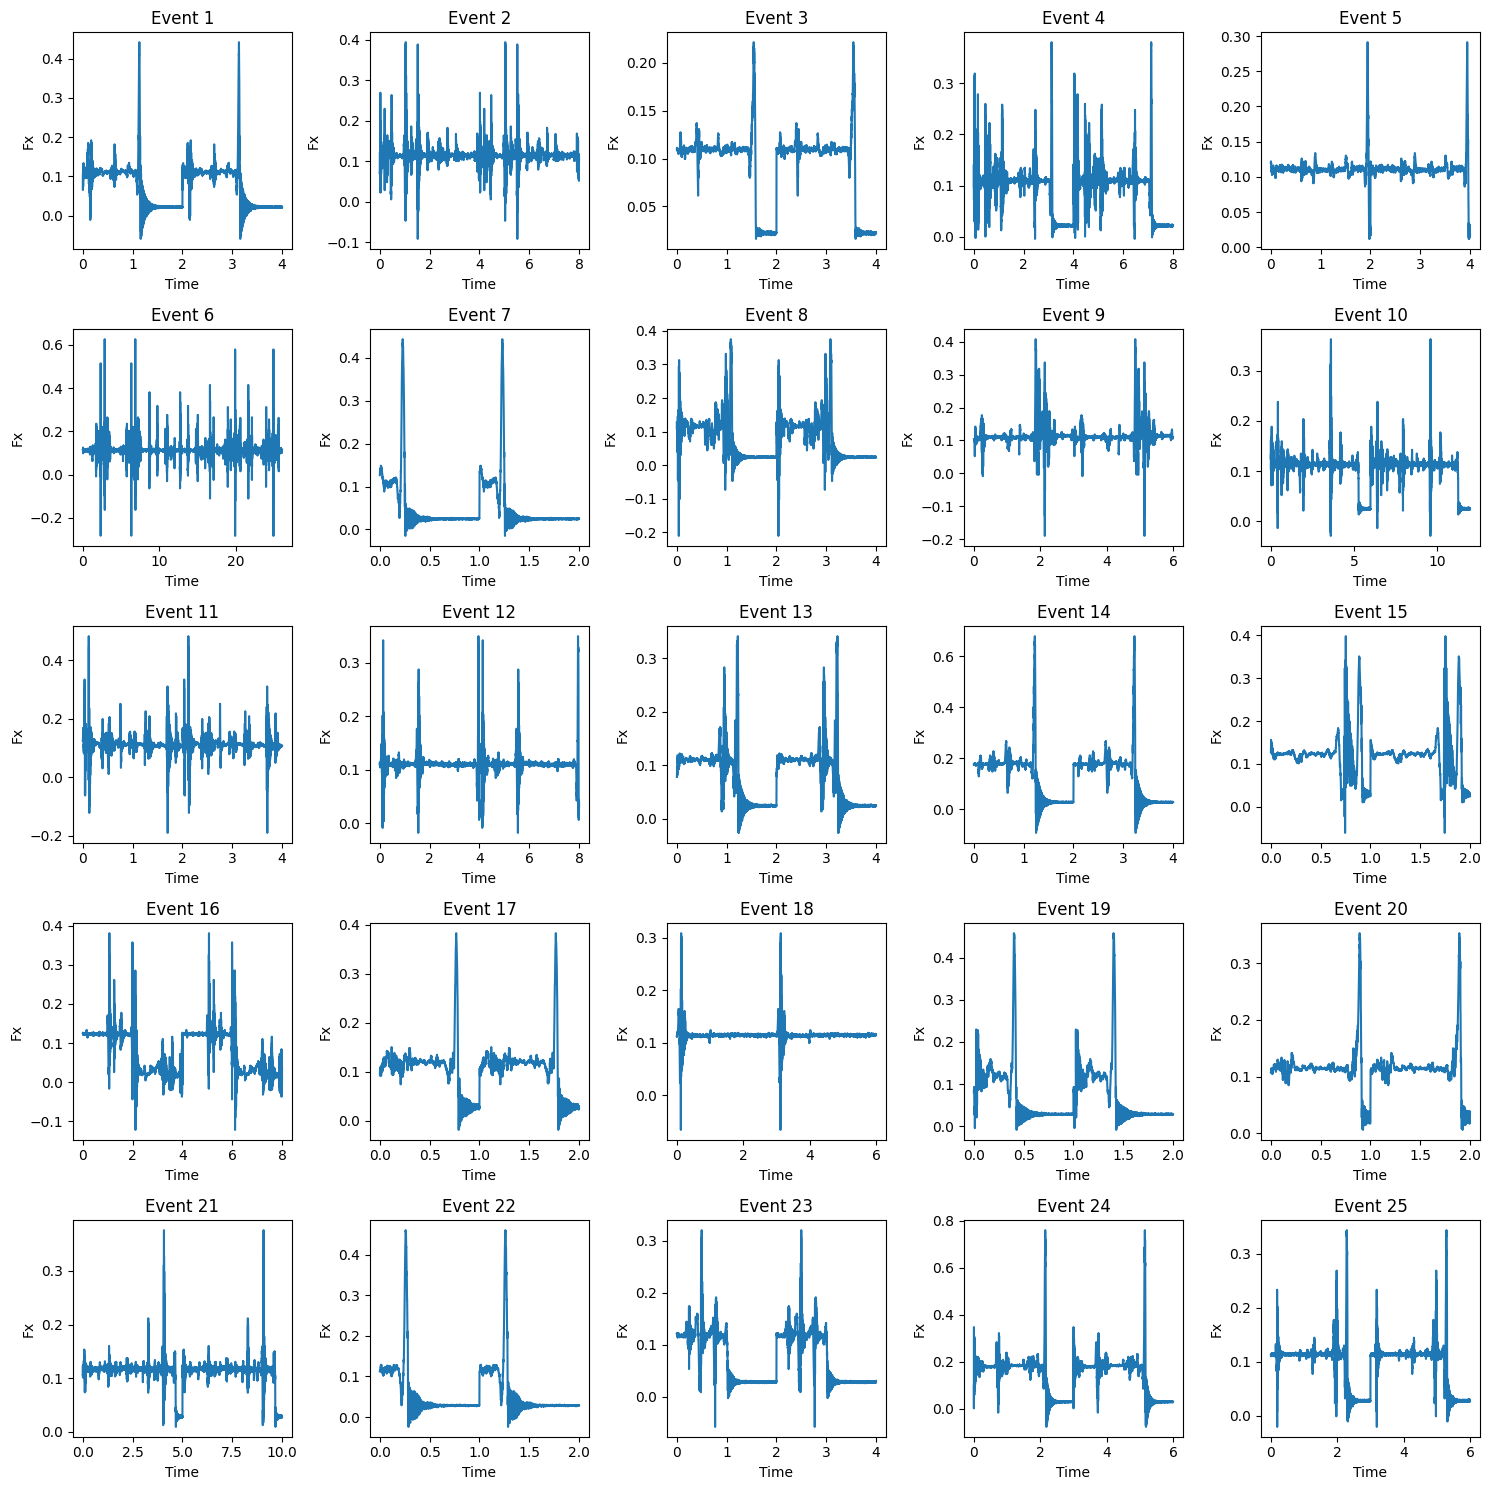

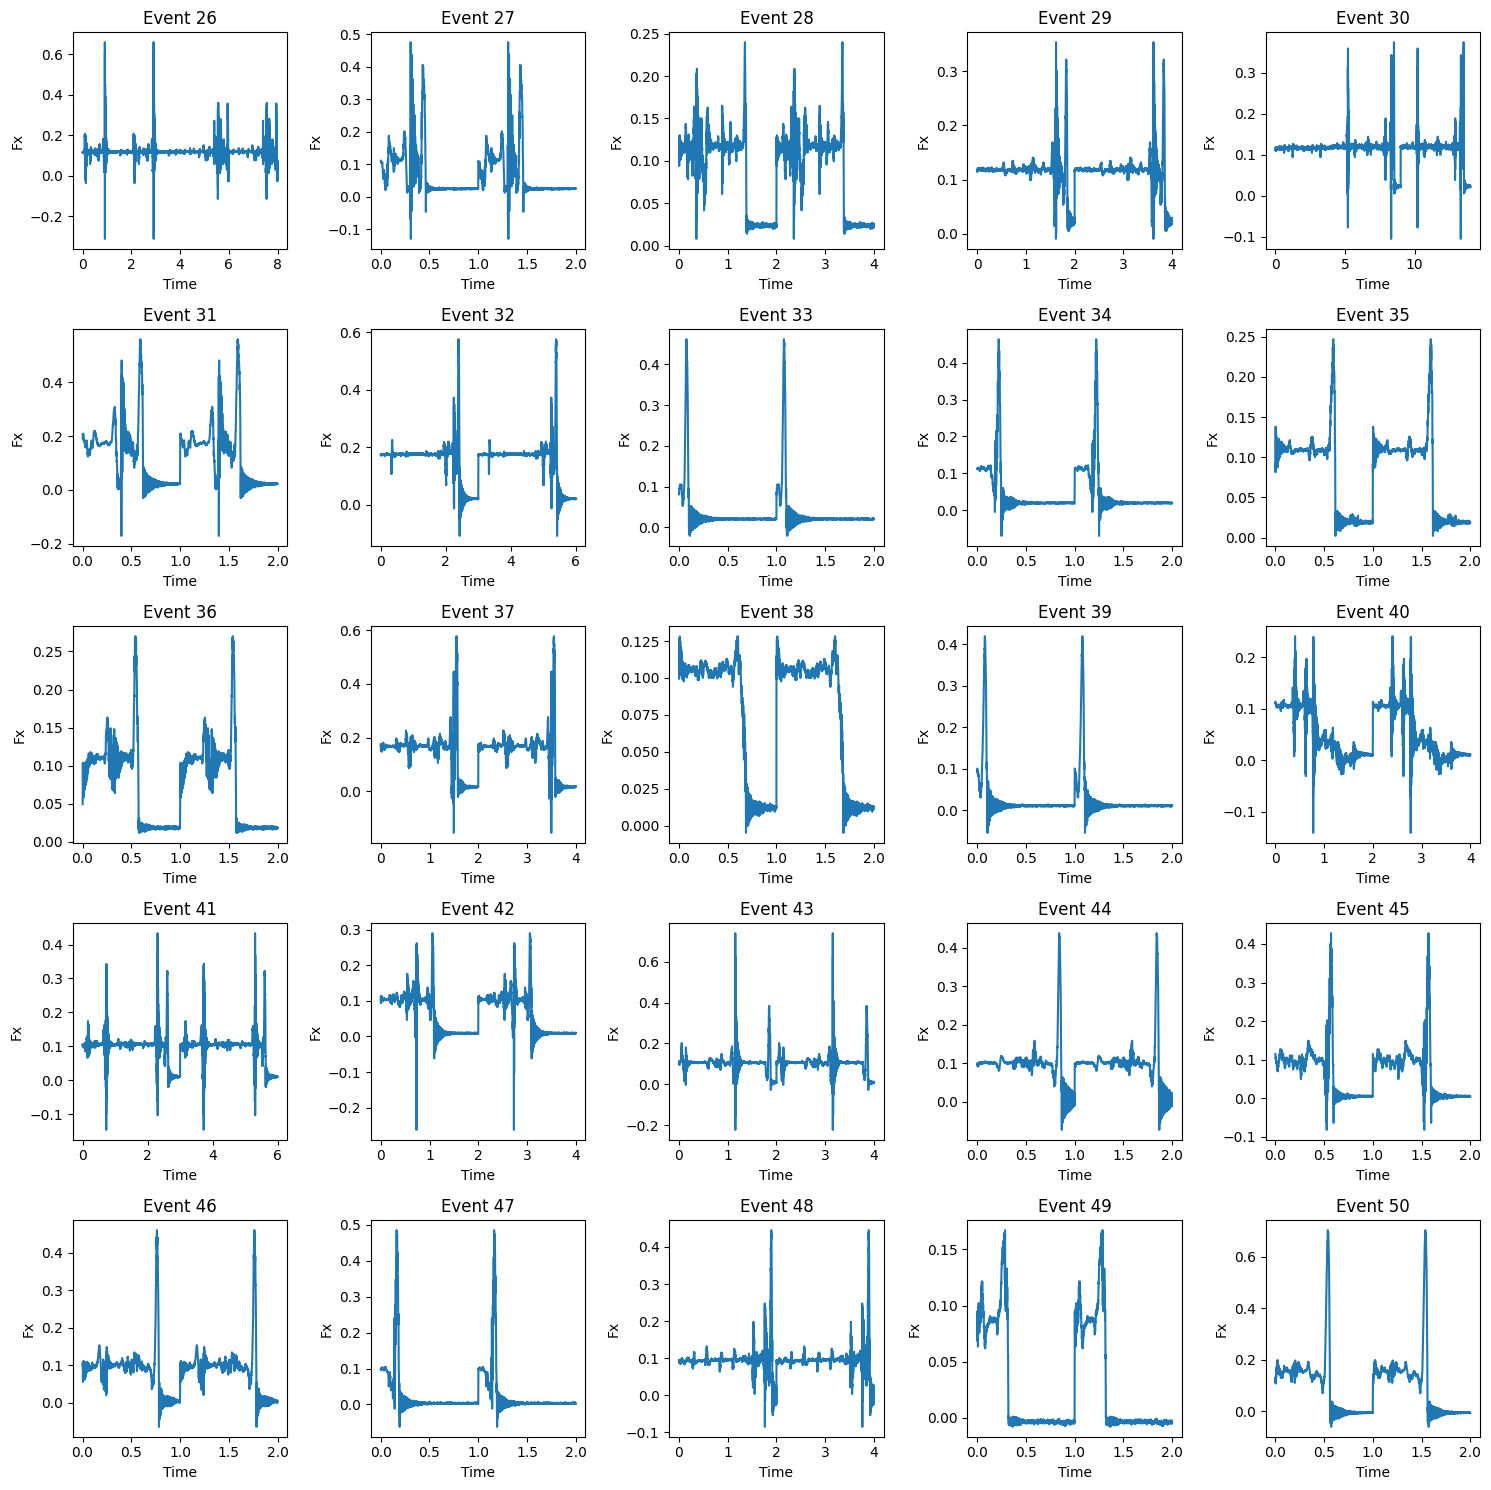

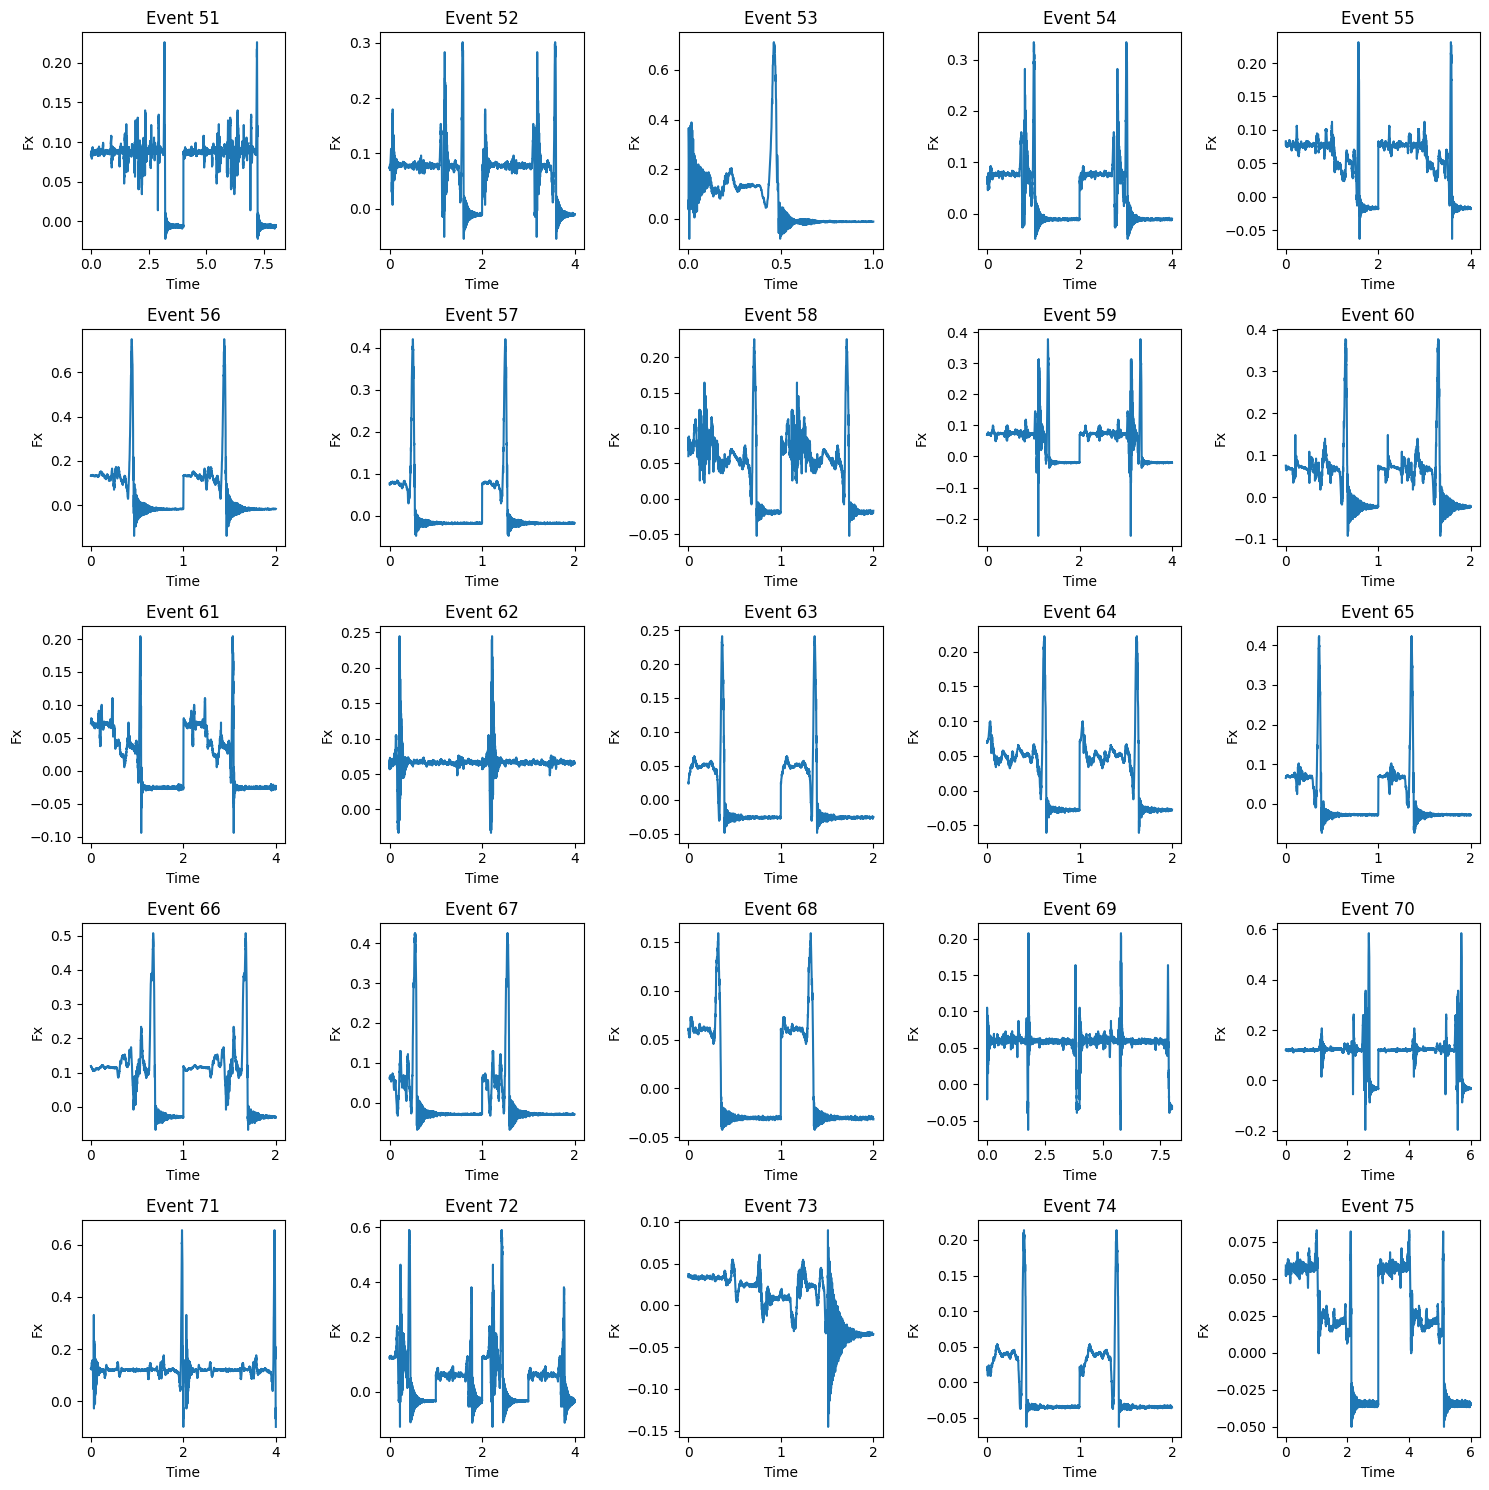

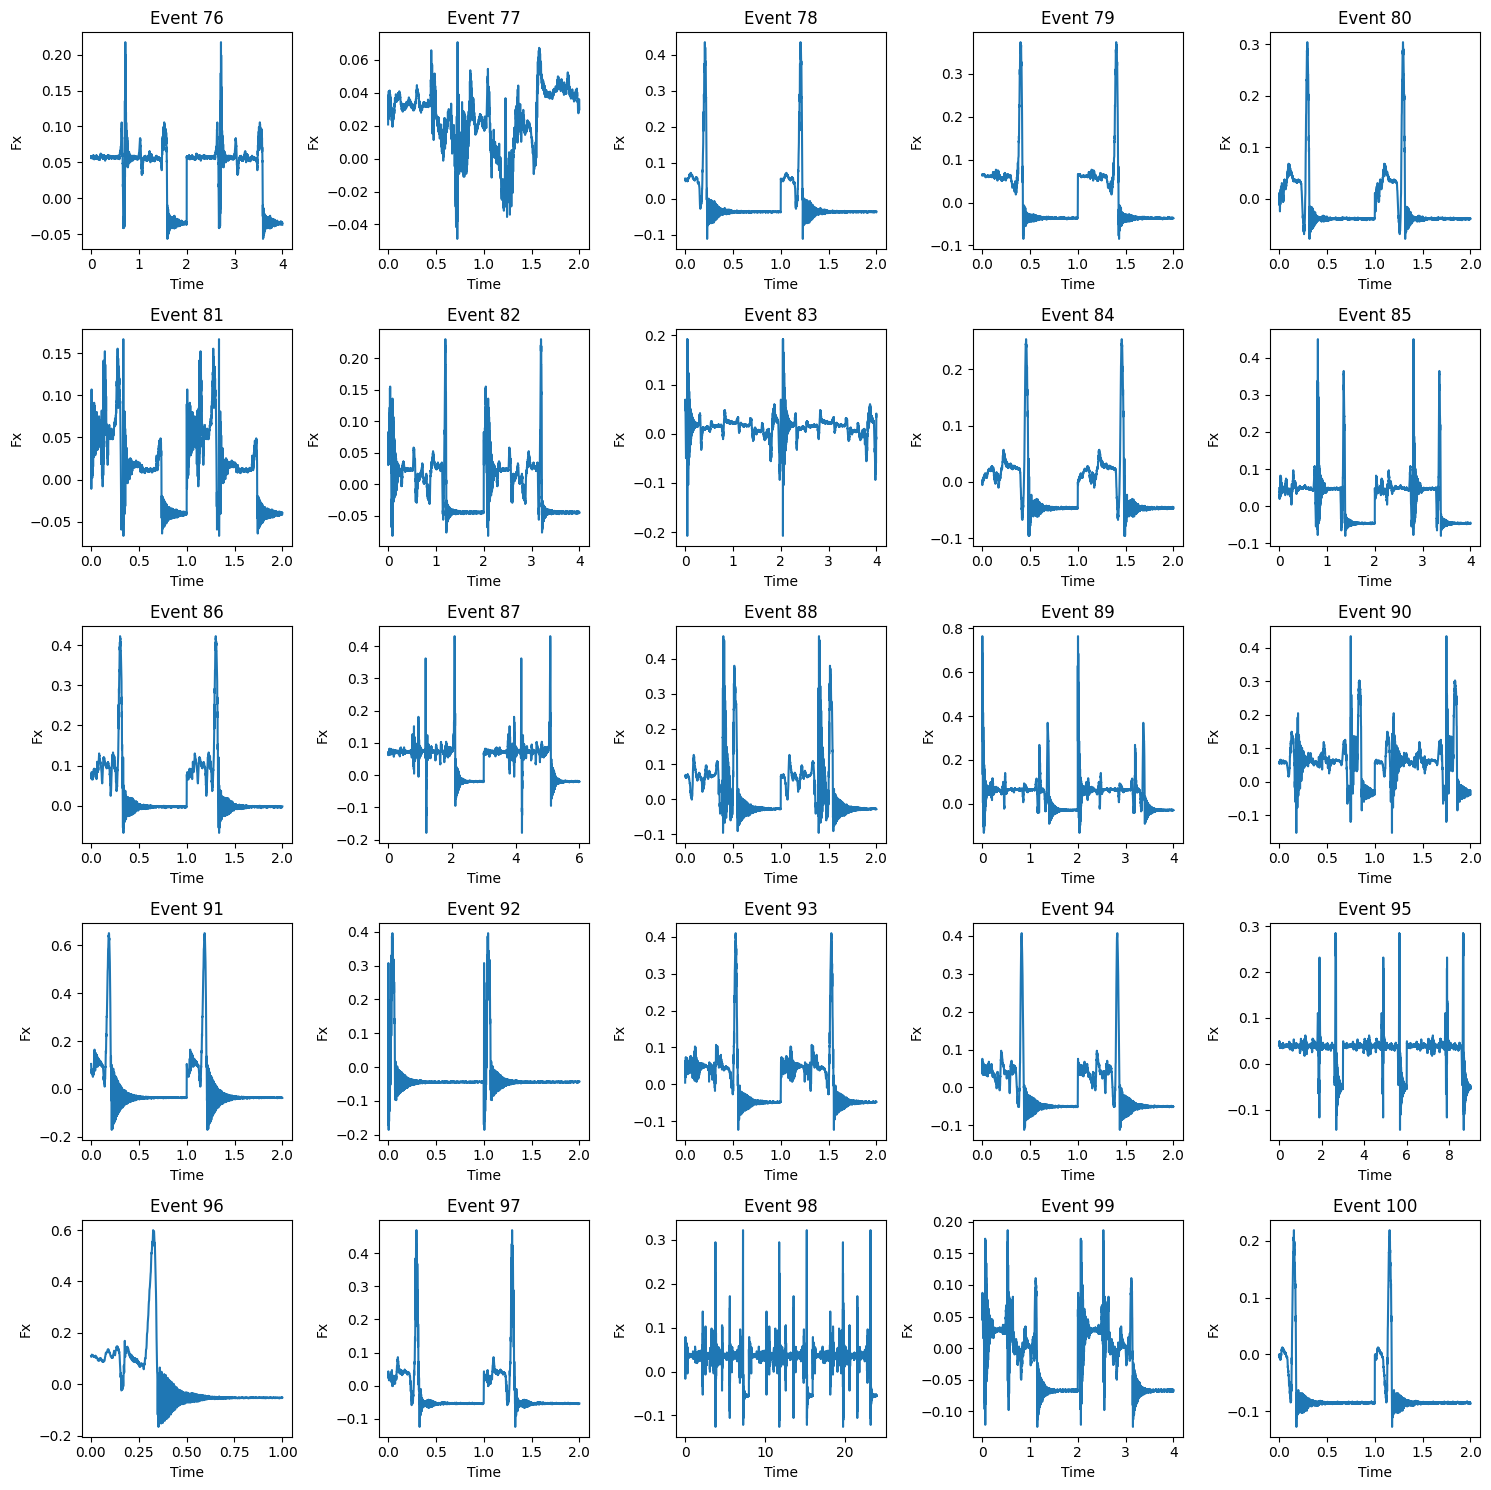

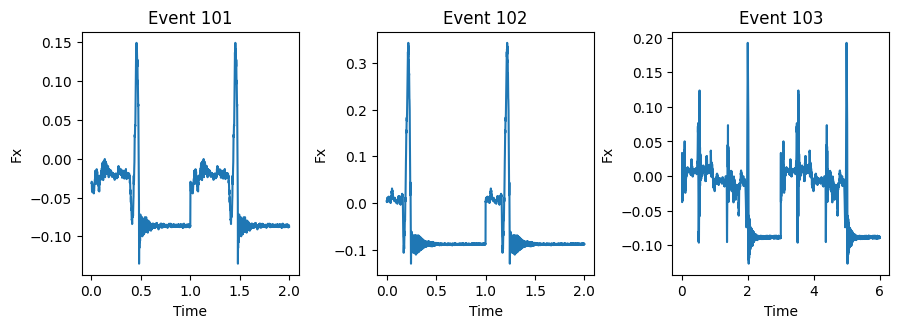

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

#see if the data is doubled as observed before

unique_events = F_all_day1_Feb13['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = F_all_day1_Feb13[F_all_day1_Feb13['event2'] == event]
            
            sns.lineplot(x='Time', y='Fx', data=event_data, ax=axes[i//cols, i%cols])
            axes[i//cols, i%cols].set_title(f'Event {event}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots

    plt.tight_layout()
    plt.show()

### 4.2.a Zero-centering

In [ ]:
import force_defs as force_defs
importlib.reload(force_defs)

<module 'notebooks.force_defs' from 'c:\\Users\\kmh\\Documents\\shed-tits\\notebooks\\..\\notebooks\\force_defs.py'>

In [29]:
dummy_F_zero_centered = force_defs.zero_centering(dummy_F, endframe = 50)

  0%|          | 0/60 [00:00<?, ?it/s]

In [2]:
#F_all_day0 = pd.read_csv(r'D:\FTdata\F_all_day0.csv', index_col = 0 )
F_all_dayminus1 = pd.read_csv(r'D:\FTdata\F_all_dayminus1.csv', index_col = 0)

In [10]:
F_all_day0.head(7)

,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime,RFID,event,day,event2,Frame,Time
0,0,-1.870222,-5.737000,1.386616,-0.040908,-0.028999,-0.000499,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,1,0.001
1,1,-1.874636,-5.735134,1.384855,-0.041137,-0.029422,-0.000478,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,2,0.002
2,2,-1.876605,-5.730647,1.383437,-0.041401,-0.029530,-0.000457,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,3,0.003
3,3,-1.870464,-5.731841,1.384551,-0.041374,-0.029185,-0.000485,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,4,0.004
4,4,-1.869198,-5.736343,1.382003,-0.041143,-0.028919,-0.000458,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,5,0.005
5,5,-1.872003,-5.738018,1.386780,-0.041107,-0.029171,-0.000479,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,6,0.006
6,6,-1.875444,-5.735685,1.385699,-0.041300,-0.029530,-0.000468,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,7,0.007


In [ ]:
day0_zero_centered = force_defs.zero_centering(F_all_day0, endframe = 50 ) #took 36 mins


  0%|          | 0/5189 [00:00<?, ?it/s]

In [ ]:
day1_zero_centered = force_defs.zero_centering(F_all_day1, endframe = 50 ) #took 27 mins 

  0%|          | 0/3637 [00:00<?, ?it/s]

In [ ]:
dayminus1_zero_centered = force_defs.zero_centering(F_all_dayminus1, endframe = 50 ) #took 45 mins 

  0%|          | 0/5556 [00:00<?, ?it/s]

### 4.2.b Halving

In [30]:
dummy_F_zeroed_halved = force_defs.halve_frame2(dummy_F_zero_centered)

In [ ]:
# Aim: per event, get the first half of the frames. 
day0_zeroed_halved = force_defs.halve_frame2(day0_zero_centered) #3m 45s

In [13]:
day0_zeroed_halved.to_csv(r'D:\FTdata\day0_zeroed_halved.csv')

In [ ]:
day1_zeroed_halved = force_defs.halve_frame2(day1_zero_centered) #8mins 2.1s

In [8]:
day1_zeroed_halved.to_csv(r'D:\FTdata\day1_zeroed_halved.csv')

In [ ]:
dayminus1_zeroed_halved = force_defs.halve_frame2(dayminus1_zero_centered) #8mins 2.1s

In [5]:
dayminus1_zeroed_halved.to_csv(r'D:\FTdata\dayminus1_zeroed_halved.csv')

### 4.2.c Butterworth filtering

In [36]:
butter_df_dummy = force_defs.apply_butterfilt(dummy_F_zeroed_halved, order=8, cutoff=45, calibration = False)
butter_df_dummy = force_defs.compute_Ftotal(butter_df_dummy)

  0%|          | 0/60 [00:00<?, ?it/s]

In [37]:
butter_df_dummy.head(3)

,Fx,Fy,Fz,Tx,Ty,Tz,t,day_since,scare_outcome,event,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
0,0.180996,0.090778,0.013989,-0.007965,0.012374,0.000680,3.832497e+09,-1,0,1,...,1,1,0.001,0.180928,0.090701,0.013979,-0.007964,0.012371,0.000681,0.202872
1,0.183110,0.090774,0.014791,-0.008001,0.012360,0.000680,3.832497e+09,-1,0,1,...,1,2,0.002,0.181523,0.091150,0.013833,-0.007997,0.012388,0.000680,0.203594
2,0.182378,0.091263,0.013213,-0.008031,0.012402,0.000672,3.832497e+09,-1,0,1,...,1,3,0.003,0.182110,0.091593,0.013689,-0.008029,0.012406,0.000680,0.204305


In [38]:
butter_df_dummy.to_csv('../data/butter_df_dummy.csv')

In [9]:
day0_zeroed_halved = pd.read_csv(r'D:\FTdata\day0_zeroed_halved.csv', index_col = 0)

In [ ]:
#run cell per once. 
butter_df_day0 = force_defs.apply_butterfilt(day0_zeroed_halved, order=8, cutoff=45, calibration=False)
butter_df_day0 = force_defs.compute_Ftotal(butter_df_day0)

  0%|          | 0/5201 [00:00<?, ?it/s]

In [11]:
butter_df_day0.to_csv(r'D:\FTdata\butter_df_day0.csv')

In [12]:
day1_zeroed_halved = pd.read_csv(r'D:\FTdata\day1_zeroed_halved.csv')

In [ ]:
butter_df_day1 = force_defs.apply_butterfilt(day1_zeroed_halved, order=8, cutoff=45, calibration=False)
butter_df_day1 = force_defs.compute_Ftotal(butter_df_day1)

  0%|          | 0/3651 [00:00<?, ?it/s]

In [14]:
butter_df_day1.to_csv(r'D:\FTdata\butter_df_day1.csv')

In [ ]:
butter_df_dayminus1 = force_defs.apply_butterfilt(dayminus1_zeroed_halved, order=8, cutoff=45, calibration = False)
butter_df_dayminus1 = force_defs.compute_Ftotal(butter_df_dayminus1)

  0%|          | 0/5573 [00:00<?, ?it/s]

In [7]:
butter_df_dayminus1.to_csv(r'D:\FTdata\butter_df_dayminus1.csv')

In [15]:
butter_df_day0['day'].unique()

array(['2024-12-23', '2025-01-30', '2025-01-24', '2025-02-06',
       '2025-02-12', '2025-02-19', '2025-02-16', '2025-01-21',
       '2025-01-03', '2024-12-12', '2024-12-15', '2024-12-31'],
      dtype=object)

In [17]:
butter_df_day1.head(3)


,Unnamed: 0.1,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
0,5382404,88000,0.096341,0.028341,-0.005045,-0.003014,0.010367,0.000546,3.821158e+09,2025-01-31 08:48:05.043,...,21,1,0.001,0.095789,0.027777,-0.004918,-0.002939,0.010316,0.000533,0.099856
1,5382405,88001,0.087686,0.023039,-0.006245,-0.003097,0.010010,0.000555,3.821158e+09,2025-01-31 08:48:05.043,...,21,2,0.002,0.093338,0.026699,-0.004764,-0.002914,0.010110,0.000531,0.097199
2,5382406,88002,0.088283,0.022248,-0.005892,-0.002937,0.009795,0.000525,3.821158e+09,2025-01-31 08:48:05.043,...,21,3,0.003,0.090973,0.025708,-0.004619,-0.002896,0.009911,0.000531,0.094649


### 4.3 filtered graph

In [7]:
butter_df_day1 = pd.read_csv('data/butter_df_day1.csv', index_col = 0)
butter_df_day1.head(5)

,Unnamed: 0.1,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
0,5382404,88000,0.096341,0.028341,-0.005045,-0.003014,0.010367,0.000546,3.821158e+09,2025-01-31 08:48:05.043,...,21,1,0.001,0.095789,0.027777,-0.004918,-0.002939,0.010316,0.000533,0.099856
1,5382405,88001,0.087686,0.023039,-0.006245,-0.003097,0.010010,0.000555,3.821158e+09,2025-01-31 08:48:05.043,...,21,2,0.002,0.093338,0.026699,-0.004764,-0.002914,0.010110,0.000531,0.097199
2,5382406,88002,0.088283,0.022248,-0.005892,-0.002937,0.009795,0.000525,3.821158e+09,2025-01-31 08:48:05.043,...,21,3,0.003,0.090973,0.025708,-0.004619,-0.002896,0.009911,0.000531,0.094649
3,5382407,88003,0.088953,0.022999,-0.006591,-0.002793,0.009811,0.000572,3.821158e+09,2025-01-31 08:48:05.043,...,21,4,0.004,0.088757,0.024845,-0.004479,-0.002889,0.009724,0.000531,0.092278
4,5382408,88004,0.089678,0.020832,-0.003680,-0.002824,0.009853,0.000543,3.821158e+09,2025-01-31 08:48:05.043,...,21,5,0.005,0.086750,0.024142,-0.004342,-0.002893,0.009556,0.000535,0.090152


In [5]:
# Filter rows by matching the 'day' column with the specific date
butter_df_Jan22_E1 = butter_df[butter_df['RFID'] == "011016B2E1"]

# Count the number of unique values in the 'event2' column
print(butter_df_Jan22_E1['event2'].nunique())

print(butter_df_Jan22_E1.head(5))

86
   Unnamed: 0        Fx        Fy        Fz        Tx        Ty        Tz  \
0       88000  0.096341  0.028341 -0.005045 -0.003014  0.010367  0.000546   
1       88001  0.087686  0.023039 -0.006245 -0.003097  0.010010  0.000555   
2       88002  0.088283  0.022248 -0.005892 -0.002937  0.009795  0.000525   
3       88003  0.088953  0.022999 -0.006591 -0.002793  0.009811  0.000572   
4       88004  0.089678  0.020832 -0.003680 -0.002824  0.009853  0.000543   

              t                 datetime        RFID  ...  event2 Frame  \
0  3.821158e+09  2025-01-31 08:48:05.043  011016B2E1  ...      21     1   
1  3.821158e+09  2025-01-31 08:48:05.043  011016B2E1  ...      21     2   
2  3.821158e+09  2025-01-31 08:48:05.043  011016B2E1  ...      21     3   
3  3.821158e+09  2025-01-31 08:48:05.043  011016B2E1  ...      21     4   
4  3.821158e+09  2025-01-31 08:48:05.043  011016B2E1  ...      21     5   

    Time   Fx_filt   Fy_filt   Fz_filt   Tx_filt   Ty_filt   Tz_filt  \
0  0.001  0

#### dummy - Ftot

In [41]:
butter_df_dummy

,Fx,Fy,Fz,Tx,Ty,Tz,t,day_since,scare_outcome,event,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
0,0.180996,0.090778,0.013989,-0.007965,0.012374,0.000680,3.832497e+09,-1,0,1,...,1,1,0.001,0.180928,0.090701,0.013979,-0.007964,0.012371,0.000681,0.202872
1,0.183110,0.090774,0.014791,-0.008001,0.012360,0.000680,3.832497e+09,-1,0,1,...,1,2,0.002,0.181523,0.091150,0.013833,-0.007997,0.012388,0.000680,0.203594
2,0.182378,0.091263,0.013213,-0.008031,0.012402,0.000672,3.832497e+09,-1,0,1,...,1,3,0.003,0.182110,0.091593,0.013689,-0.008029,0.012406,0.000680,0.204305
3,0.183590,0.094397,0.016219,-0.008071,0.012403,0.000652,3.832497e+09,-1,0,1,...,1,4,0.004,0.182676,0.092024,0.013544,-0.008060,0.012424,0.000680,0.204994
4,0.183563,0.091649,0.014663,-0.008112,0.012433,0.000662,3.832497e+09,-1,0,1,...,1,5,0.005,0.183209,0.092440,0.013398,-0.008090,0.012441,0.000679,0.205646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32495,0.521009,-0.394834,-0.009943,0.063142,0.061092,-0.000422,3.832500e+09,1,0,9,...,60,496,0.496,0.513317,-0.387181,-0.011106,0.061939,0.060192,-0.000370,0.643060
32496,0.503166,-0.379368,-0.013208,0.060439,0.059065,-0.000356,3.832500e+09,1,0,9,...,60,497,0.497,0.495249,-0.369087,-0.014220,0.059001,0.058028,-0.000344,0.617818
32497,0.485750,-0.362543,-0.017233,0.057711,0.057042,-0.000336,3.832500e+09,1,0,9,...,60,498,0.498,0.477281,-0.351162,-0.017268,0.056093,0.055874,-0.000317,0.592798
32498,0.468353,-0.344298,-0.017424,0.054898,0.054934,-0.000336,3.832500e+09,1,0,9,...,60,499,0.499,0.459711,-0.333676,-0.020209,0.053259,0.053766,-0.000291,0.568404


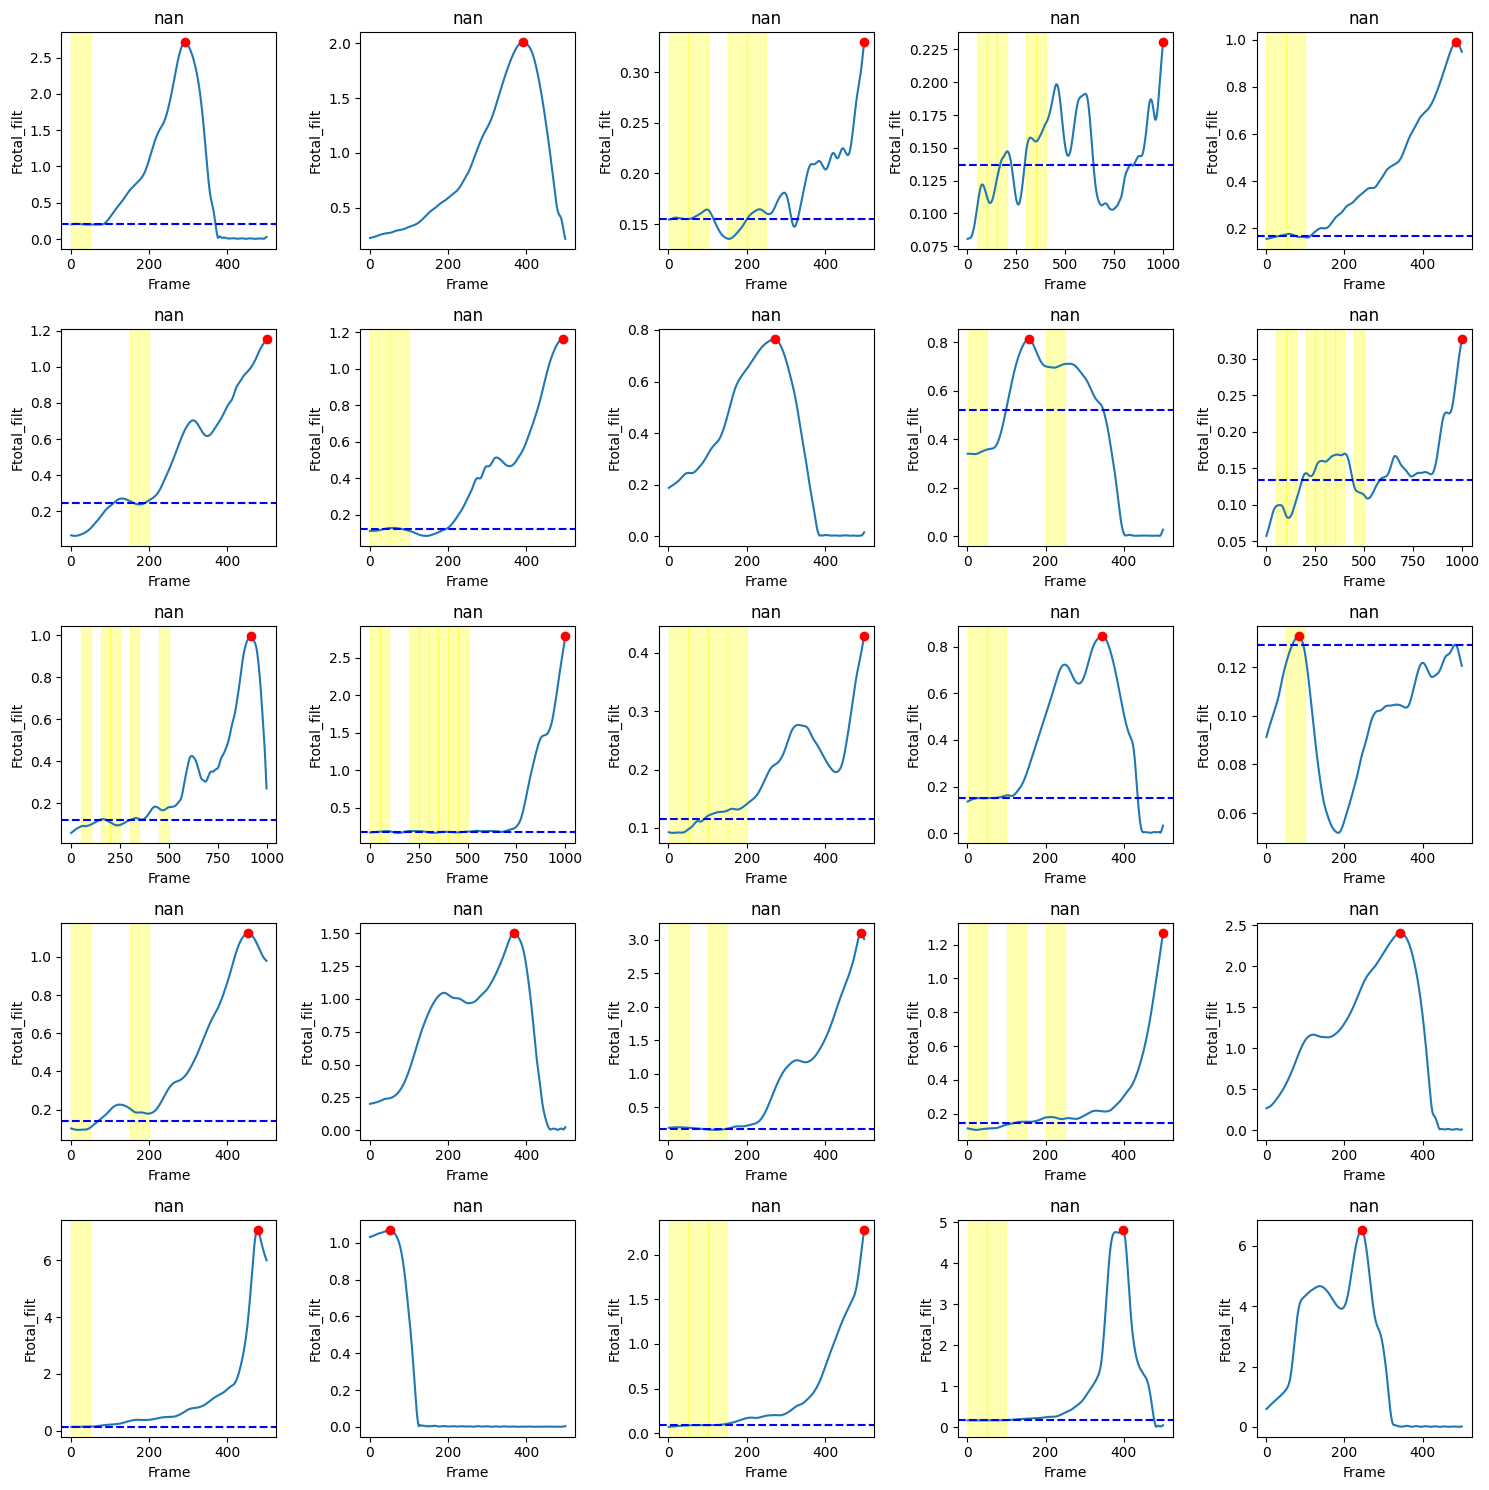

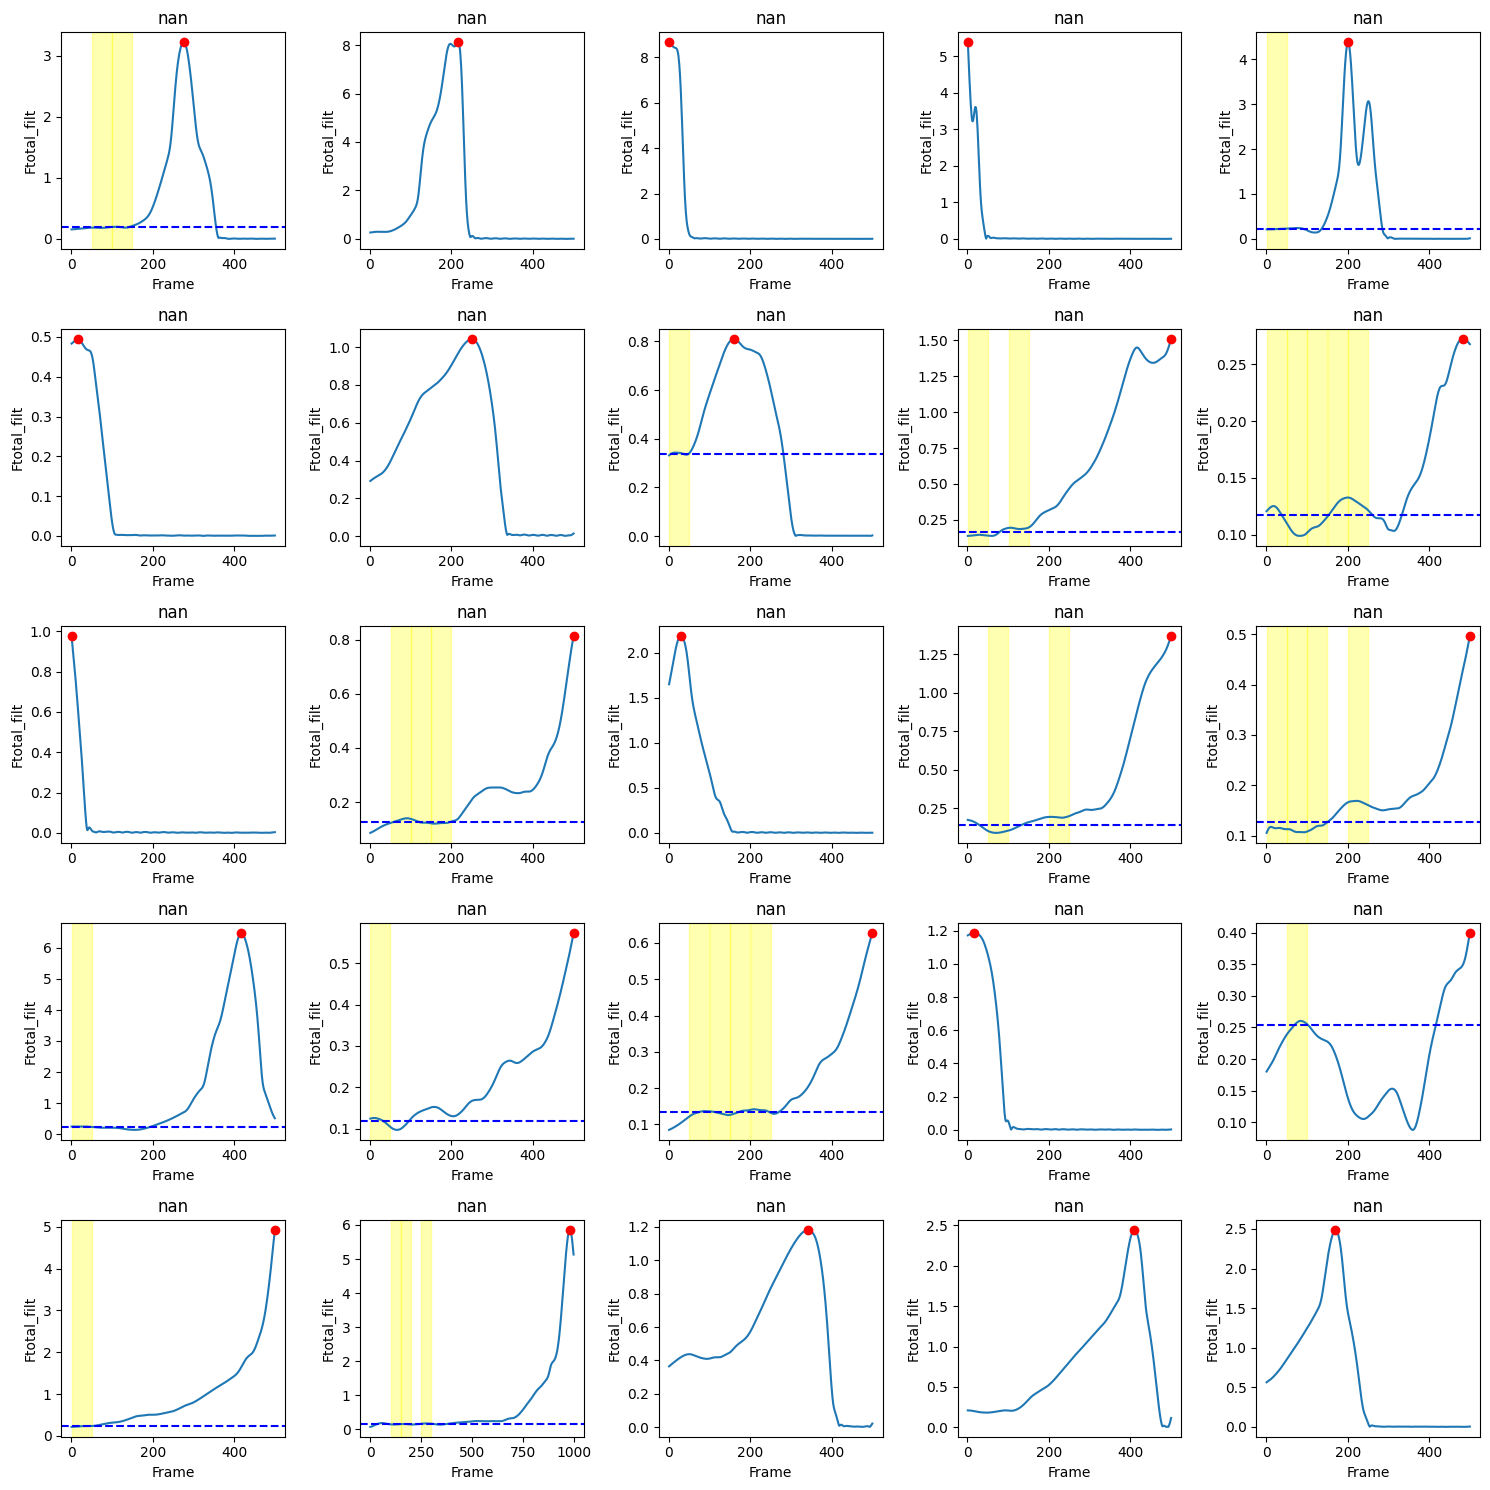

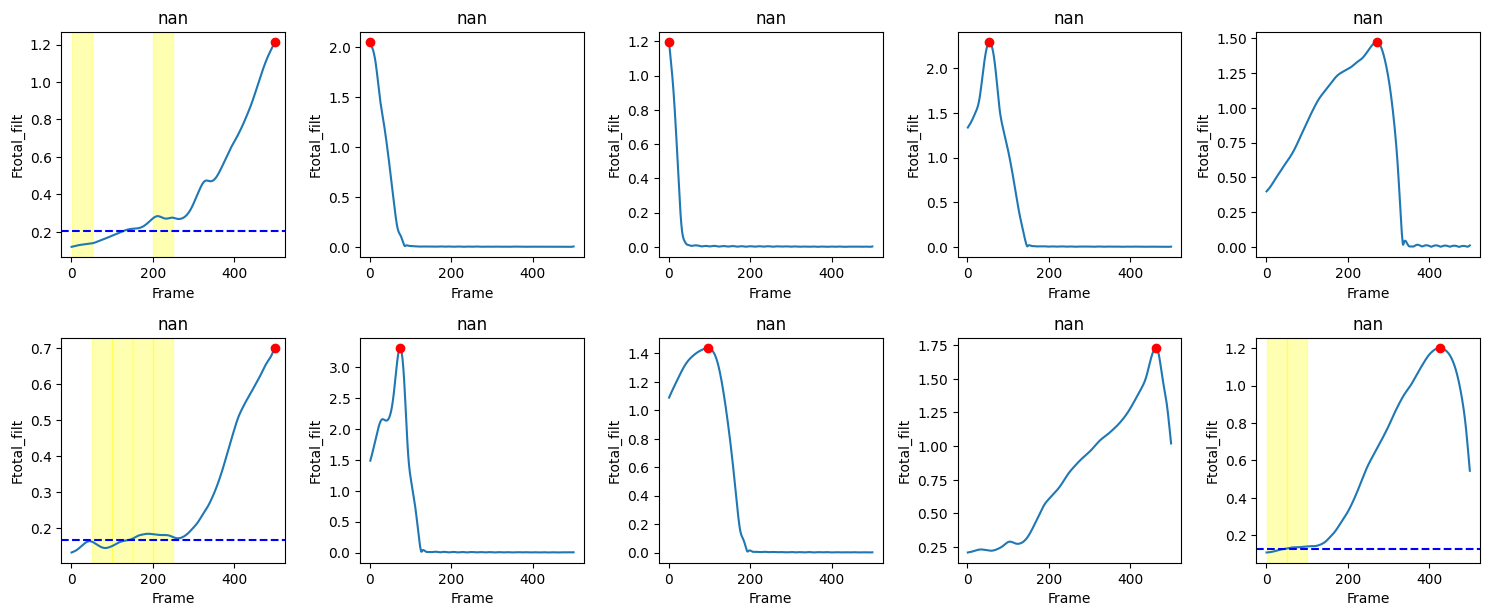

In [44]:
unique_events =butter_df_dummy['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_dummy[butter_df_dummy['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Frame', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Frame'].iloc[start], event_data['Frame'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Frame']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            rfid = event_data['RFID'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{rfid}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftotal', fontsize=20)

    plt.tight_layout()
    plt.show()

#### Fx

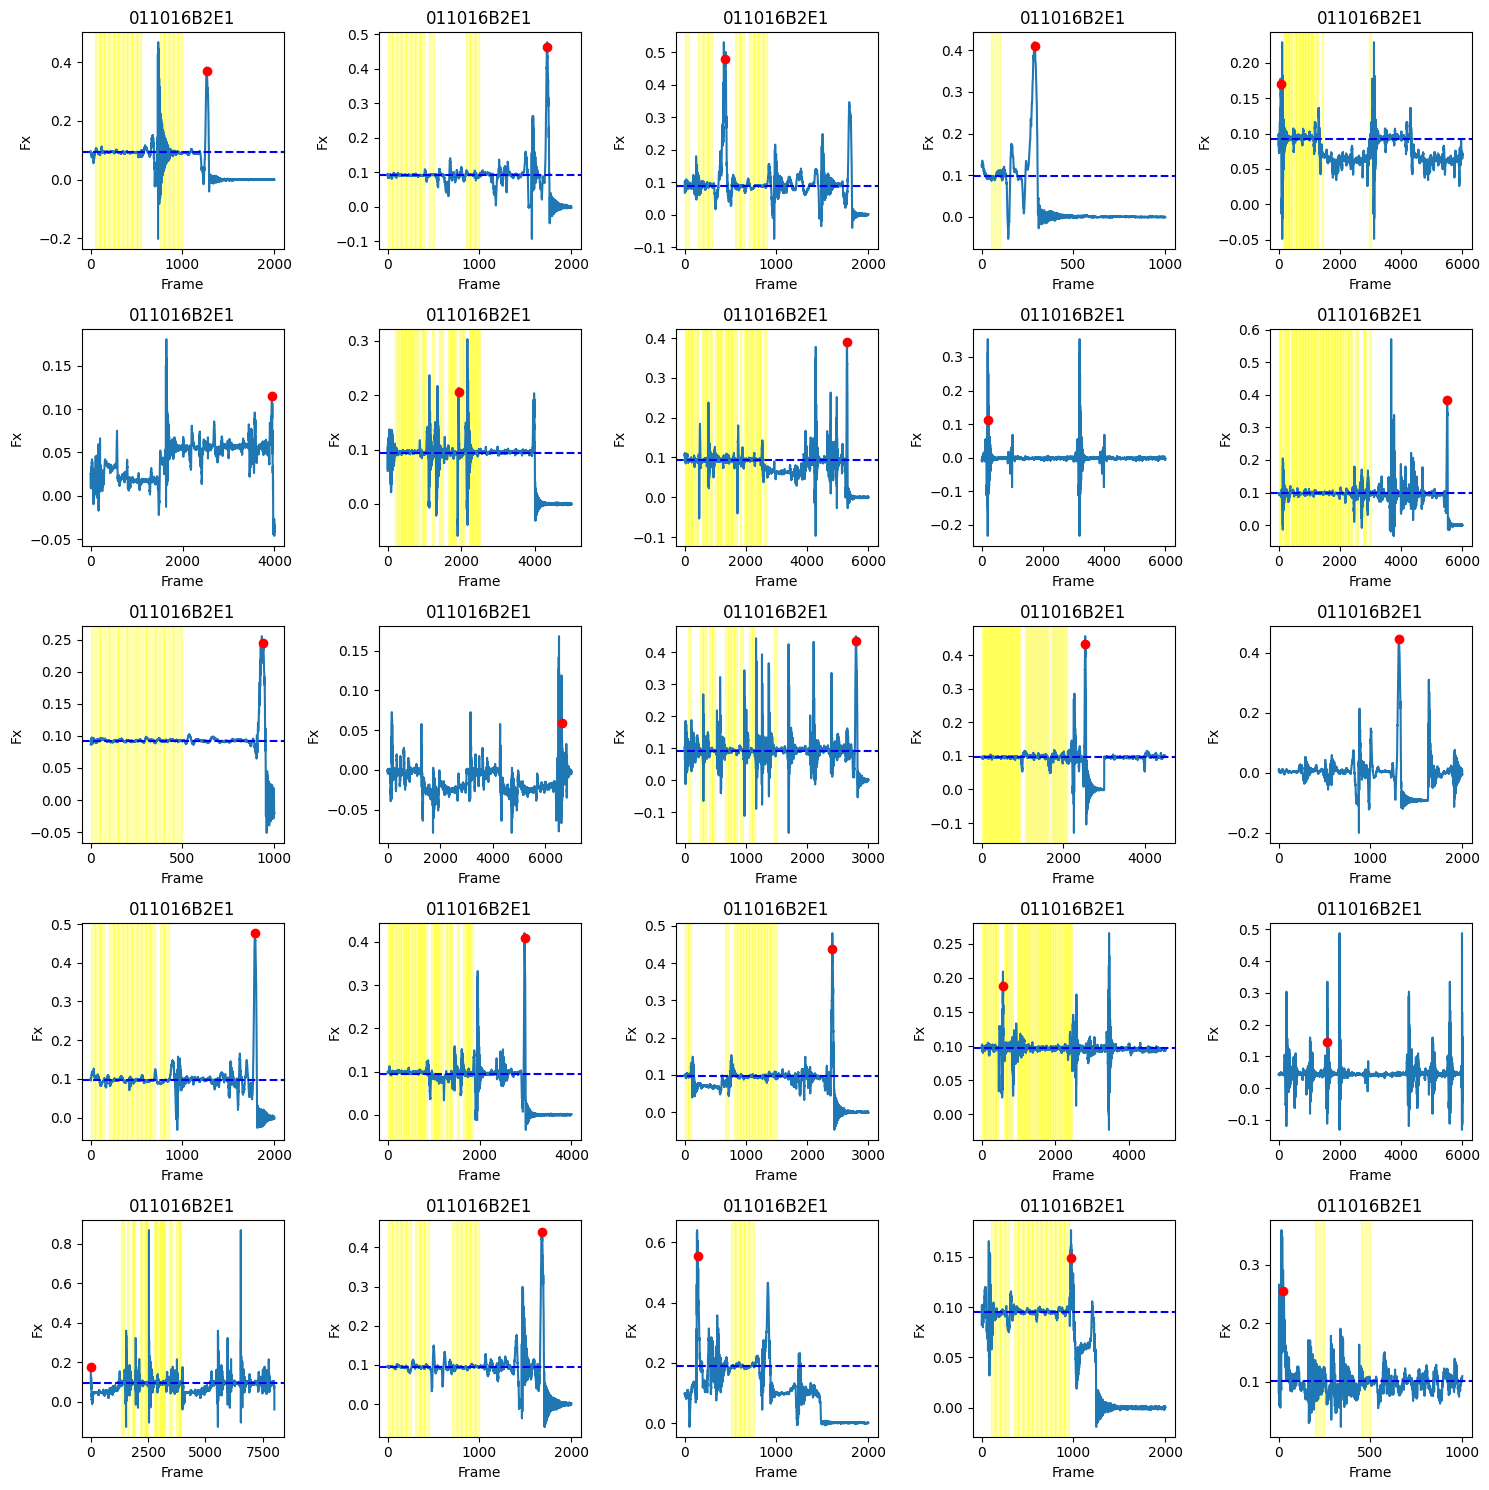

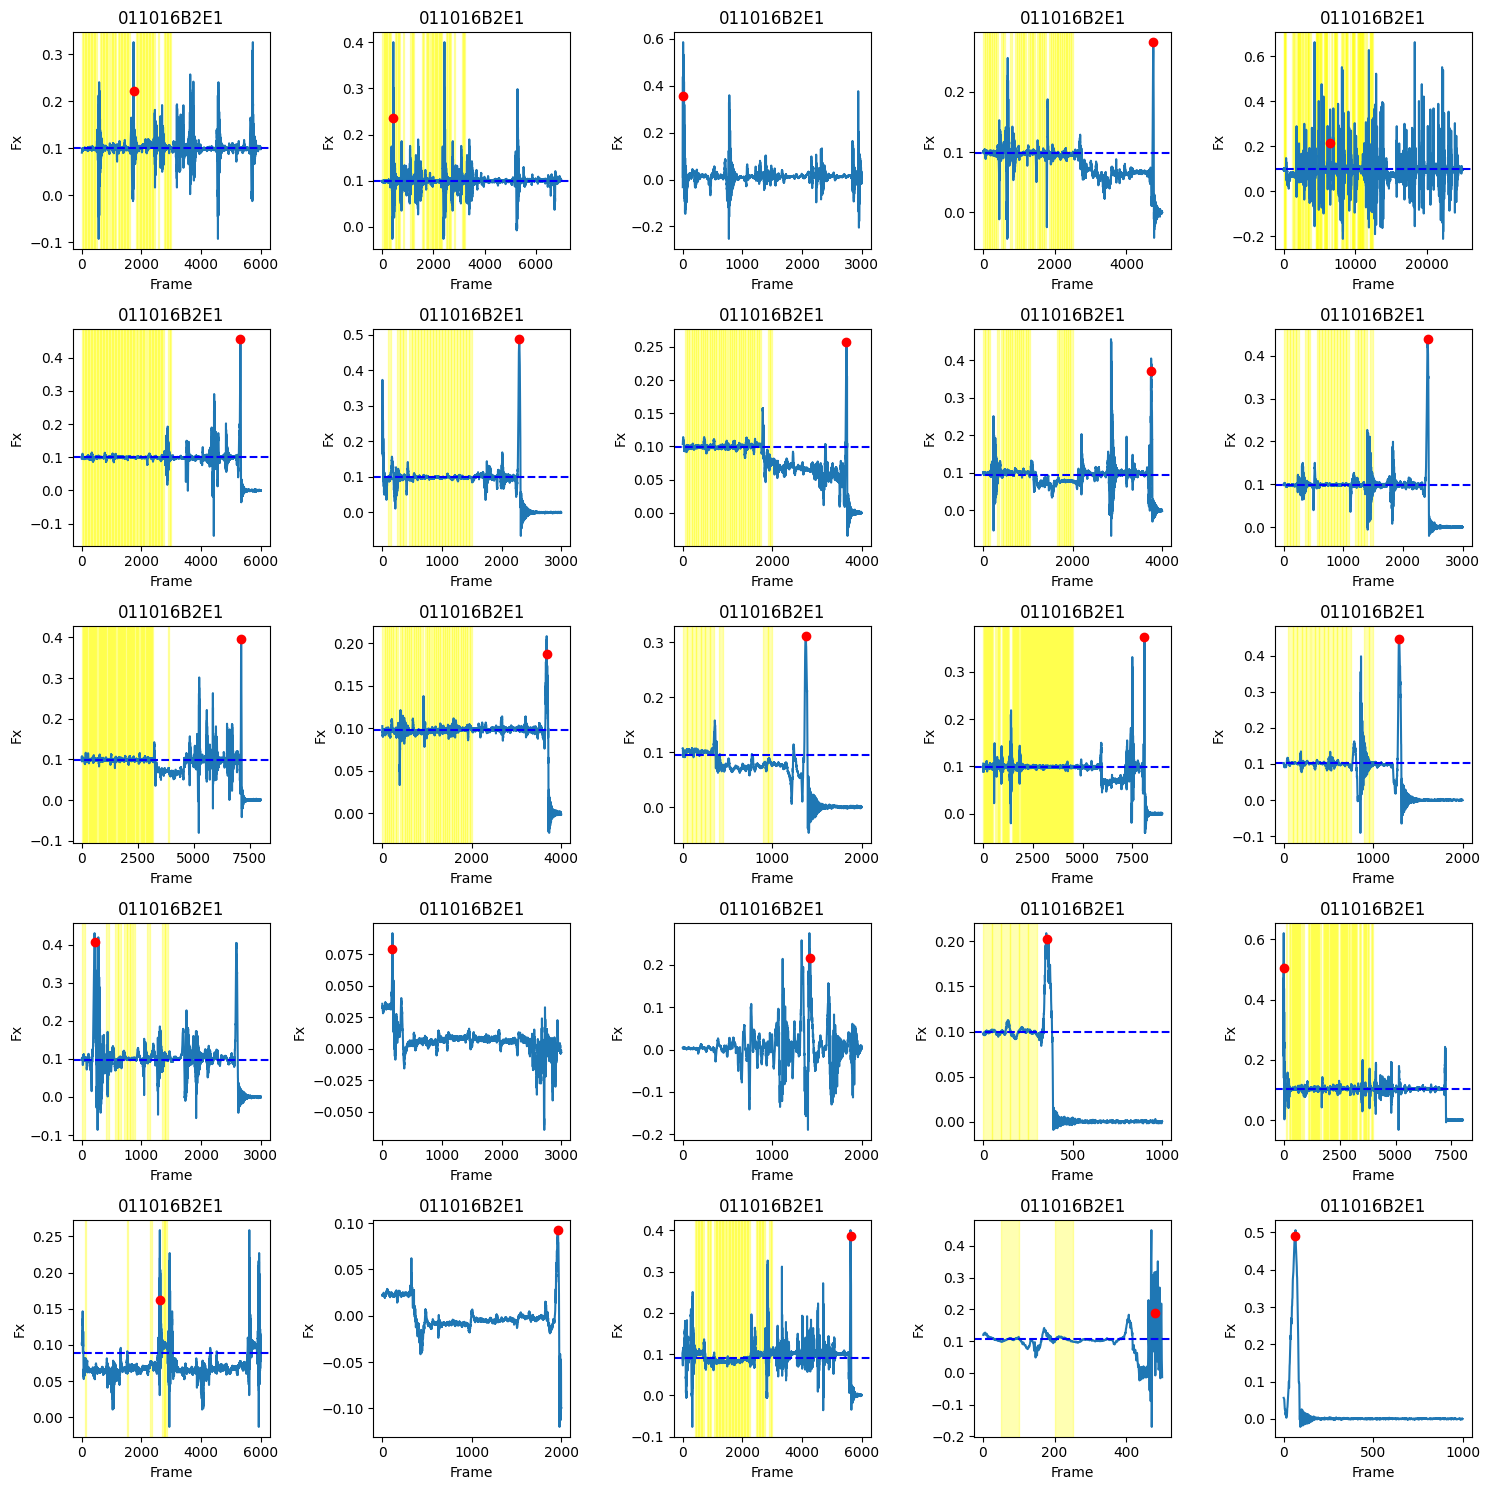

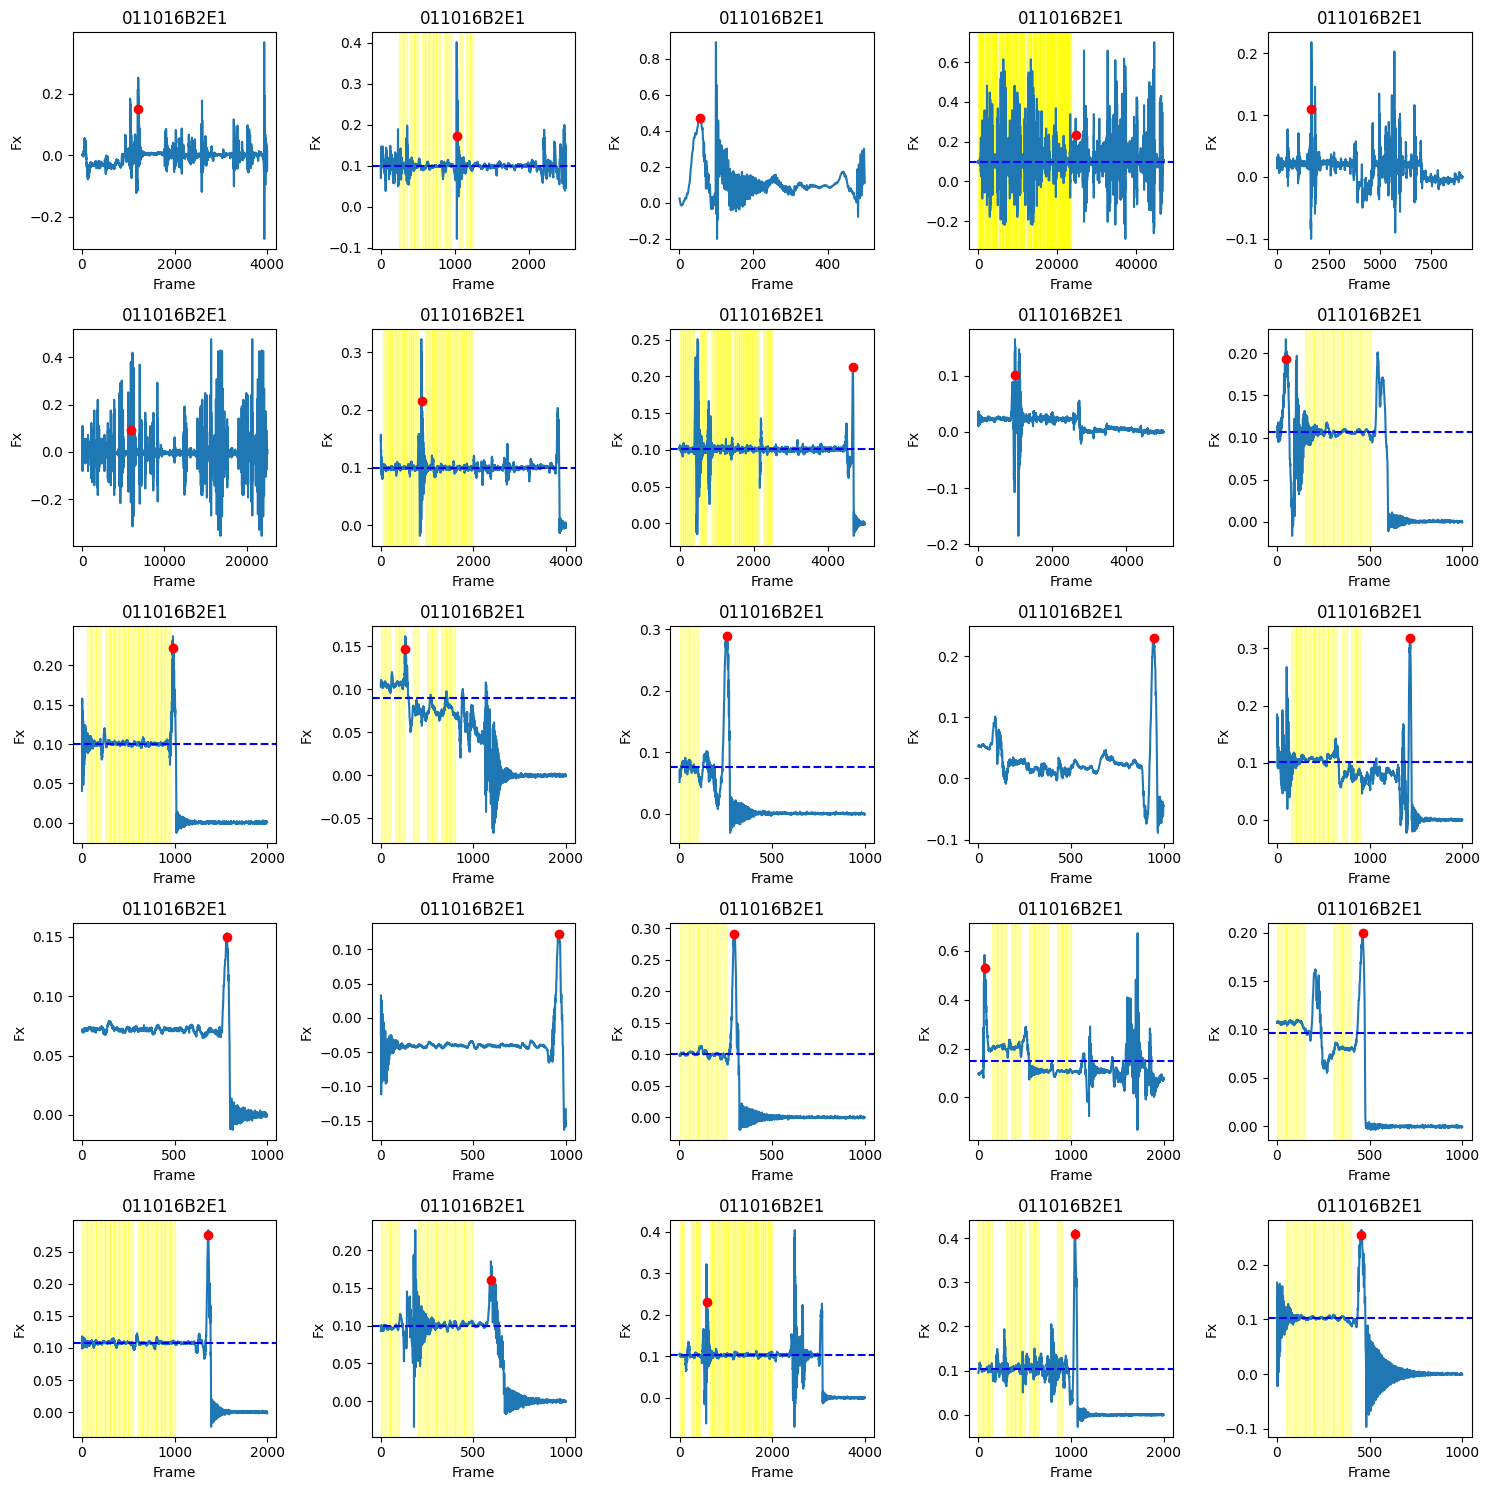

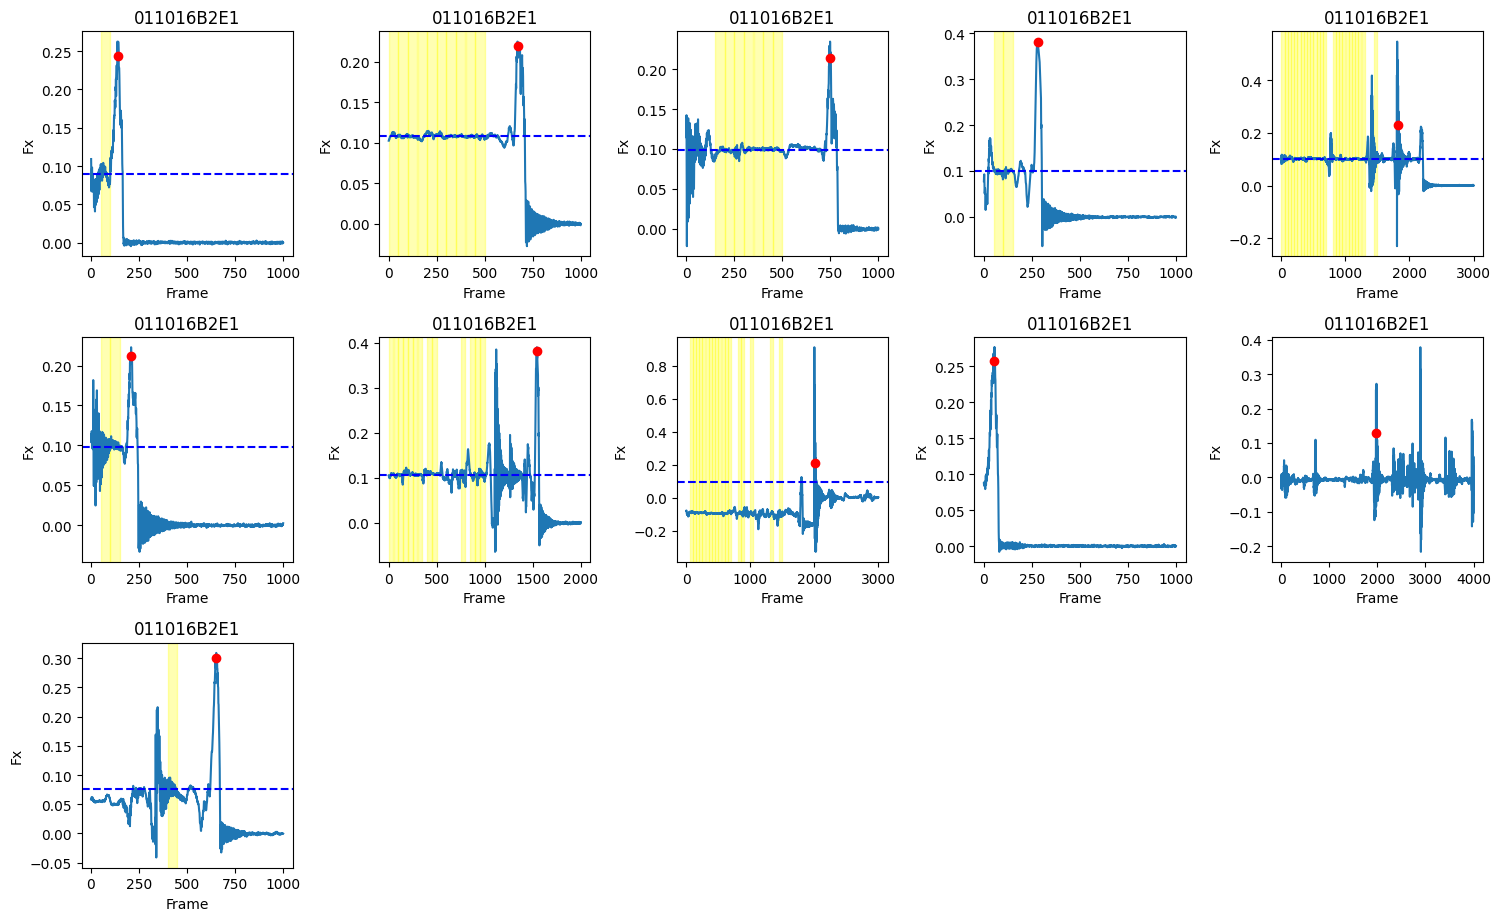

In [ ]:

unique_events = butter_df_Jan22_E1['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_Jan22_E1[butter_df_Jan22_E1['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Frame', y='Fx', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Frame'].iloc[start], event_data['Frame'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Fx_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Frame']
            maxforce_value = event_data.loc[maxforce_index, 'Fx_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            rfid = event_data['RFID'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{rfid}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



#### Fy

#### Ftot 

In [5]:
#reading the dataset that contains bodyweight
F_control_full = pd.read_csv('data/F_control_full.csv', index_col = 0)
F_treats_full = pd.read_csv('data/F_treats_full.csv', index_col = 0 )
F_day0_combined = pd.concat([F_control_full, F_treats_full], ignore_index=True).sort_values(by = 'day') #ok so actually had to sort by day. maybe datetime is not datetime formatted

# filter only the columns 'id', 'datetime', 'day', and 'bodyweight'
F_day0_combined = F_day0_combined[['id', 'datetime','day','event_no', 'bodyweight']]
pd.options.display.max_rows = 999  # Set as needed
display(F_day0_combined)

,id,datetime,day,event_no,bodyweight
0,3B00185CB8,2024-12-12 08:09:30.195,2024-12-12,1-2024-12-12,0.098546
2682,3B0019B8CC,2024-12-12 12:00:45.905,2024-12-12,148-2024-12-12,0.157227
2681,3B001874E8,2024-12-12 12:00:04.905,2024-12-12,147-2024-12-12,0.101811
2680,01103FA4B2,2024-12-12 11:59:59.906,2024-12-12,146-2024-12-12,0.102878
2679,01103FD2E8,2024-12-12 11:59:12.905,2024-12-12,145-2024-12-12,0.137063
...,...,...,...,...,...
2517,3B00191394,2025-02-19 14:46:54.538,2025-02-19,382-2025-02-19,0.097965
2518,3B00191394,2025-02-19 14:48:48.537,2025-02-19,384-2025-02-19,0.097965
2519,3B004CEFFE,2025-02-19 14:48:51.538,2025-02-19,385-2025-02-19,0.102054
2513,3B00192E1E,2025-02-19 14:39:43.537,2025-02-19,377-2025-02-19,0.100753


In [6]:
F_day0_combined.head(10)

,id,datetime,day,event_no,bodyweight
0,3B00185CB8,2024-12-12 08:09:30.195,2024-12-12,1-2024-12-12,0.098546
2682,3B0019B8CC,2024-12-12 12:00:45.905,2024-12-12,148-2024-12-12,0.157227
2681,3B001874E8,2024-12-12 12:00:04.905,2024-12-12,147-2024-12-12,0.101811
2680,01103FA4B2,2024-12-12 11:59:59.906,2024-12-12,146-2024-12-12,0.102878
2679,01103FD2E8,2024-12-12 11:59:12.905,2024-12-12,145-2024-12-12,0.137063
2678,3B00190DF0,2024-12-12 11:56:07.903,2024-12-12,141-2024-12-12,0.190675
2677,01103FD2E8,2024-12-12 11:55:46.904,2024-12-12,140-2024-12-12,0.137063
2676,3B001874E8,2024-12-12 11:55:14.903,2024-12-12,138-2024-12-12,0.102152
2675,3B001874E8,2024-12-12 11:55:14.903,2024-12-12,138-2024-12-12,0.102152
2674,01103FD2E8,2024-12-12 11:54:48.903,2024-12-12,136-2024-12-12,0.137063


In [7]:
butter_df_day0 = pd.read_csv('D:\\Kyu Min\\DATA\\butter_df_day0.csv', index_col = 0)

In [8]:
pd.options.display.max_rows = 50  # Set as needed
display(butter_df_day0.sort_values(by = 'day'))

,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime,RFID,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
2010999,1363499,-0.001010,-0.003721,-0.003280,0.000214,-0.000079,-0.000003,3.816857e+09,2024-12-12 13:57:47.012,01103FA4B2,...,308,4500,4.500,-0.000146,-0.002894,-0.001444,0.000211,-0.000028,-0.000004,0.003238
5879826,1146826,-0.268197,0.366687,0.061537,-0.052906,-0.032874,-0.000571,3.816855e+09,2024-12-12 13:27:26.030,3B00190DF0,...,269,827,0.827,-0.270667,0.358689,0.059868,-0.051747,-0.033148,-0.000640,0.453323
5879827,1146827,-0.273162,0.364073,0.059489,-0.052319,-0.033483,-0.000519,3.816855e+09,2024-12-12 13:27:26.030,3B00190DF0,...,269,828,0.828,-0.270459,0.360474,0.059559,-0.052033,-0.033126,-0.000525,0.454573
5879828,1146828,-0.277054,0.356587,0.059311,-0.051612,-0.033810,-0.000441,3.816855e+09,2024-12-12 13:27:26.030,3B00190DF0,...,269,829,0.829,-0.270448,0.362279,0.059019,-0.052315,-0.033132,-0.000400,0.455929
5879829,1146829,-0.274235,0.355909,0.061267,-0.051704,-0.033570,-0.000338,3.816855e+09,2024-12-12 13:27:26.030,3B00190DF0,...,269,830,0.830,-0.270607,0.364115,0.058251,-0.052595,-0.033164,-0.000263,0.457385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7530169,130169,0.062295,-0.000717,-0.010108,0.000296,0.007283,0.000230,3.822797e+09,2025-02-19 08:03:40.582,3B0019F652,...,21,1170,1.170,0.062686,0.000985,-0.010516,0.000256,0.007240,0.000267,0.063569
7530170,130170,0.063974,-0.002454,-0.010430,0.000783,0.007101,0.000245,3.822797e+09,2025-02-19 08:03:40.582,3B0019F652,...,21,1171,1.171,0.061263,-0.000511,-0.010571,0.000429,0.007060,0.000245,0.062170
7530171,130171,0.059167,-0.005229,-0.008709,0.000906,0.006873,0.000187,3.822797e+09,2025-02-19 08:03:40.582,3B0019F652,...,21,1172,1.172,0.059818,-0.002145,-0.010568,0.000621,0.006878,0.000221,0.060782
7530164,130164,0.068586,0.005907,-0.008739,-0.000423,0.007891,0.000338,3.822797e+09,2025-02-19 08:03:40.582,3B0019F652,...,21,1165,1.165,0.067397,0.005427,-0.009731,-0.000220,0.007874,0.000337,0.068312


In [9]:
print(butter_df_day0.head(10))
print(butter_df_day0.columns)

   Unnamed: 0        Fx        Fy        Fz        Tx        Ty        Tz  \
0       63000  0.134864  0.012839 -0.047120 -0.000252  0.010219  0.000218   
1       63001  0.124574  0.009396 -0.047039 -0.000557  0.008928  0.000247   
2       63002  0.112243  0.002192 -0.050318 -0.000460  0.008955  0.000293   
3       63003  0.125131  0.001363 -0.050443  0.000283  0.009869  0.000270   
4       63004  0.128227 -0.016498 -0.049537  0.001250  0.009398  0.000234   
5       63005  0.101417 -0.010970 -0.042457  0.001372  0.007753  0.000181   
6       63006  0.089513 -0.014390 -0.047259  0.000858  0.006647  0.000063   
7       63007  0.090729 -0.012982 -0.055197  0.000776  0.006982  0.000058   
8       63008  0.090301 -0.023595 -0.048565  0.001490  0.007129  0.000068   
9       63009  0.074539 -0.026710 -0.036664  0.002006  0.005987  0.000114   

              t                 datetime        RFID  ...  event2 Frame  \
0  3.817788e+09  2024-12-23 08:37:21.176  011016B2E1  ...      22     1   
1 

In [10]:
#
butter_df_day0['event_no'] = butter_df_day0.apply(lambda row: f"{row['event2']}-{row['day']}", axis=1)

# bodyweight filling on butter_df_day0
#rename 'id' in F_day0_combined to 'RFID'
F_day0_combined = F_day0_combined.rename(columns={'id': 'RFID'})

# left join match butter_df_day0 with F_day0_combined by 'day', 'RFID', and 'event2'
butter_df_day0_bw = pd.merge(butter_df_day0, F_day0_combined, on=['day', 'RFID', 'event_no'], how='left')
display(butter_df_day0_bw)

,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime_x,RFID,...,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt,event_no,datetime_y,bodyweight
0,63000,0.134864,0.012839,-0.047120,-0.000252,0.010219,0.000218,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,0.135282,0.012455,-0.047143,-0.000242,0.010261,0.000218,0.143801,22-2024-12-23,2024-12-23 08:37:21.176,0.09374
1,63001,0.124574,0.009396,-0.047039,-0.000557,0.008928,0.000247,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,0.129145,0.007576,-0.047426,0.000001,0.009806,0.000202,0.137787,22-2024-12-23,2024-12-23 08:37:21.176,0.09374
2,63002,0.112243,0.002192,-0.050318,-0.000460,0.008955,0.000293,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,0.122911,0.002896,-0.047574,0.000233,0.009344,0.000187,0.131829,22-2024-12-23,2024-12-23 08:37:21.176,0.09374
3,63003,0.125131,0.001363,-0.050443,0.000283,0.009869,0.000270,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,0.116488,-0.001423,-0.047457,0.000443,0.008867,0.000171,0.125792,22-2024-12-23,2024-12-23 08:37:21.176,0.09374
4,63004,0.128227,-0.016498,-0.049537,0.001250,0.009398,0.000234,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,0.109798,-0.005236,-0.046963,0.000625,0.008368,0.000155,0.119534,22-2024-12-23,2024-12-23 08:37:21.176,0.09374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10988494,601995,-0.000060,-0.000524,0.000984,-0.000009,-0.000055,-0.000010,3.822200e+09,2025-02-12 10:15:55.488,3B004DB16E,...,-0.000840,-0.000296,0.000036,-0.000030,-0.000015,-0.000003,0.000891,128-2025-02-12,2025-02-12 10:15:54.488,NaN
10988495,601996,-0.001990,-0.000920,-0.002189,0.000002,0.000054,0.000020,3.822200e+09,2025-02-12 10:15:55.488,3B004DB16E,...,-0.001106,-0.000404,0.000063,-0.000041,-0.000019,-0.000004,0.001179,128-2025-02-12,2025-02-12 10:15:54.488,NaN
10988496,601997,0.000888,0.000965,0.003090,0.000009,0.000057,-0.000010,3.822200e+09,2025-02-12 10:15:55.488,3B004DB16E,...,-0.001386,-0.000518,0.000091,-0.000053,-0.000023,-0.000006,0.001483,128-2025-02-12,2025-02-12 10:15:54.488,NaN
10988497,601998,0.002283,0.001900,0.000240,-0.000004,-0.000009,0.000010,3.822200e+09,2025-02-12 10:15:55.488,3B004DB16E,...,-0.001673,-0.000635,0.000118,-0.000065,-0.000027,-0.000007,0.001794,128-2025-02-12,2025-02-12 10:15:54.488,NaN


In [11]:
# turn 'datetime' to datetime format and sort by 'datetime'
#butter_df_day0_bw['datetime'] = pd.to_datetime(butter_df_day0_bw['datetime'])
butter_df_day0_bw = butter_df_day0_bw.sort_values(by='datetime_x')
display(butter_df_day0_bw)

,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime_x,RFID,...,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt,event_no,datetime_y,bodyweight
3343547,47,0.006247,0.013846,-0.010277,-0.001020,-0.000333,0.000990,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,...,0.008286,0.012796,-0.011484,-0.001002,-0.000203,0.001010,0.019086,1-2024-12-12,2024-12-12 08:09:30.195,0.098546
3343550,50,0.010320,0.015365,-0.012174,-0.001315,-0.000026,0.001059,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,...,0.008288,0.015109,-0.012345,-0.001266,-0.000240,0.001062,0.021198,1-2024-12-12,2024-12-12 08:09:30.195,0.098546
3343551,51,0.003354,0.013530,-0.008869,-0.001390,-0.000347,0.001151,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,...,0.008315,0.015722,-0.012598,-0.001340,-0.000250,0.001077,0.021795,1-2024-12-12,2024-12-12 08:09:30.195,0.098546
3343552,52,0.002146,0.020155,-0.018391,-0.001459,-0.000489,0.001099,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,...,0.008336,0.016229,-0.012819,-0.001404,-0.000259,0.001091,0.022298,1-2024-12-12,2024-12-12 08:09:30.195,0.098546
3343553,53,0.016680,0.011535,-0.014478,-0.001462,-0.000427,0.001108,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,...,0.008340,0.016617,-0.013000,-0.001457,-0.000269,0.001102,0.022687,1-2024-12-12,2024-12-12 08:09:30.195,0.098546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10246660,2370330,0.088024,0.001357,-0.003391,-0.000446,0.012028,0.000414,3.822828e+09,2025-02-19 16:41:58.505,3B004CC5C5,...,0.089251,0.002258,-0.002585,-0.000484,0.012102,0.000428,0.089317,526-2025-02-19,2025-02-19 16:41:56.505,0.090667
10246659,2370330,0.088024,0.001357,-0.003391,-0.000446,0.012028,0.000414,3.822828e+09,2025-02-19 16:41:58.505,3B004CC5C5,...,0.089251,0.002258,-0.002585,-0.000484,0.012102,0.000428,0.089317,526-2025-02-19,2025-02-19 16:41:56.505,0.090667
10246658,2370329,0.090264,0.003811,-0.003375,-0.000430,0.012065,0.000433,3.822828e+09,2025-02-19 16:41:58.505,3B004CC5C5,...,0.089708,0.002094,-0.002620,-0.000465,0.012165,0.000432,0.089771,526-2025-02-19,2025-02-19 16:41:56.505,0.090667
10246671,2370336,0.087978,0.001481,-0.002587,-0.000456,0.011985,0.000414,3.822828e+09,2025-02-19 16:41:58.505,3B004CC5C5,...,0.087411,0.002354,-0.001643,-0.000465,0.011893,0.000408,0.087458,526-2025-02-19,2025-02-19 16:41:56.505,0.090667


In [12]:
butter_df_day0_bw.columns

Index(['Unnamed: 0', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't', 'datetime_x',
       'RFID', 'event', 'day', 'event2', 'Frame', 'Time', 'Fx_filt', 'Fy_filt',
       'Fz_filt', 'Tx_filt', 'Ty_filt', 'Tz_filt', 'Ftotal_filt', 'event_no',
       'datetime_y', 'bodyweight'],
      dtype='object')

##### impulse egs

In [13]:
# filter by specific date, specific RFID.
butter_df_day0_bw_eg = butter_df_day0_bw[(butter_df_day0_bw['day'] == '2025-01-21') & (butter_df_day0_bw['RFID'] == '3B00192E1E')] # adult male blue tit
# make four more examples 
butter_df_day0_bw_eg2 = butter_df_day0_bw[(butter_df_day0_bw['day'] == '2024-12-23') & (butter_df_day0_bw['RFID'] == '3B004873F2')] # juvenile female blue tit
butter_df_day0_bw_eg3 = butter_df_day0_bw[(butter_df_day0_bw['day'] == '2024-12-31') & (butter_df_day0_bw['RFID'] == '3B0018A99B')] # juvenile male blue tit
butter_df_day0_bw_eg4 = butter_df_day0_bw[(butter_df_day0_bw['day'] == '2025-02-12') & (butter_df_day0_bw['RFID'] == '3B00484043')] # juvenile female blue tit
butter_df_day0_bw_eg5 = butter_df_day0_bw[(butter_df_day0_bw['day'] == '2025-01-24') & (butter_df_day0_bw['RFID'] == '3B0019F652')] # juvenile female blue tit


In [14]:
butter_df_day0_bw_eg.columns

Index(['Unnamed: 0', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't', 'datetime_x',
       'RFID', 'event', 'day', 'event2', 'Frame', 'Time', 'Fx_filt', 'Fy_filt',
       'Fz_filt', 'Tx_filt', 'Ty_filt', 'Tz_filt', 'Ftotal_filt', 'event_no',
       'datetime_y', 'bodyweight'],
      dtype='object')

In [15]:
butter_df_day0_bw_eg.to_csv('data/butter_df_day0_bw_eg.csv')
butter_df_day0_bw_eg2.to_csv('data/butter_df_day0_bw_eg2.csv')
butter_df_day0_bw_eg3.to_csv('data/butter_df_day0_bw_eg3.csv')
butter_df_day0_bw_eg4.to_csv('data/butter_df_day0_bw_eg4.csv')
butter_df_day0_bw_eg5.to_csv('data/butter_df_day0_bw_eg5.csv')



##### eg DATASETS

In [4]:
butter_df_day0_bw_eg  = pd.read_csv('data/butter_df_day0_bw_eg.csv', index_col = 0)
butter_df_day0_bw_eg2  = pd.read_csv('data/butter_df_day0_bw_eg2.csv', index_col = 0)
butter_df_day0_bw_eg3  = pd.read_csv('data/butter_df_day0_bw_eg3.csv', index_col = 0)
butter_df_day0_bw_eg4  = pd.read_csv('data/butter_df_day0_bw_eg4.csv', index_col = 0)
butter_df_day0_bw_eg5  = pd.read_csv('data/butter_df_day0_bw_eg5.csv', index_col = 0)

###### E1E 01-21

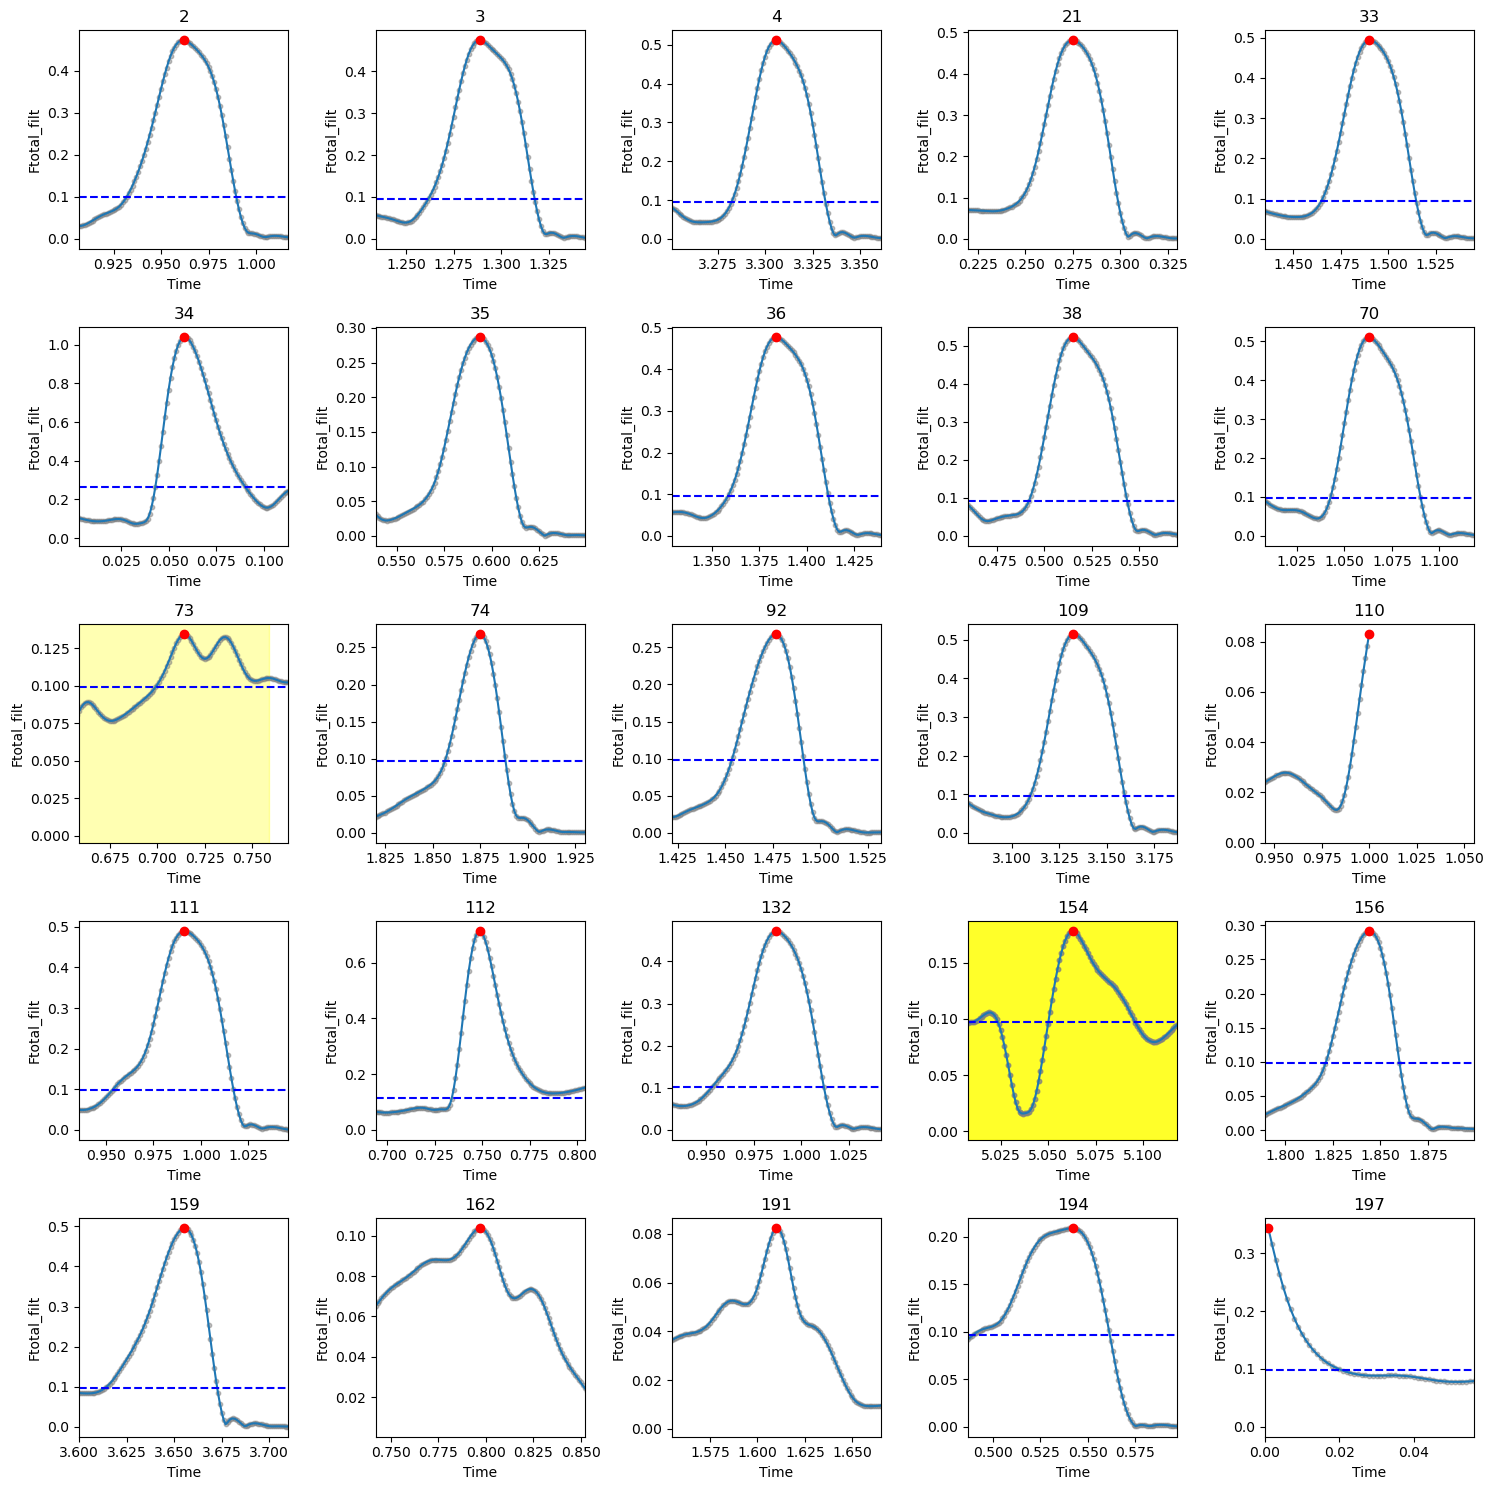

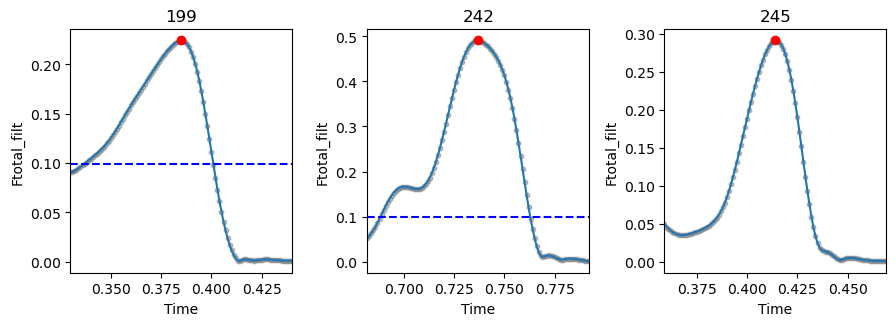

In [ ]:
import matplotlib.pyplot as plt


unique_events = butter_df_day0_bw_eg['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg[butter_df_day0_bw_eg['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            
            # only show the range +-0.05 second around the max force point
            axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.055), maxforce_frame + 0.055)

            # show each data point in dots
            axes[i//cols, i%cols].scatter(event_data['Time'], event_data['Ftotal_filt'], s=10, color='gray', alpha=0.5)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



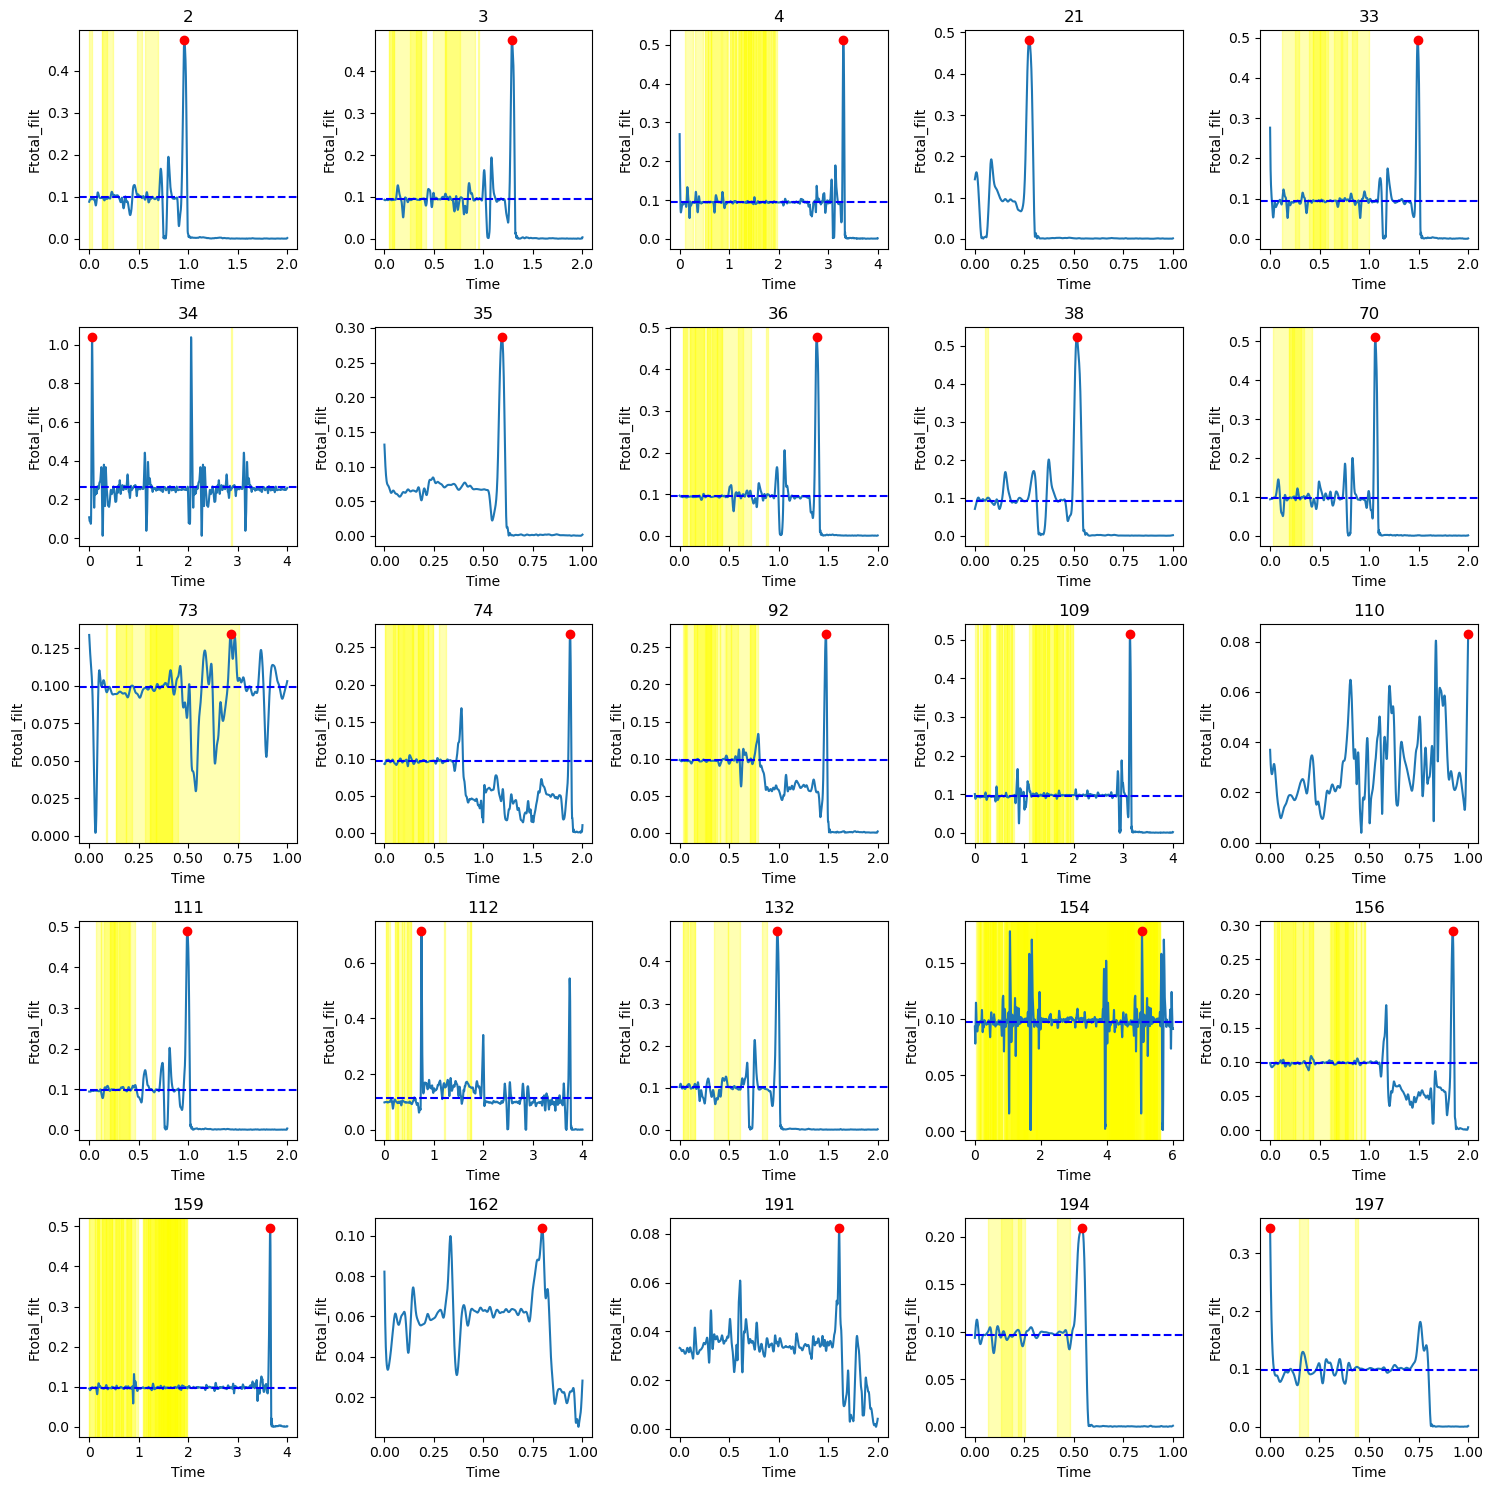

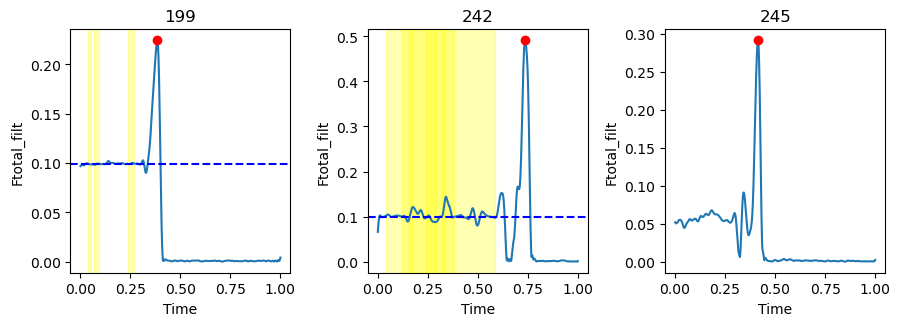

In [24]:
import matplotlib.pyplot as plt
from ipywidgets import interact 


unique_events = butter_df_day0_bw_eg['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg[butter_df_day0_bw_eg['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            # only show the range +-0.05 second around the max force point

            #axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.05), maxforce_frame + 0.05)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



In [ ]:
print("Number of NaN rows:", butter_df_day0_bw_eg['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg['bodyweight'].notna().sum()) #bodyweight if not detected filled. 

Number of NaN rows: 0
Number of non-NaN rows: 65000


In [8]:


# for each event2, calculate impulse and store in a new DataFrame
impulse_list = []

for event in butter_df_day0_bw_eg['event2'].unique():
    
    event_data = butter_df_day0_bw_eg[butter_df_day0_bw_eg['event2'] == event]

    # sort by Time and rearrange index
    event_data = event_data.sort_values(by='Time').reset_index(drop=True)

    # calculate F_impulse, or Ftotal_filt - bodyweight. 
    event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

    # find the peak index of F_impulse
    peak_index = event_data['F_impulse'].idxmax()


    # subset data around peak (±0.055 seconds)
    peak_time = event_data.loc[peak_index, 'Time']
    event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

    #append event_data
    impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
    impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

    # Find start and end indices using iloc

    start_index = None
    end_index = None
    for i in range(len(event_data)):
        if event_data.loc[i, 'F_impulse'] > 0:
            if start_index is None:
                start_index = i
            end_index = i

    # Calculate impulse
    if start_index is None or end_index is None:
        impulse = 0 # good for later filtering out events with no impulse 

    impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s

    impulse_list.append({
                         'RFID': event_data['RFID'].iloc[0],
                         'event2': event, 
                         'datetime': event_data['datetime_x'].iloc[0],
                         'bodyweight': event_data['bodyweight'].iloc[0],
                         'impulse': impulse})

impulse_data.head(10)
impulse_df = pd.DataFrame(impulse_list)
impulse_df.head(20)


C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\995603402.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\995603402.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\995603402.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all

,RFID,event2,datetime,bodyweight,impulse
0,3B00192E1E,2,2025-01-21 08:19:02.583,0.104914,0.012794
1,3B00192E1E,3,2025-01-21 08:20:17.582,0.094161,0.013252
2,3B00192E1E,4,2025-01-21 08:21:31.583,0.094199,0.012859
3,3B00192E1E,21,2025-01-21 08:39:06.598,0.104914,0.011333
4,3B00192E1E,33,2025-01-21 09:14:26.559,0.093793,0.012237
5,3B00192E1E,34,2025-01-21 09:15:02.560,0.104914,0.029747
6,3B00192E1E,35,2025-01-21 09:15:14.561,0.104914,0.004330
7,3B00192E1E,36,2025-01-21 09:16:19.561,0.094089,0.012675
8,3B00192E1E,38,2025-01-21 09:17:14.562,0.104914,0.013408
9,3B00192E1E,70,2025-01-21 09:49:25.583,0.104914,0.012251


In [9]:
impulse_df.to_csv('data/impulse_21JAN_E1E.csv')

###### 3F2 12-23

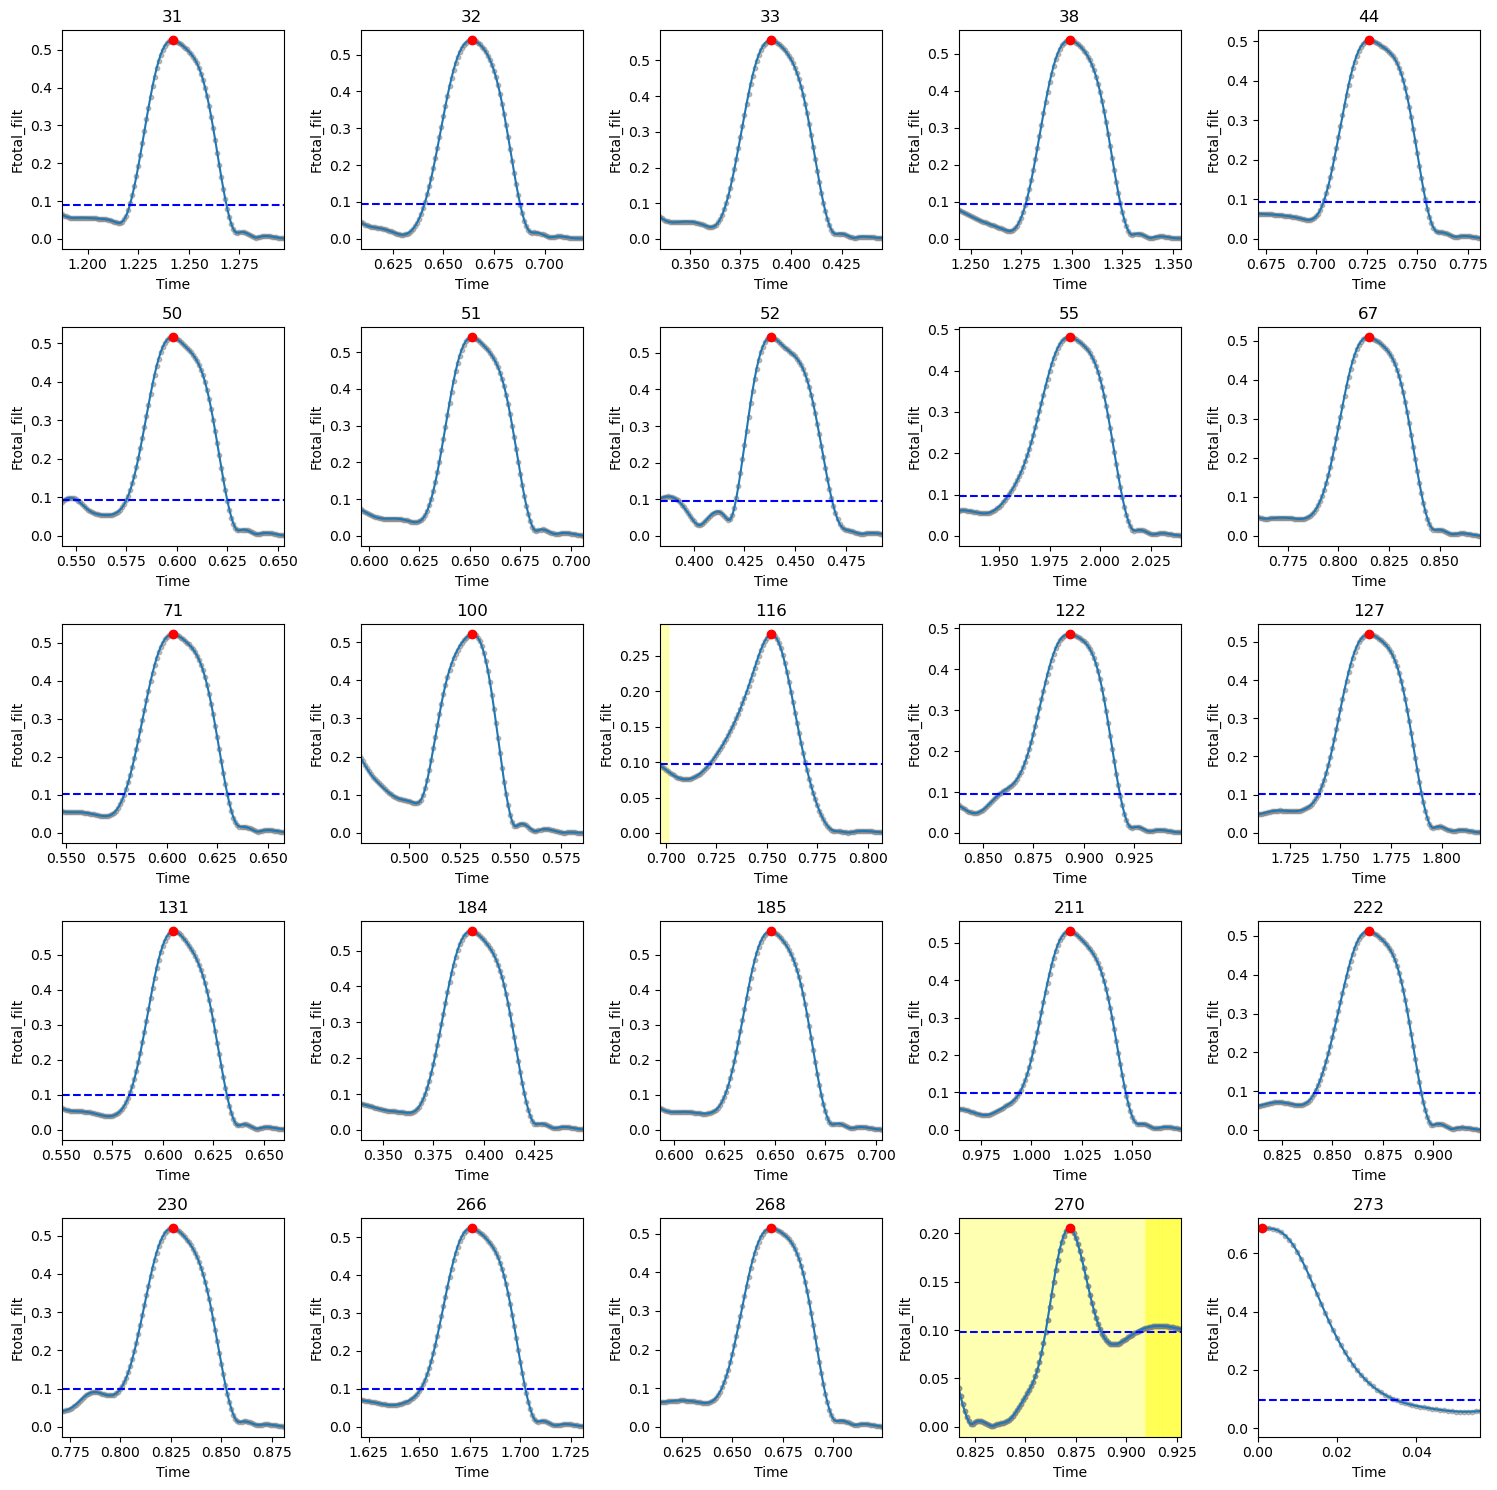

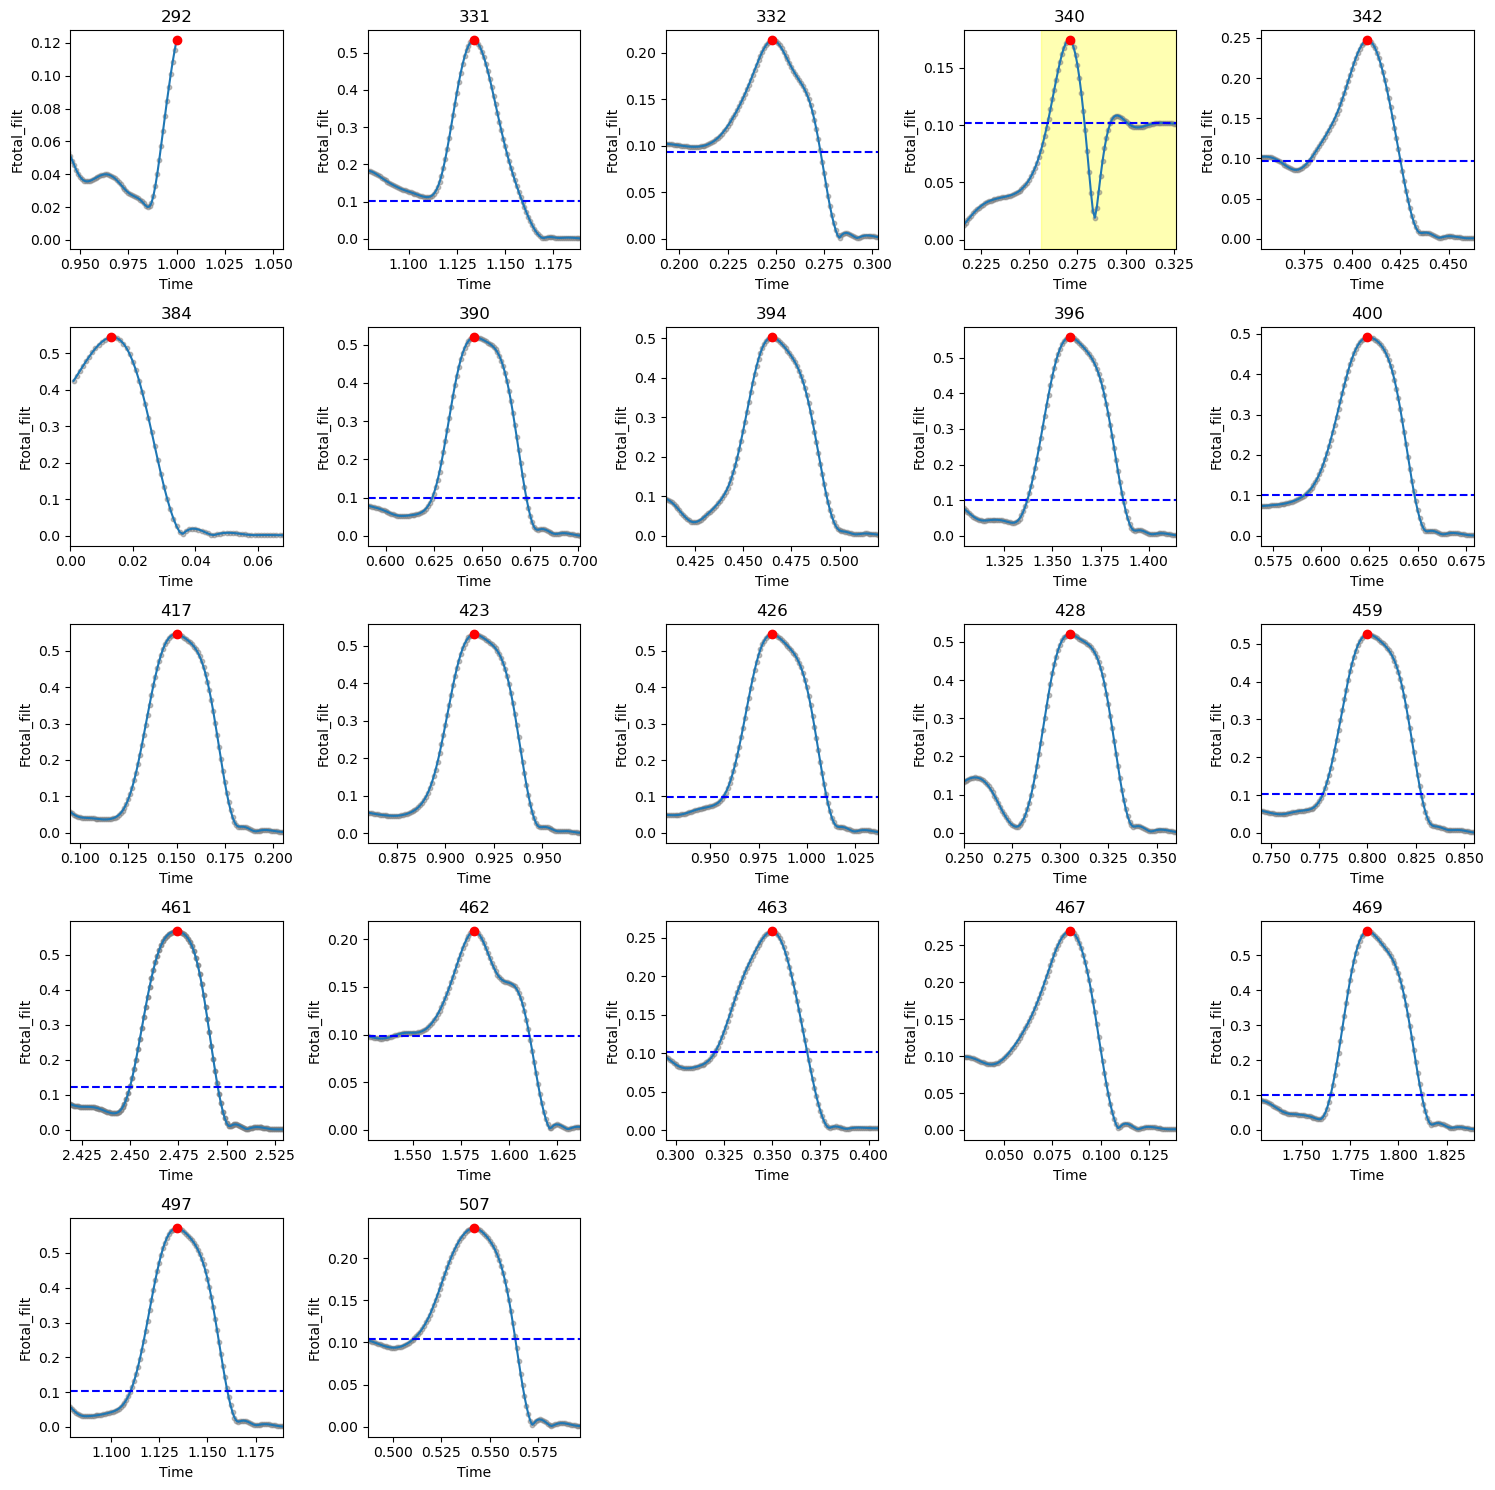

In [16]:
import matplotlib.pyplot as plt


unique_events = butter_df_day0_bw_eg2['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg2[butter_df_day0_bw_eg2['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            
            # only show the range +-0.05 second around the max force point
            axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.055), maxforce_frame + 0.055)

            # show each data point in dots
            axes[i//cols, i%cols].scatter(event_data['Time'], event_data['Ftotal_filt'], s=10, color='gray', alpha=0.5)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



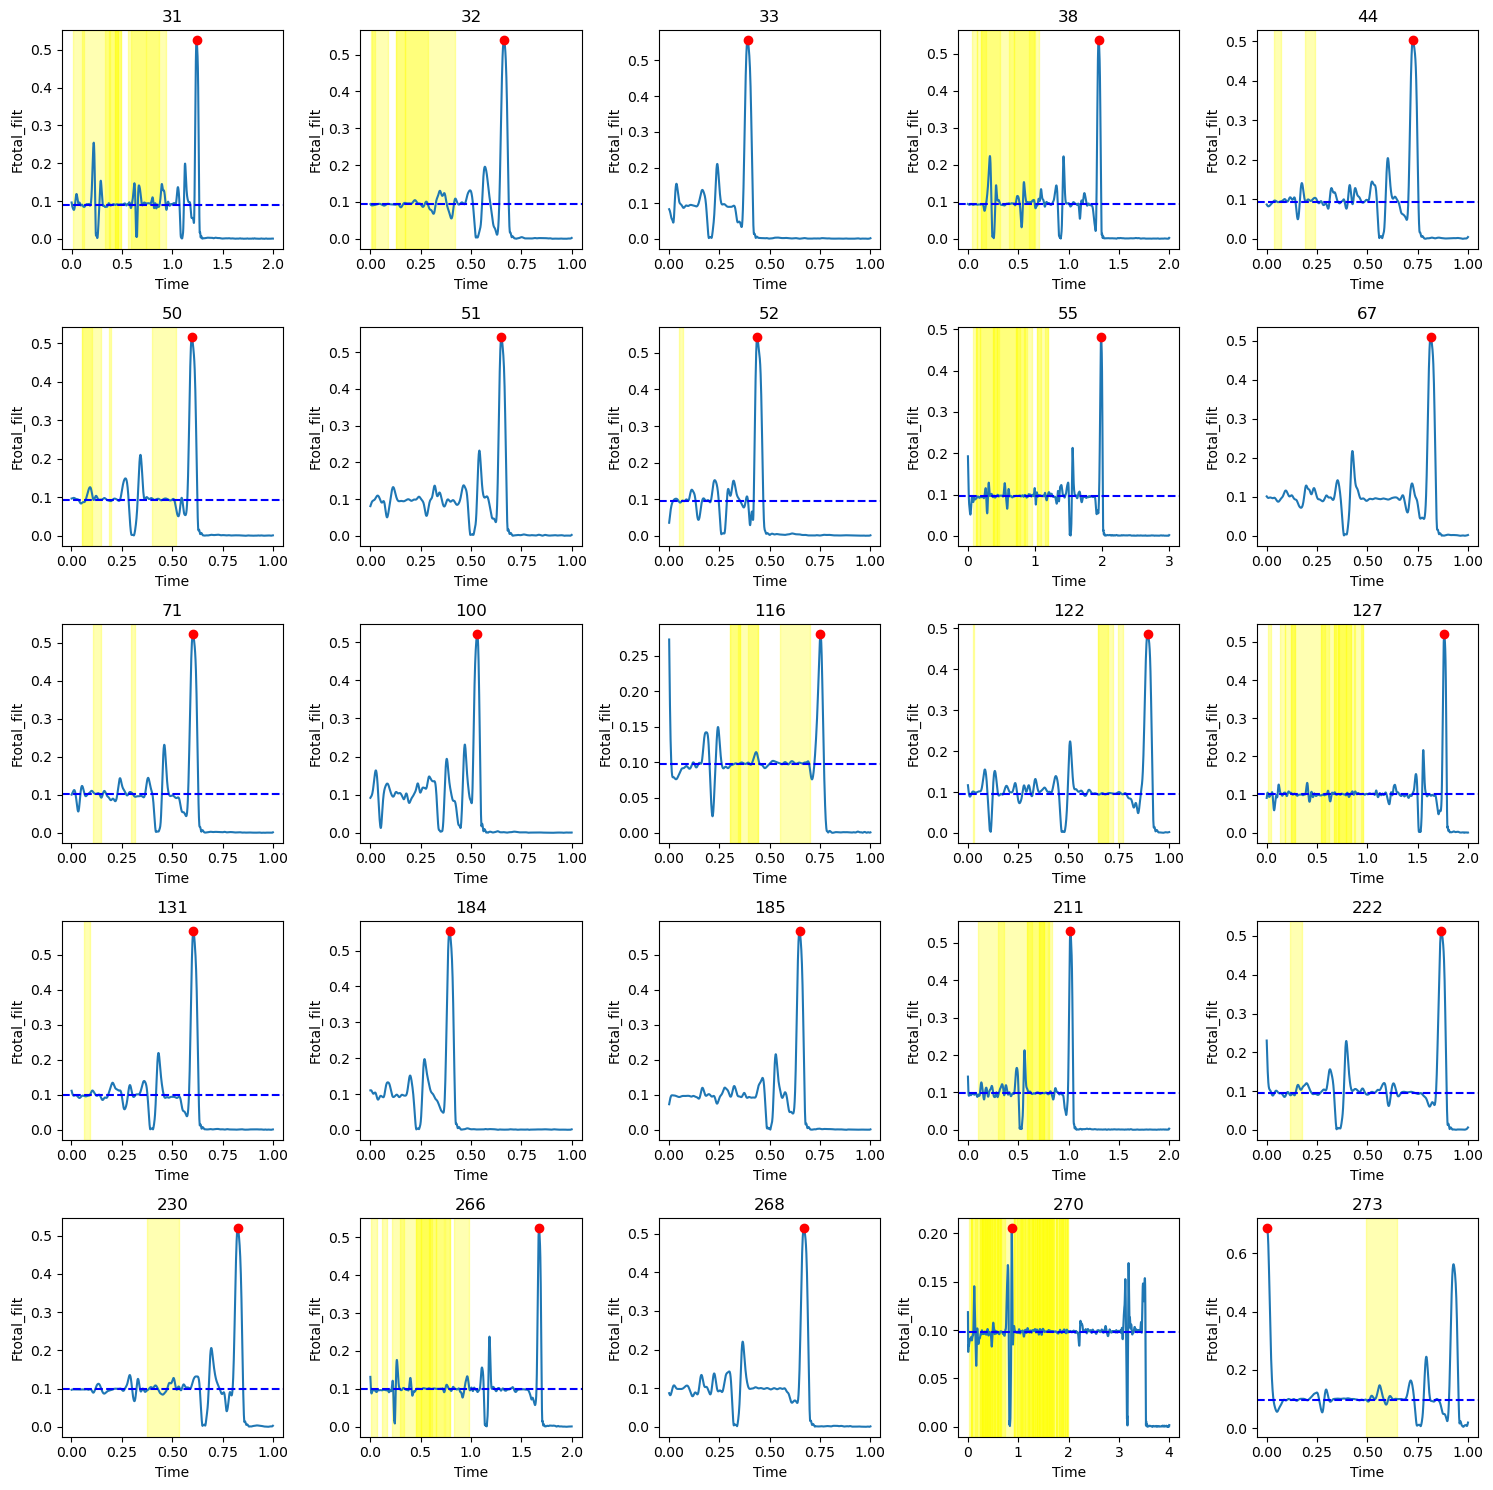

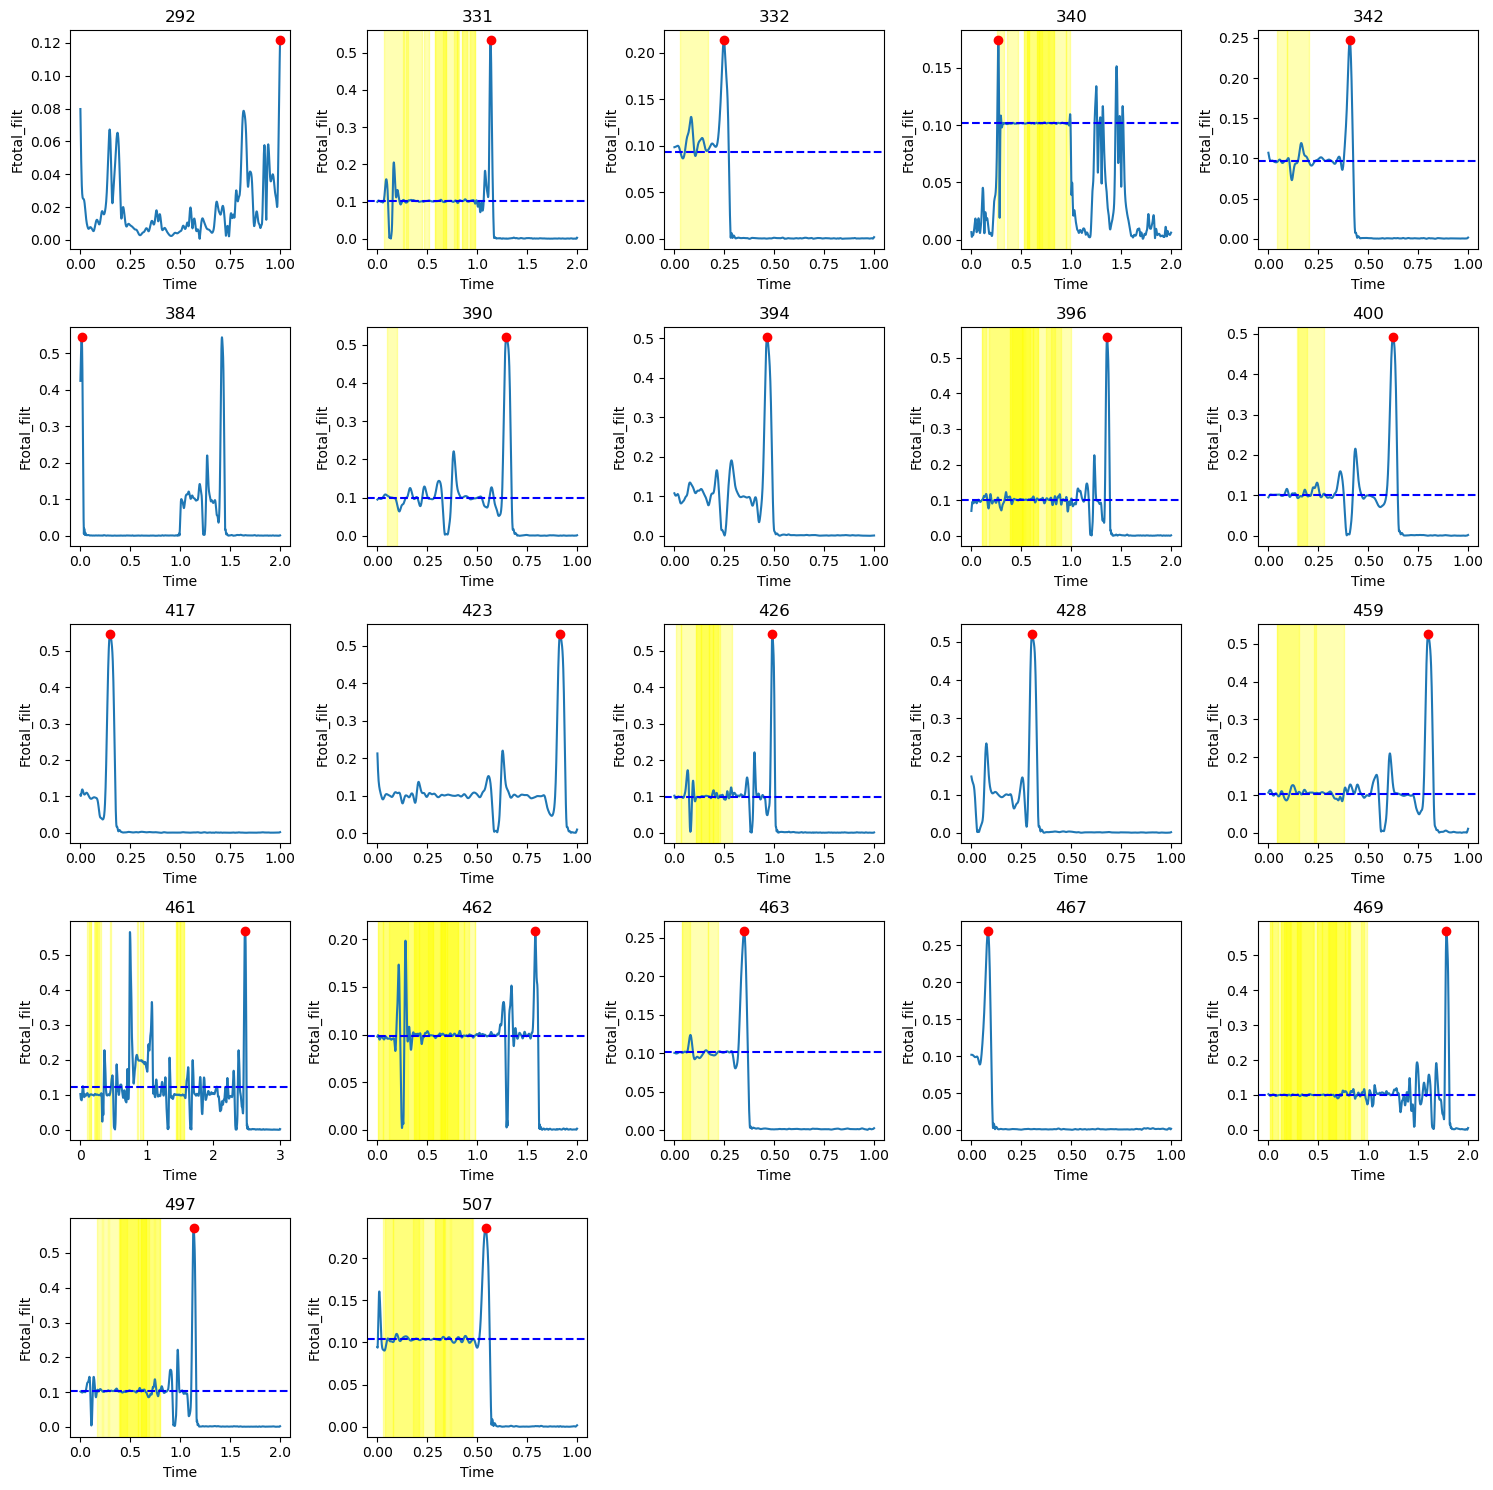

In [17]:
import matplotlib.pyplot as plt
from ipywidgets import interact 


unique_events = butter_df_day0_bw_eg2['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg2[butter_df_day0_bw_eg2['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            # only show the range +-0.05 second around the max force point

            #axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.05), maxforce_frame + 0.05)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



In [18]:
print("Number of NaN rows:", butter_df_day0_bw_eg2['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg2['bodyweight'].notna().sum()) #bodyweight if not detected filled. 

Number of NaN rows: 0
Number of non-NaN rows: 74000


In [10]:


# for each event2, calculate impulse and store in a new DataFrame
impulse_list = []

for event in butter_df_day0_bw_eg2['event2'].unique():
    
    event_data = butter_df_day0_bw_eg2[butter_df_day0_bw_eg2['event2'] == event]

    # sort by Time and rearrange index
    event_data = event_data.sort_values(by='Time').reset_index(drop=True)

    # calculate F_impulse, or Ftotal_filt - bodyweight. 
    event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

    # find the peak index of F_impulse
    peak_index = event_data['F_impulse'].idxmax()


    # subset data around peak (±0.055 seconds)
    peak_time = event_data.loc[peak_index, 'Time']
    event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

    #append event_data
    impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
    impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

    # Find start and end indices using iloc

    start_index = None
    end_index = None
    for i in range(len(event_data)):
        if event_data.loc[i, 'F_impulse'] > 0:
            if start_index is None:
                start_index = i
            end_index = i

    # Calculate impulse
    if start_index is None or end_index is None:
        impulse = 0 # good for later filtering out events with no impulse 

    impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s

    impulse_list.append({
                         'RFID': event_data['RFID'].iloc[0],
                         'event2': event, 
                         'datetime': event_data['datetime_x'].iloc[0],
                         'bodyweight': event_data['bodyweight'].iloc[0],
                         'impulse': impulse})

impulse_data.head(10)
impulse_df = pd.DataFrame(impulse_list)
impulse_df.head(20)


C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\3536785825.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\3536785825.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\3536785825.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or 

,RFID,event2,datetime,bodyweight,impulse
0,3B004873F2,31,2024-12-23 08:47:27.182,0.090923,0.013636
1,3B004873F2,32,2024-12-23 08:48:57.187,0.093186,0.013477
2,3B004873F2,33,2024-12-23 08:50:40.186,0.105922,0.013893
3,3B004873F2,38,2024-12-23 09:02:14.131,0.105922,0.012946
4,3B004873F2,44,2024-12-23 09:17:32.842,0.105922,0.013079
5,3B004873F2,50,2024-12-23 09:23:43.846,0.094434,0.012667
6,3B004873F2,51,2024-12-23 09:25:18.846,0.105922,0.013012
7,3B004873F2,52,2024-12-23 09:26:39.847,0.105922,0.012318
8,3B004873F2,55,2024-12-23 09:34:08.851,0.105922,0.012569
9,3B004873F2,67,2024-12-23 09:45:51.860,0.105922,0.012863


In [11]:
impulse_df.to_csv('data/impulse_23DEC_3F2.csv')

###### 99B 12-31

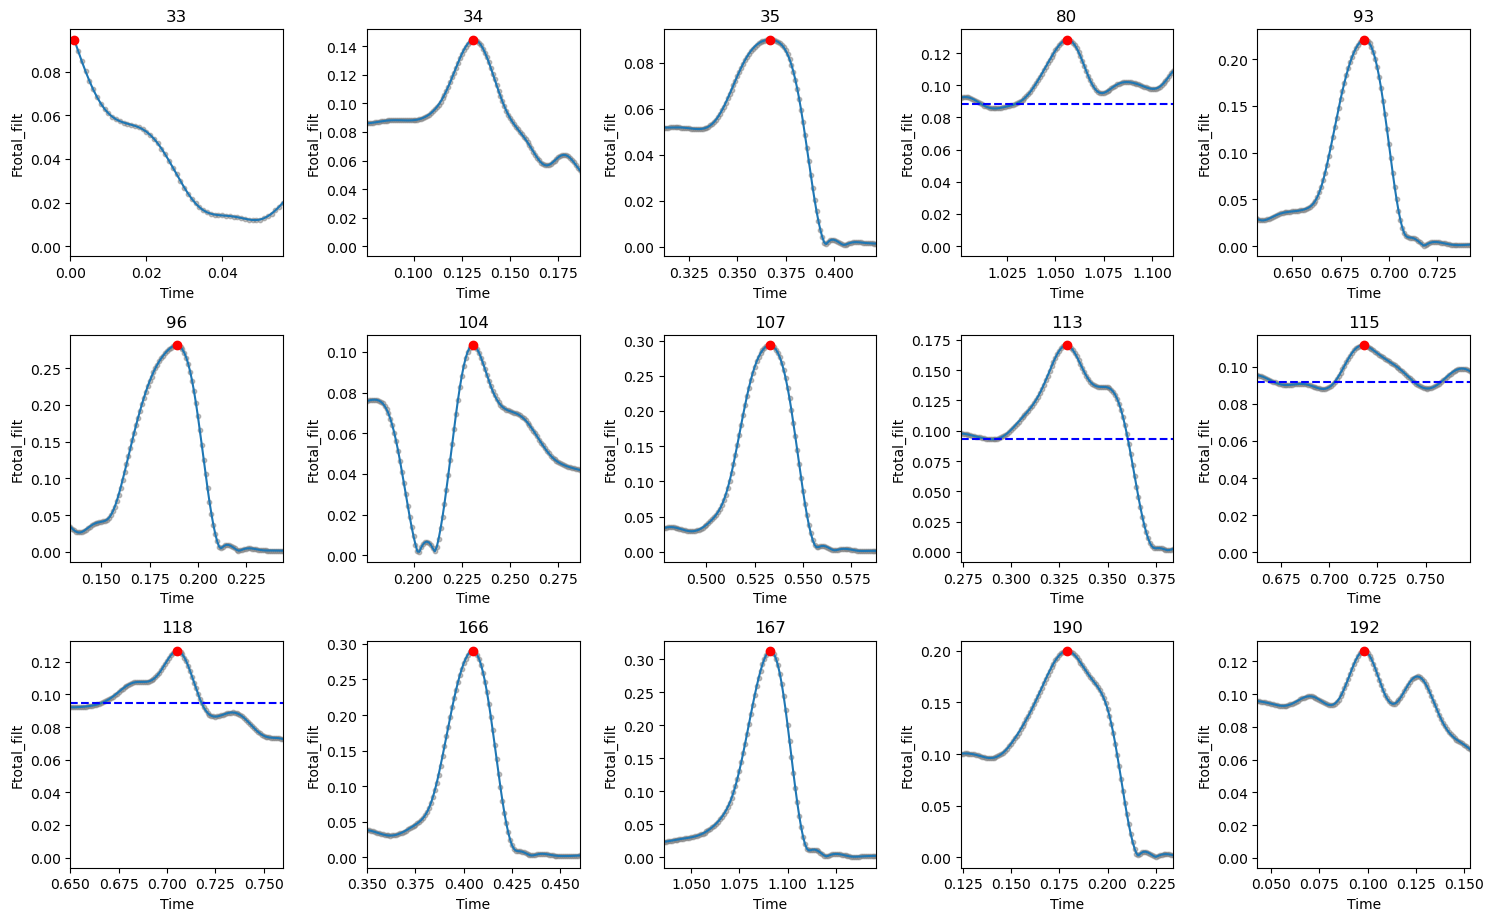

In [22]:
import matplotlib.pyplot as plt


unique_events = butter_df_day0_bw_eg3['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg3[butter_df_day0_bw_eg3['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            
            # only show the range +-0.05 second around the max force point
            axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.055), maxforce_frame + 0.055)

            # show each data point in dots
            axes[i//cols, i%cols].scatter(event_data['Time'], event_data['Ftotal_filt'], s=10, color='gray', alpha=0.5)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



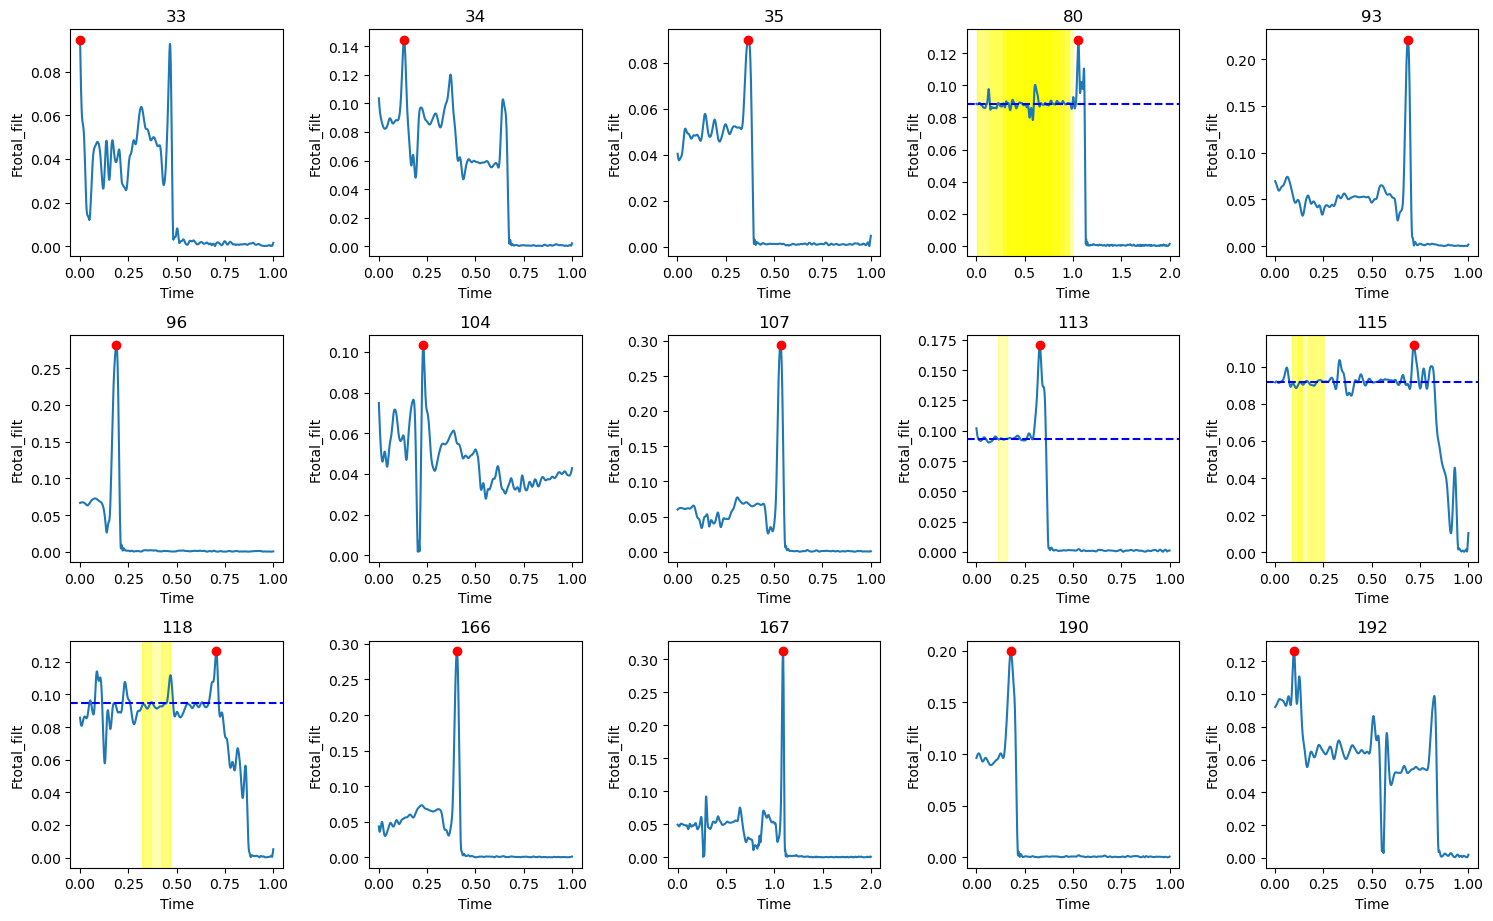

In [23]:
import matplotlib.pyplot as plt
from ipywidgets import interact 


unique_events = butter_df_day0_bw_eg3['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg3[butter_df_day0_bw_eg3['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            # only show the range +-0.05 second around the max force point

            #axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.05), maxforce_frame + 0.05)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



In [25]:
print("Number of NaN rows:", butter_df_day0_bw_eg3['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg3['bodyweight'].notna().sum()) #bodyweight if not detected filled. 

Number of NaN rows: 0
Number of non-NaN rows: 17000


In [12]:


# for each event2, calculate impulse and store in a new DataFrame
impulse_list = []

for event in butter_df_day0_bw_eg3['event2'].unique():
    
    event_data = butter_df_day0_bw_eg3[butter_df_day0_bw_eg3['event2'] == event]

    # sort by Time and rearrange index
    event_data = event_data.sort_values(by='Time').reset_index(drop=True)

    # calculate F_impulse, or Ftotal_filt - bodyweight. 
    event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

    # find the peak index of F_impulse
    peak_index = event_data['F_impulse'].idxmax()


    # subset data around peak (±0.055 seconds)
    peak_time = event_data.loc[peak_index, 'Time']
    event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

    #append event_data
    impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
    impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

    # Find start and end indices using iloc

    start_index = None
    end_index = None
    for i in range(len(event_data)):
        if event_data.loc[i, 'F_impulse'] > 0:
            if start_index is None:
                start_index = i
            end_index = i

    # Calculate impulse
    if start_index is None or end_index is None:
        impulse = 0 # good for later filtering out events with no impulse 

    impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s

    impulse_list.append({
                         'RFID': event_data['RFID'].iloc[0],
                         'event2': event, 
                         'datetime': event_data['datetime_x'].iloc[0],
                         'bodyweight': event_data['bodyweight'].iloc[0],
                         'impulse': impulse})

impulse_data.head(10)
impulse_df = pd.DataFrame(impulse_list)
impulse_df.head(20)


C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2275650612.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2275650612.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2275650612.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or 

,RFID,event2,datetime,bodyweight,impulse
0,3B0018A99B,33,2024-12-31 09:00:46.322,0.095753,-0.003250
1,3B0018A99B,34,2024-12-31 09:02:16.323,0.095753,0.001001
2,3B0018A99B,35,2024-12-31 09:03:18.323,0.095753,-0.005363
3,3B0018A99B,80,2024-12-31 09:48:40.357,0.087699,0.001449
4,3B0018A99B,93,2024-12-31 10:16:19.327,0.095753,0.002583
5,3B0018A99B,96,2024-12-31 10:17:43.329,0.095753,0.005290
6,3B0018A99B,104,2024-12-31 10:28:29.336,0.095753,0.000043
7,3B0018A99B,107,2024-12-31 10:31:17.339,0.095753,0.004812
8,3B0018A99B,113,2024-12-31 11:04:27.786,0.093216,0.002697
9,3B0018A99B,115,2024-12-31 11:16:06.792,0.092028,0.000457


In [13]:
impulse_df.to_csv('data/impulse_31DEC_99B.csv')

###### 043 02-12

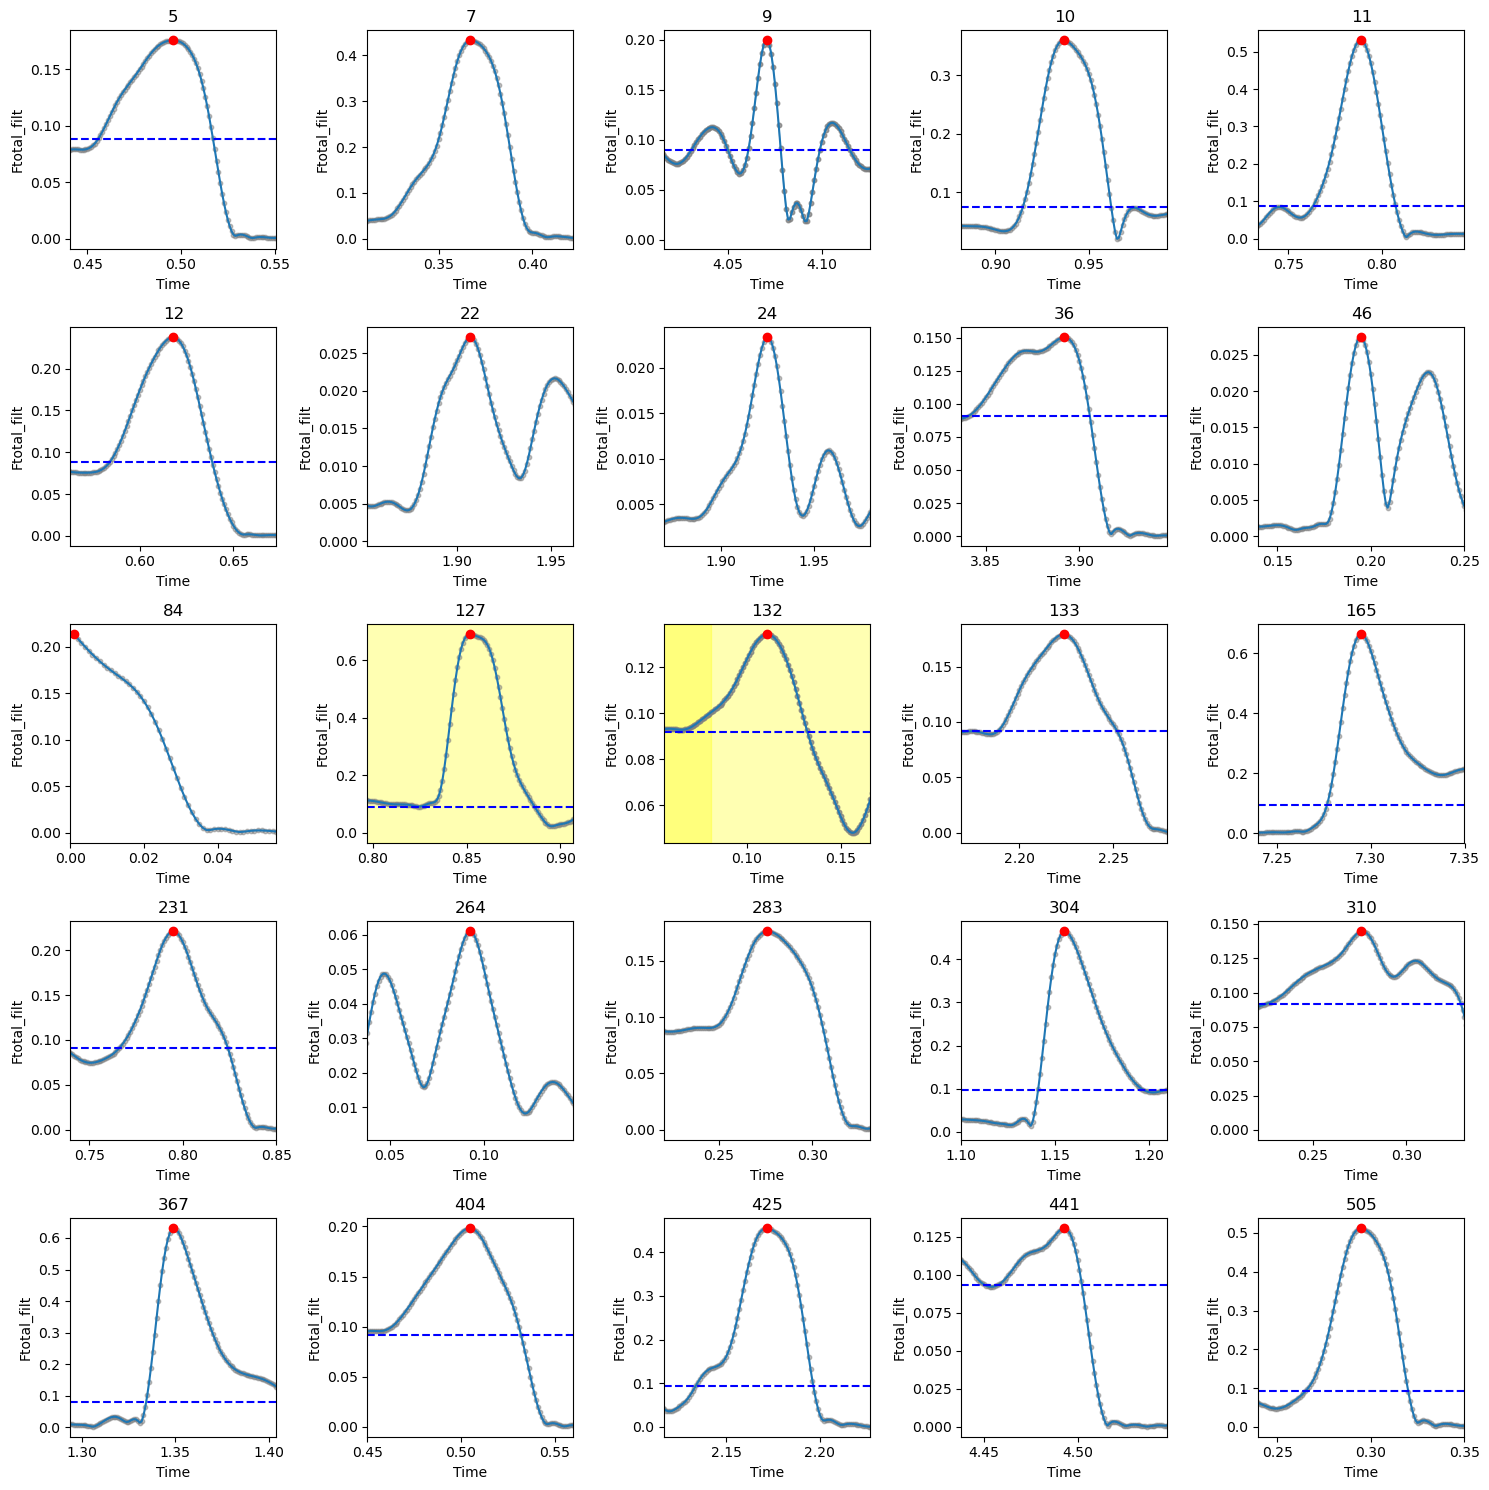

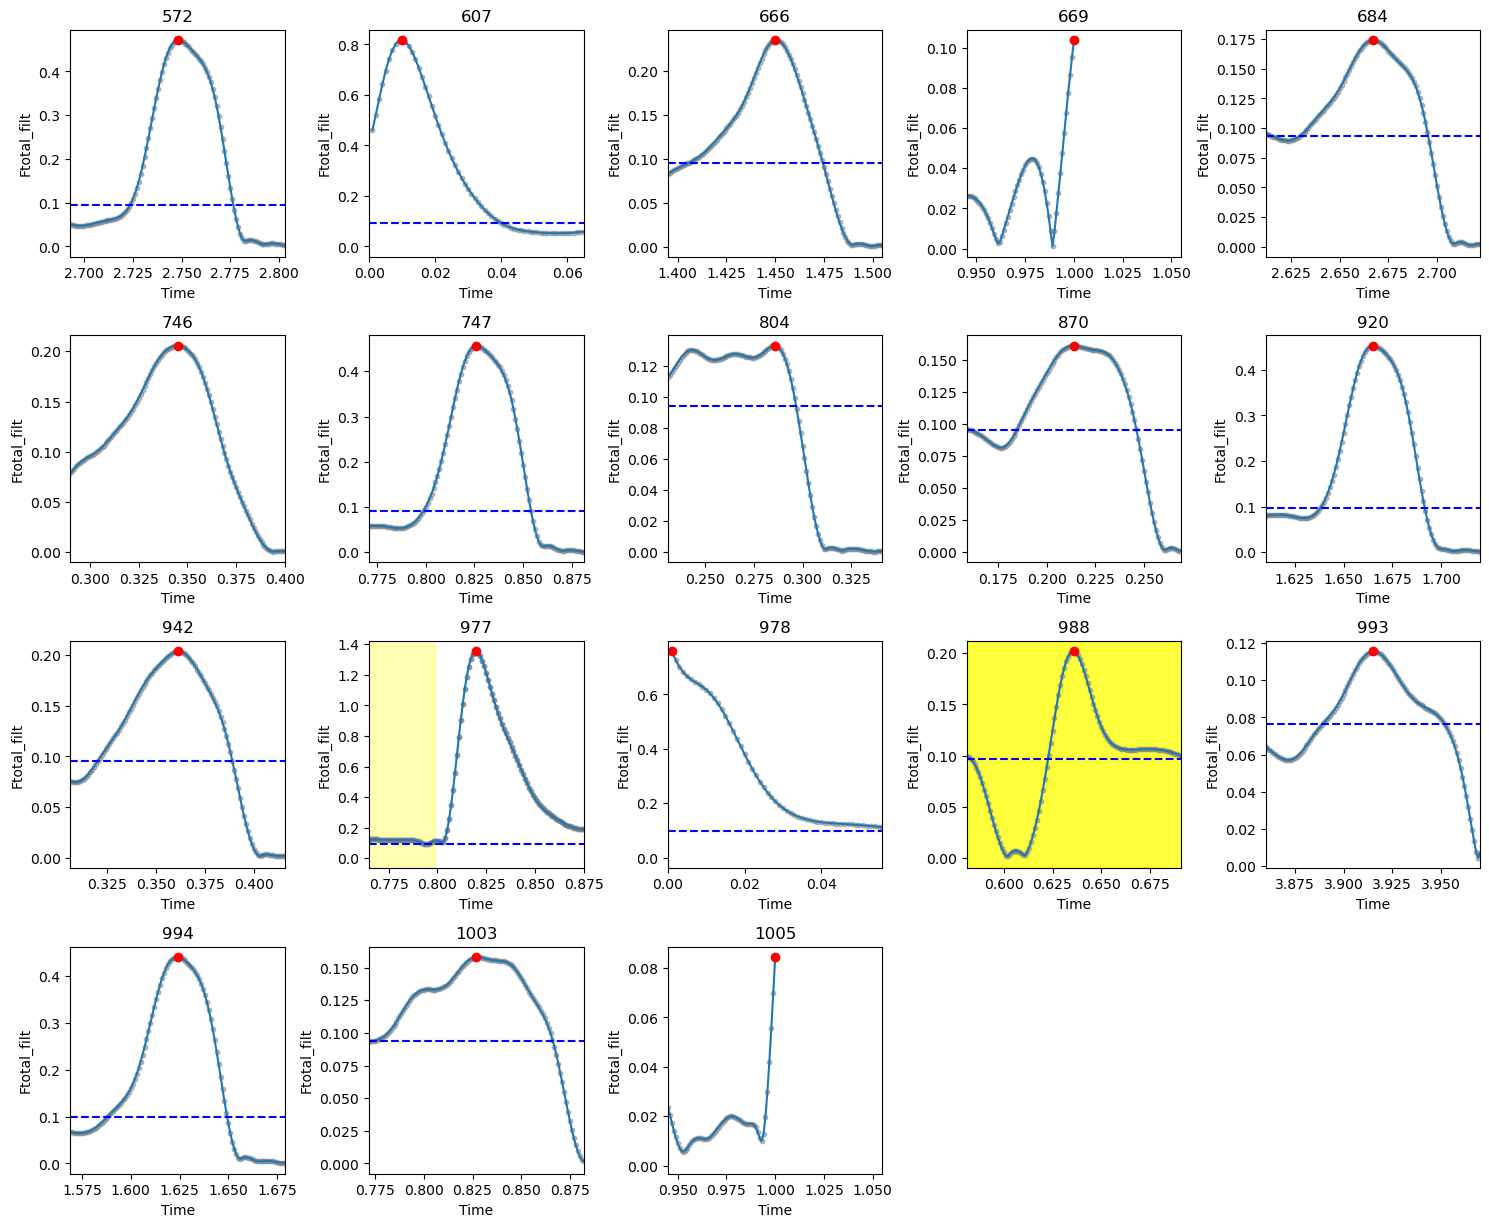

In [28]:
import matplotlib.pyplot as plt


unique_events = butter_df_day0_bw_eg4['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg4[butter_df_day0_bw_eg4['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            
            # only show the range +-0.05 second around the max force point
            axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.055), maxforce_frame + 0.055)

            # show each data point in dots
            axes[i//cols, i%cols].scatter(event_data['Time'], event_data['Ftotal_filt'], s=10, color='gray', alpha=0.5)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



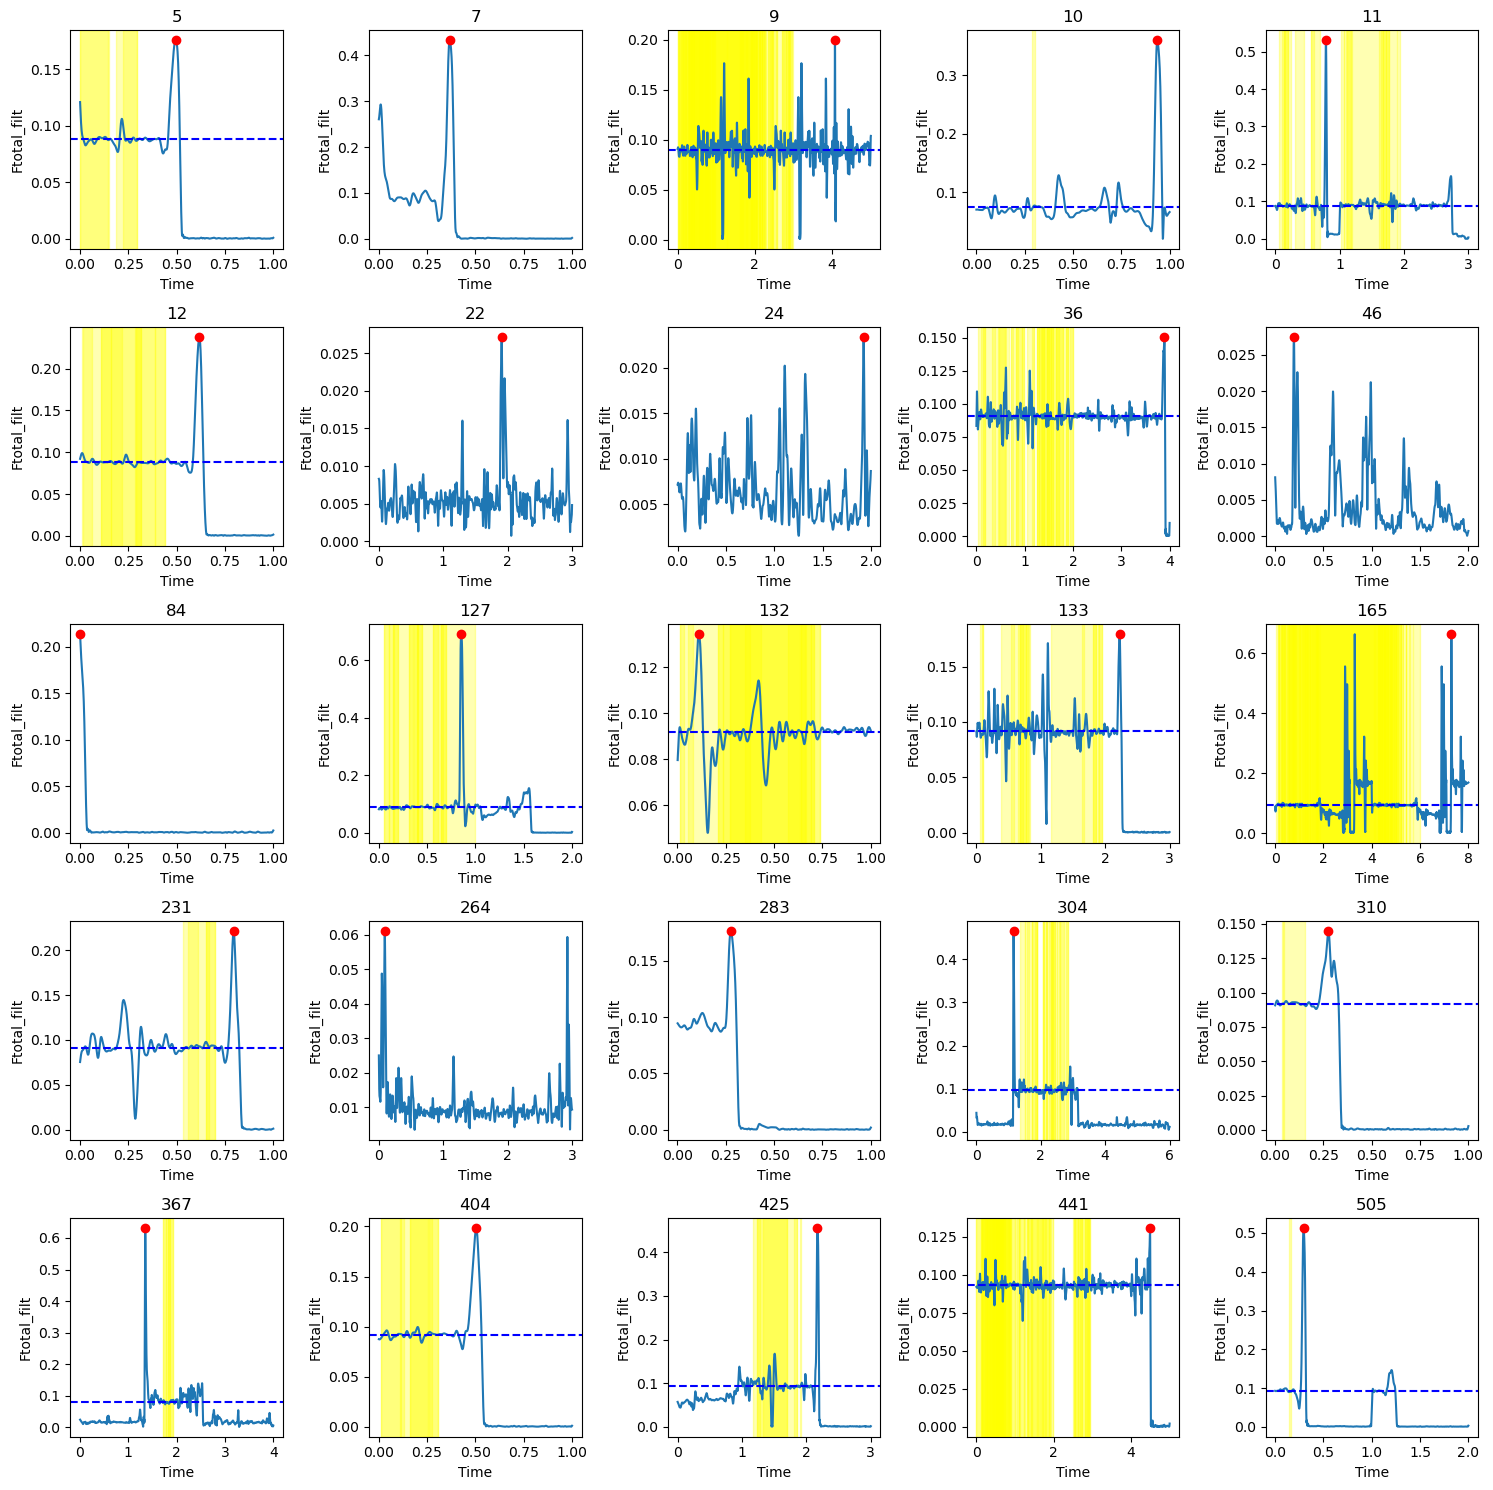

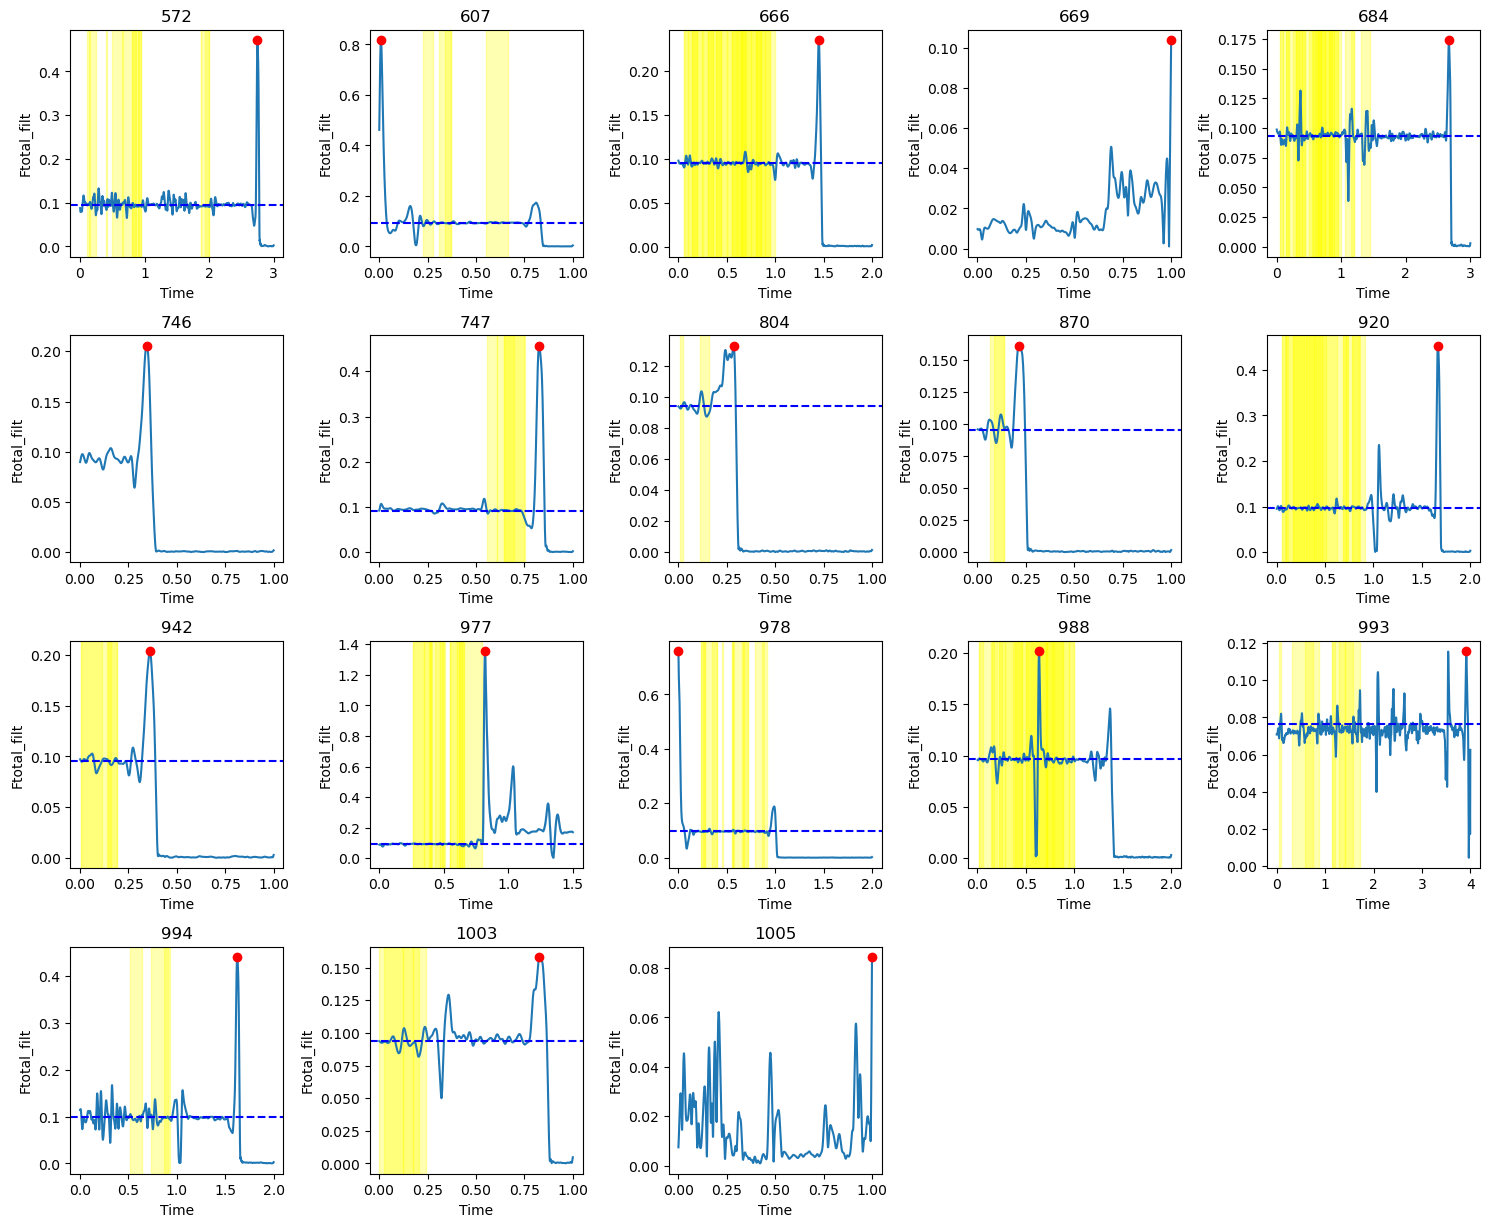

In [29]:
import matplotlib.pyplot as plt
from ipywidgets import interact 


unique_events = butter_df_day0_bw_eg4['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg4[butter_df_day0_bw_eg4['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            # only show the range +-0.05 second around the max force point

            #axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.05), maxforce_frame + 0.05)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



In [14]:
print("Number of NaN rows:", butter_df_day0_bw_eg4['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg4['bodyweight'].notna().sum()) #bodyweight if not detected filled. 

Number of NaN rows: 8000
Number of non-NaN rows: 95000


In [15]:
# (optional) delete the rows with NaN in bodyweight column
butter_df_day0_bw_eg4 = butter_df_day0_bw_eg4.dropna(subset=['bodyweight'])
print("Number of NaN rows:", butter_df_day0_bw_eg4['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg4['bodyweight'].notna().sum()) #bodyweight if not detected filled.


Number of NaN rows: 0
Number of non-NaN rows: 95000


In [16]:


# for each event2, calculate impulse and store in a new DataFrame
impulse_list = []

for event in butter_df_day0_bw_eg4['event2'].unique():
    
    event_data = butter_df_day0_bw_eg4[butter_df_day0_bw_eg4['event2'] == event]

    # sort by Time and rearrange index
    event_data = event_data.sort_values(by='Time').reset_index(drop=True)

    # calculate F_impulse, or Ftotal_filt - bodyweight. 
    event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

    # find the peak index of F_impulse
    peak_index = event_data['F_impulse'].idxmax()


    # subset data around peak (±0.055 seconds)
    peak_time = event_data.loc[peak_index, 'Time']
    event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

    #append event_data
    impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
    impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

    # Find start and end indices using iloc

    start_index = None
    end_index = None
    for i in range(len(event_data)):
        if event_data.loc[i, 'F_impulse'] > 0:
            if start_index is None:
                start_index = i
            end_index = i

    # Calculate impulse
    if start_index is None or end_index is None:
        impulse = 0 # good for later filtering out events with no impulse 

    impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s

    impulse_list.append({
                         'RFID': event_data['RFID'].iloc[0],
                         'event2': event, 
                         'datetime': event_data['datetime_x'].iloc[0],
                         'bodyweight': event_data['bodyweight'].iloc[0],
                         'impulse': impulse})

impulse_data.head(10)
impulse_df = pd.DataFrame(impulse_list)
impulse_df.head(20)


C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2110713795.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2110713795.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2110713795.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or 

,RFID,event2,datetime,bodyweight,impulse
0,3B00484043,5,2025-02-12 08:15:36.115,0.093821,0.003143
1,3B00484043,7,2025-02-12 08:16:51.092,0.093821,0.011243
2,3B00484043,9,2025-02-12 08:17:20.034,0.088139,0.001288
3,3B00484043,10,2025-02-12 08:17:27.022,0.093821,0.007839
4,3B00484043,11,2025-02-12 08:18:11.930,0.093821,0.010083
5,3B00484043,12,2025-02-12 08:18:33.886,0.088441,0.004797
6,3B00484043,22,2025-02-12 08:44:31.529,0.093821,-0.008792
7,3B00484043,24,2025-02-12 08:44:55.530,0.093821,-0.009450
8,3B00484043,36,2025-02-12 09:01:40.540,0.090284,0.002481
9,3B00484043,46,2025-02-12 09:11:06.546,0.093821,-0.009228


In [ ]:
impulse_df.to_csv('data/impulse_12FEB_043.csv')

###### 652 01-24

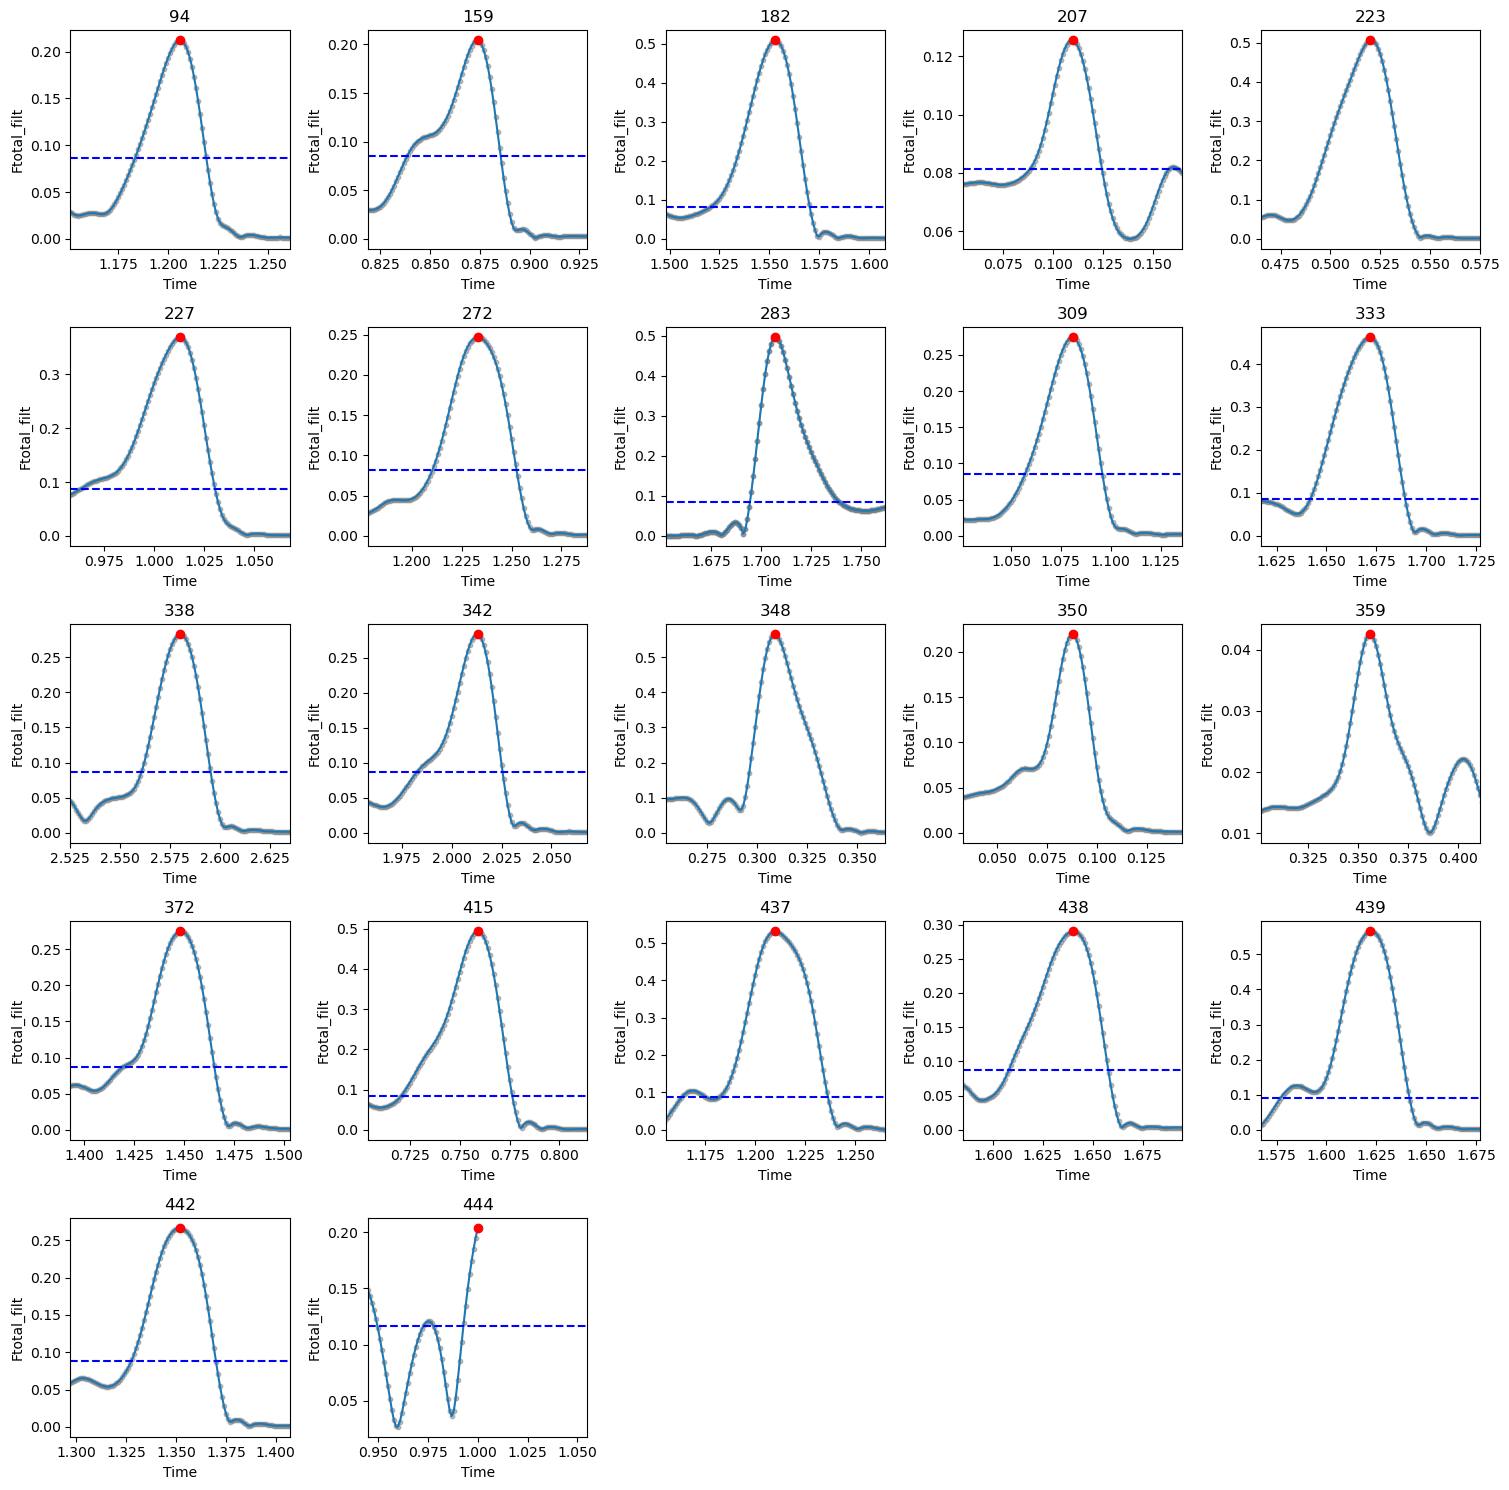

In [35]:
import matplotlib.pyplot as plt


unique_events = butter_df_day0_bw_eg5['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg5[butter_df_day0_bw_eg5['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            
            # only show the range +-0.05 second around the max force point
            axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.055), maxforce_frame + 0.055)

            # show each data point in dots
            axes[i//cols, i%cols].scatter(event_data['Time'], event_data['Ftotal_filt'], s=10, color='gray', alpha=0.5)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



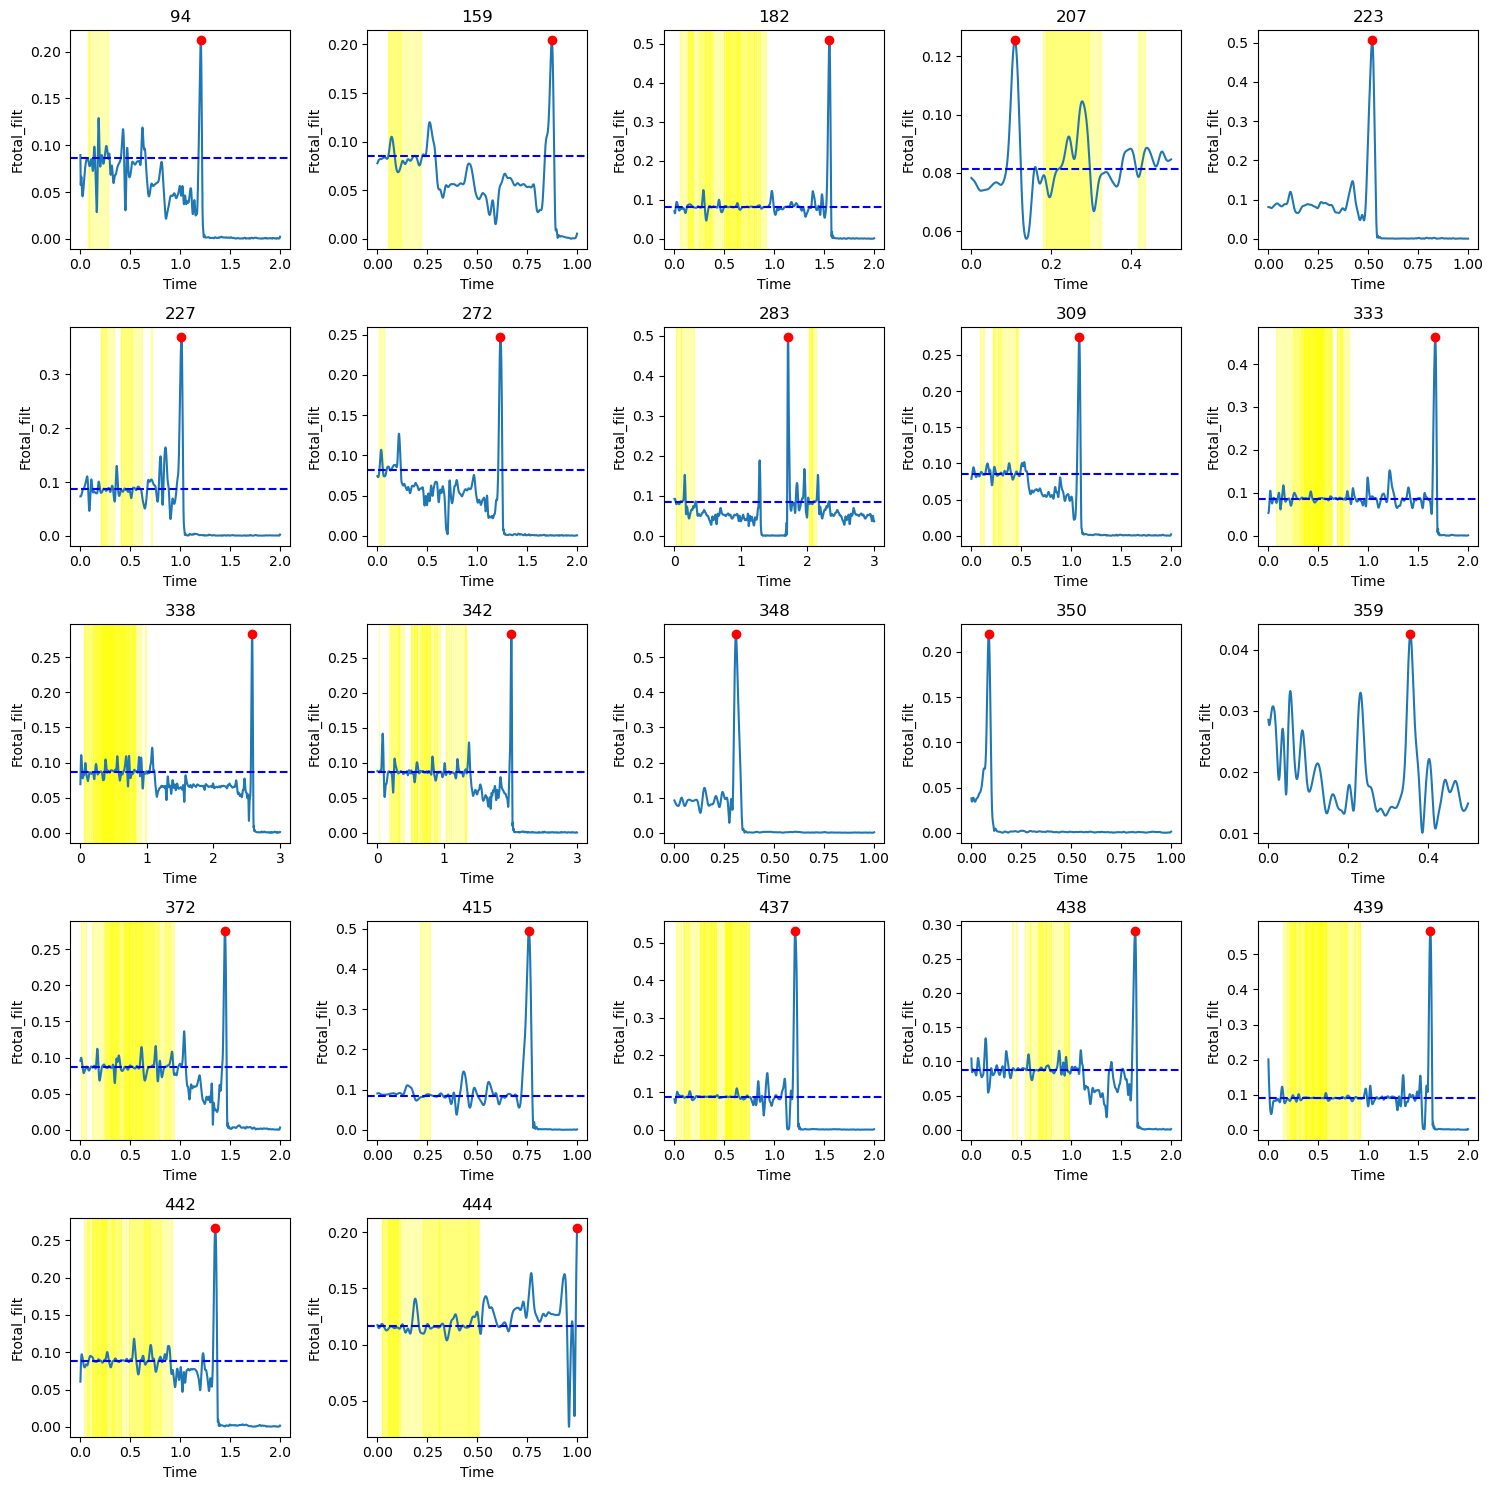

In [36]:
import matplotlib.pyplot as plt
from ipywidgets import interact 


unique_events = butter_df_day0_bw_eg5['event2'].unique()
num_events = len(unique_events)
cols = 5  # Number of columns in the grid
rows = 5  # Number of rows in the grid
grids = math.ceil(num_events / (rows * cols))  # Calculate the number of grids needed

for g in range(grids):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i in range(rows * cols):
        event_index = g * (rows * cols) + i
        if event_index < num_events:
            event = unique_events[event_index]
            event_data = butter_df_day0_bw_eg5[butter_df_day0_bw_eg5['event2'] == event].reset_index(drop = True)
            event_data_bw_frames, event_data_bw = force_defs.detect_bw_Ftot(event_data, var_threshold=0.00005, frame_length=50)
            
            sns.lineplot(x='Time', y='Ftotal_filt', data=event_data, ax=axes[i//cols, i%cols])
            for start, end in event_data_bw_frames: #halved and variation threshold put 
                #print(f"Start: {start}, End: {end}, Length: {len(event_data)}")  # Debugging print statement
                axes[i//cols, i%cols].axvspan(event_data['Time'].iloc[start], event_data['Time'].iloc[end], color='yellow', alpha=0.3, label='bodyweight(N)' if start == event_data_bw_frames[0][0] else "")
            #mark the max force point in red dot 
            maxforce_index = event_data['Ftotal_filt'].idxmax()
            maxforce_frame = event_data.loc[maxforce_index, 'Time']
            maxforce_value = event_data.loc[maxforce_index, 'Ftotal_filt']
            axes[i//cols, i%cols].plot(maxforce_frame, maxforce_value, 'ro')  # 'ro' for red dot
            # only show the range +-0.05 second around the max force point

            #axes[i//cols, i%cols].set_xlim(max(0, maxforce_frame - 0.05), maxforce_frame + 0.05)

            #mark the max Fx point in blue dot 
            #maxFx_index = event_data['Fx_filt'].idxmax()
            #maxFx_frame = event_data.loc[maxFx_index, 'Frame']
            #maxFx_value = event_data.loc[maxFx_index, 'Fx_filt']
            #axes[i//cols, i%cols].plot(maxFx_frame, maxFx_value, 'bo')  # 'bo' for blue dot

            #mark the max Fy point in green dot 
            #maxFy_index = event_data['Fy_filt'].idxmax()
            #maxFy_frame = event_data.loc[maxFy_index, 'Frame']
            ##maxFy_value = event_data.loc[maxFy_index, 'Fy_filt']
            #axes[i//cols, i%cols].plot(maxFy_frame, maxFy_value, 'go')  # 'go' for green dot

            # Mark the bodyweight as a dashed line if it is nont NaN
            bodyweight_value = event_data_bw  # Assuming bodyweight is constant
            if not np.isnan(bodyweight_value):
                axes[i//cols, i%cols].axhline(bodyweight_value, color='blue', linestyle='--', label='Bodyweight')
            
            # Set the title to the RFID of the event_data
            event2 = event_data['event2'].iloc[0] 
            axes[i//cols, i%cols].set_title(f'{event2}')
        else:
            fig.delaxes(axes[i//cols, i%cols])  # Remove any empty subplots
    
    #fig.suptitle('Ftot', fontsize=20)

    plt.tight_layout()
    plt.show()



In [5]:
print("Number of NaN rows:", butter_df_day0_bw_eg5['bodyweight'].isna().sum())
print("Number of non-NaN rows:", butter_df_day0_bw_eg5['bodyweight'].notna().sum()) #bodyweight if not detected filled. 

Number of NaN rows: 0
Number of non-NaN rows: 41000


In [17]:


# for each event2, calculate impulse and store in a new DataFrame
impulse_list = []

for event in butter_df_day0_bw_eg5['event2'].unique():
    
    event_data = butter_df_day0_bw_eg5[butter_df_day0_bw_eg5['event2'] == event]

    # sort by Time and rearrange index
    event_data = event_data.sort_values(by='Time').reset_index(drop=True)

    # calculate F_impulse, or Ftotal_filt - bodyweight. 
    event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

    # find the peak index of F_impulse
    peak_index = event_data['F_impulse'].idxmax()


    # subset data around peak (±0.055 seconds)
    peak_time = event_data.loc[peak_index, 'Time']
    event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

    #append event_data
    impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
    impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

    # Find start and end indices using iloc

    start_index = None
    end_index = None
    for i in range(len(event_data)):
        if event_data.loc[i, 'F_impulse'] > 0:
            if start_index is None:
                start_index = i
            end_index = i

    # Calculate impulse
    if start_index is None or end_index is None:
        impulse = 0 # good for later filtering out events with no impulse 

    impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s

    impulse_list.append({
                         'RFID': event_data['RFID'].iloc[0],
                         'event2': event, 
                         'datetime': event_data['datetime_x'].iloc[0],
                         'bodyweight': event_data['bodyweight'].iloc[0],
                         'impulse': impulse})

impulse_data.head(10)
impulse_df = pd.DataFrame(impulse_list)
impulse_df.head(30)


C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2155741908.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2155741908.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)
C:\Users\kmh\AppData\Local\Temp\ipykernel_7436\2155741908.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or 

,RFID,event2,datetime,bodyweight,impulse
0,3B0019F652,94,2025-01-24 10:33:41.424,0.088502,0.002586
1,3B0019F652,159,2025-01-24 11:22:34.412,0.088502,0.002420
2,3B0019F652,182,2025-01-24 11:54:08.179,0.088502,0.010632
3,3B0019F652,207,2025-01-24 12:21:11.155,0.088502,0.000664
4,3B0019F652,223,2025-01-24 12:27:50.157,0.088502,0.012001
5,3B0019F652,227,2025-01-24 12:29:58.159,0.088502,0.008359
6,3B0019F652,272,2025-01-24 12:55:24.175,0.088502,0.004081
7,3B0019F652,283,2025-01-24 12:59:12.178,0.088502,0.017304
8,3B0019F652,309,2025-01-24 13:24:02.152,0.088502,0.004144
9,3B0019F652,333,2025-01-24 13:42:43.167,0.088502,0.010594


In [18]:
impulse_df.to_csv('data/impulse_24JAN_652.csv')

### 4.4 force_outcome

#### a. read butter_df

##### dummies

In [ ]:
# dummy forces are the files I tried with the force sensor mimicking take-off flights. 
butter_df_dummy_forces = force_defs.get_force(butter_df_dummy)

Processing groups:   0%|          | 0/60 [00:00<?, ?it/s]

c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\force_defs.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\force_defs.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)


In [49]:
butter_df_dummy_forces.head(5)

,RFID,datetime,event_no,bodyweight,max_Ftot,ninety9_perc_Ftot,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,max_Fx,time_max_Fx,max_Fy,time_max_Fy,max_Fz,time_max_Fz,Fz_maxFtot
0,NaN,2025-06-11 14:32:54.260,1-2025-06-11,NaN,2.713829,2.708120,0.292,1.989813,-1.807338,2.028184,0.303,0.182667,0.365,0.381500,0.290,0.372878
1,NaN,2025-06-11 14:37:25.269,2-2025-06-11,NaN,2.008567,2.007371,0.391,0.880638,-1.804865,1.079600,0.294,0.165200,0.500,0.056083,0.220,0.035793
2,NaN,2025-06-11 14:38:37.518,3-2025-06-11,0.161732,0.329440,0.311563,0.500,0.321088,-0.021179,0.321088,0.500,0.096469,0.293,0.001545,0.001,-0.070601
3,NaN,2025-06-11 14:38:59.346,4-2025-06-11,NaN,0.230533,0.212939,1.000,0.223990,0.052678,0.223990,1.000,0.091186,0.818,0.025378,0.454,-0.014110
4,NaN,2025-06-11 14:39:19.072,5-2025-06-11,NaN,0.989601,0.987518,0.486,0.476165,-0.854710,0.612576,0.396,0.058822,0.098,0.155656,0.497,0.148487


In [56]:
scare_outcome_df = butter_df_dummy[['event2','day', 'scare_outcome']].drop_duplicates()
print(scare_outcome_df.shape)
scare_outcome_df['event_no'] = scare_outcome_df.apply(lambda row: f"{row['event2']}-{row['day']}", axis=1)
print(scare_outcome_df.head(5))
scare_outcome = scare_outcome_df[['event_no','scare_outcome']]
butter_df_dummy_final = butter_df_dummy_forces.merge(scare_outcome, on = 'event_no')
print(butter_df_dummy_final.head(3))

(60, 3)
     event2         day  scare_outcome      event_no
0         1  2025-06-11              0  1-2025-06-11
500       2  2025-06-11              0  2-2025-06-11
1000      3  2025-06-11              0  3-2025-06-11
1500      4  2025-06-11              0  4-2025-06-11
2500      5  2025-06-11              0  5-2025-06-11
  RFID                datetime      event_no  bodyweight  max_Ftot  \
0  NaN 2025-06-11 14:32:54.260  1-2025-06-11         NaN  2.713829   
1  NaN 2025-06-11 14:37:25.269  2-2025-06-11         NaN  2.008567   
2  NaN 2025-06-11 14:38:37.518  3-2025-06-11    0.161732  0.329440   

   ninety9_perc_Ftot  time_max_Ftot  Fx_maxFtot  Fy_maxFtot    max_Fx  \
0           2.708120          0.292    1.989813   -1.807338  2.028184   
1           2.007371          0.391    0.880638   -1.804865  1.079600   
2           0.311563          0.500    0.321088   -0.021179  0.321088   

   time_max_Fx    max_Fy  time_max_Fy    max_Fz  time_max_Fz  Fz_maxFtot  \
0        0.303  0.182667

In [46]:
butter_df_dummy_forces.to_csv('../data/butter_df_dummy_forces.csv')

#### normal

In [ ]:
impulse_outcome_day0 = force_defs.get_impulse(butter_df_day0_bw)

In [ ]:
butter_df_day1 = pd.read_csv(r'E:\DATA\FTdata\butter_df_day1.csv', index_col = 0)
butter_df_day1.head(3)



,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime,RFID,...,event2,Frame,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt
0,63000,0.134864,0.012839,-0.047120,-0.000252,0.010219,0.000218,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,22,1,0.001,0.135282,0.012455,-0.047143,-0.000242,0.010261,0.000218,0.143801
1,63001,0.124574,0.009396,-0.047039,-0.000557,0.008928,0.000247,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,22,2,0.002,0.129145,0.007576,-0.047426,0.000001,0.009806,0.000202,0.137787
2,63002,0.112243,0.002192,-0.050318,-0.000460,0.008955,0.000293,3.817788e+09,2024-12-23 08:37:21.176,011016B2E1,...,22,3,0.003,0.122911,0.002896,-0.047574,0.000233,0.009344,0.000187,0.131829


In [ ]:
butter_df_day0 = pd.read_csv()

In [36]:
butter_df_day0_test = force_defs.get_force(butter_df_day0)

Processing groups:   0%|          | 0/5189 [00:00<?, ?it/s]

c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\force_defs.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\force_defs.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)


In [37]:
butter_df_day0_test.columns

Index(['RFID', 'datetime', 'event_no', 'bodyweight', 'max_Ftot',
       'ninety9_perc_Ftot', 'time_max_Ftot', 'Fx_maxFtot', 'Fy_maxFtot',
       'max_Fx', 'time_max_Fx', 'max_Fy', 'time_max_Fy', 'max_Fz',
       'time_max_Fz', 'Fz_maxFtot'],
      dtype='object')

In [38]:
butter_df_day0_test['max_Ftot'].mean()

0.5369218507282452

In [42]:
butter_df_day0_test['max_Fx'].mean()

0.39787961925378756

In [39]:
butter_df_day0_test['ninety9_perc_Ftot'].mean()

0.42377309336741553

#### c. get_force

In [ ]:
force_outcome_day0 = force_defs.get_force(butter_df_day0) 

Processing groups:   0%|          | 0/5189 [00:00<?, ?it/s]

c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\defs.py:741: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\defs.py:741: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)


In [ ]:
force_outcome_day1 = force_defs.get_force(butter_df_day1) 

Processing groups:   0%|          | 0/3637 [00:00<?, ?it/s]

c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\defs.py:741: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\defs.py:741: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)


In [ ]:
force_outcome_dayminus1 = force_defs.get_force(butter_df_dayminus1) 

Processing groups:   0%|          | 0/5556 [00:00<?, ?it/s]

c:\Users\kmh\Documents\shed-tits\notebooks\..\notebooks\defs.py:741: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  force_outcome = pd.concat([force_outcome, pd.DataFrame([new_row])], ignore_index=True)


#### save force_outcome

In [29]:
force_outcome_day0.to_csv(r'D:\FTdata\force_outcome_day0.csv')
force_outcome_dayminus1.to_csv(r'D:\FTdata\force_outcome_dayminus1.csv')
force_outcome_day1.to_csv(r'D:\FTdata\force_outcome_day1.csv')
#'D:\FTdata\day0_zeroed_halved.csv'

In [32]:
force_outcome_day1.head(5)

,RFID,datetime,event_no,bodyweight,max_Ftot,max_Fx,max_Fy,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,time_max_Fx,time_max_Fy,max_Fz,time_max_Fz
0,3B00190DF0,2024-12-13 09:07:04.424,1-2024-12-13,NaN,1.091124,0.865748,0.059427,1.442,0.855568,-0.666515,1.440,1.060,0.067374,0.115
1,3B00182A81,2024-12-16 07:58:14.014,1-2024-12-16,NaN,0.502831,0.407689,0.028271,0.688,0.403475,-0.261314,0.686,0.545,0.028295,0.377
2,3B00186A36,2024-12-24 09:02:34.720,1-2024-12-24,0.079722,0.138788,0.130897,0.043690,2.139,0.130730,0.040105,2.140,2.144,0.041912,0.335
3,3B0019B8CC,2025-01-01 08:29:04.662,1-2025-01-01,NaN,0.874343,0.518664,0.026671,0.894,0.517072,-0.702964,0.892,0.510,0.059437,0.864
4,3B00190DF0,2025-01-04 08:13:36.932,1-2025-01-04,NaN,1.064228,0.786028,0.037755,0.658,0.773573,-0.713706,0.656,0.683,0.023488,0.160


## 5. Force - RFID marry 
- as IR is quite limited down to 99 instances for all 12 days, matching Force - RFID would save more force information. 
- Why does the force_outcome have to be matched again when each force already has RFID linked? 

### 5.1.a day1

In [ ]:
day1_visits = pd.read_csv('RFID_match_day1.csv', index_col = 0)
day1_visits.rename(columns={'rfid_datetime': 'datetime'}, inplace=True)
F_day1_visits = force_defs.match_visits_force(day1_visits, force_outcome_day1, False)


force_outcome head:            id          force_datetime      event_no  bodyweight  max_Ftot  \
0  3B00190DF0 2024-12-13 09:07:04.424  1-2024-12-13         NaN  1.091124   
1  3B00182A81 2024-12-16 07:58:14.014  1-2024-12-16         NaN  0.502831   
2  3B00186A36 2024-12-24 09:02:34.720  1-2024-12-24    0.079722  0.138788   

     max_Fx    max_Fy  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  \
0  0.865748  0.059427          1.442    0.855568   -0.666515        1.440   
1  0.407689  0.028271          0.688    0.403475   -0.261314        0.686   
2  0.130897  0.043690          2.139    0.130730    0.040105        2.140   

   time_max_Fy    max_Fz  time_max_Fz  
0        1.060  0.067374        0.115  
1        0.545  0.028295        0.377  
2        2.144  0.041912        0.335  
visits head:            id  status             visit_datetime
0  3B00190DF0  Arrive 2024-12-13 09:07:04.359618
1  3B00190DF0  Depart 2024-12-13 09:07:06.771829
2  3B00185E23  Arrive 2024-12-13 09:20:00.

In [ ]:
F_day1_visits.columns #adds 'status' - Arrive vs. Depart and rfid 'visit_datetime'

Index(['id', 'status', 'visit_datetime', 'force_datetime', 'event_no',
       'bodyweight', 'max_Ftot', 'max_Fx', 'max_Fy', 'time_max_Ftot',
       'Fx_maxFtot', 'Fy_maxFtot', 'time_max_Fx', 'time_max_Fy', 'max_Fz',
       'time_max_Fz'],
      dtype='object')

In [39]:
force_outcome_day1.columns

Index(['RFID', 'datetime', 'event_no', 'bodyweight', 'max_Ftot', 'max_Fx',
       'max_Fy', 'time_max_Ftot', 'Fx_maxFtot', 'Fy_maxFtot', 'time_max_Fx',
       'time_max_Fy', 'max_Fz', 'time_max_Fz'],
      dtype='object')

### 5.1.b day -1 

In [ ]:
dayminus1_visits = pd.read_csv('RFID_match_day-1.csv',index_col = 0 )
dayminus1_visits.rename(columns={'rfid_datetime': 'datetime'}, inplace=True)
dayminus1_visits
F_dayminus1_visits = force_defs.match_visits_force(dayminus1_visits, force_outcome_dayminus1, False)

force_outcome head:            id          force_datetime      event_no  bodyweight  max_Ftot  \
0  3B00185E23 2024-12-11 07:59:35.233  1-2024-12-11    0.103270  0.505317   
1  3B0019B8CC 2024-12-14 07:57:10.140  1-2024-12-14    0.159327  0.871795   
2  3B004873F2 2024-12-22 08:26:58.388  1-2024-12-22    0.092720  0.499650   

     max_Fx    max_Fy  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  \
0  0.388323  0.062232          2.376     0.37804   -0.319242        2.373   
1  0.503670  0.039235          2.046     0.50367   -0.704913        2.046   
2  0.280680  0.033356          0.749     0.28068   -0.413064        0.749   

   time_max_Fy    max_Fz  time_max_Fz  
0        0.143  0.095199        0.669  
1        1.482  0.038756        2.015  
2        0.332  0.064752        0.361  
visits head:            id  status             visit_datetime
0  3B00185E23  Arrive 2024-12-11 07:59:35.920756
1  3B00185E23  Depart 2024-12-11 07:59:38.329956
2  3B0018C6F9  Arrive 2024-12-11 08:00:47.

In [41]:
F_dayminus1_visits.shape

(10465, 16)

In [56]:
#force_outcome = pd.read_csv('force_outcome.csv', index_col =0)
print(f"force_outcome head:{force_outcome_day0.head(3)}")
control_visits = pd.read_csv('control_visits.csv', index_col = 0)
print(f"control_visits head:{control_visits.head(3)}")
treatment_visits = pd.read_csv('treatment_visits.csv', index_col = 0)
print(f"treatment_visits head:{treatment_visits.head(3)}")
first_visits = pd.read_csv('first_visits.csv', index_col = 0)
print(f"first_visits head:{first_visits.head(3)}")

force_outcome head:         RFID                datetime      event_no  bodyweight  max_Ftot  \
0  3B00185CB8 2024-12-12 08:09:30.195  1-2024-12-12         NaN  0.121916   
1  3B004CD4DE 2024-12-15 08:28:40.798  1-2024-12-15         NaN  0.099513   
2  3B00182A81 2024-12-23 08:14:20.159  1-2024-12-23    0.180156  0.429710   

     max_Fx    max_Fy  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  \
0  0.117409  0.027966          0.117    0.117342    0.000857        0.116   
1  0.063463  0.020080          1.000   -0.098816   -0.010862        0.970   
2  0.271413  0.203148          0.954    0.259469   -0.341943        0.957   

   time_max_Fy    max_Fz  time_max_Fz  
0        0.369  0.027163        0.736  
1        0.662  0.016190        0.840  
2        0.927  0.043038        0.679  
control_visits head:           id        visit                    datetime    group scare_control  \
0  3B00185CB8  first visit  2024-12-12 09:09:28.584496  control           nah   
1  3B00485E69  first 

In [3]:
day1_visits = pd.read_csv('RFID_match_day1.csv', index_col = 0)

### 5.2 day0

In [ ]:
F_control_visits = force_defs.match_visits_force(control_visits, force_outcome_day0, True) #adding Dec23 and Jan24
F_treatment_visits = force_defs.match_visits_force(treatment_visits, force_outcome_day0, True)

force_outcome head:            id          force_datetime      event_no  bodyweight  max_Ftot  \
0  3B00185CB8 2024-12-12 08:09:30.195  1-2024-12-12         NaN  0.121916   
1  3B004CD4DE 2024-12-15 08:28:40.798  1-2024-12-15         NaN  0.099513   
2  3B00182A81 2024-12-23 08:14:20.159  1-2024-12-23    0.180156  0.429710   

     max_Fx    max_Fy  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  \
0  0.117409  0.027966          0.117    0.117342    0.000857        0.116   
1  0.063463  0.020080          1.000   -0.098816   -0.010862        0.970   
2  0.271413  0.203148          0.954    0.259469   -0.341943        0.957   

   time_max_Fy    max_Fz  time_max_Fz  
0        0.369  0.027163        0.736  
1        0.662  0.016190        0.840  
2        0.927  0.043038        0.679  
visits head:            id        visit             visit_datetime    group scare_control  \
0  3B00185CB8  first visit 2024-12-12 08:09:28.584496  control           nah   
1  3B00485E69  first visit 20

In [50]:
first_visits

,id,visit,datetime,group,scare_control,scare_outcome,day
0,3B00185CB8,first visit,2024-12-12 08:09:28.584496,control,nah,0,2024-12-12
1,3B00485E69,first visit,2024-12-12 08:10:00.774473,control,nah,0,2024-12-12
2,3B0018A99B,first visit,2024-12-12 08:10:06.270987,control,nah,0,2024-12-12
3,3B0018C6F9,first visit,2024-12-12 08:10:24.049161,control,nah,0,2024-12-12
4,3B00192E1E,first visit,2024-12-12 08:14:07.308664,control,nah,0,2024-12-12
...,...,...,...,...,...,...,...
195,3B001870F2,first visit,2025-02-19 12:42:05.436224,control,nah,0,2025-02-19
196,3B001886D3,first visit,2025-02-19 13:32:11.257782,control,nah,0,2025-02-19
197,3B0048?1,first visit,2025-02-19 16:10:02.070845,control,nah,0,2025-02-19
198,3B004CC5C5,first visit,2025-02-19 16:26:25.219954,control,nah,0,2025-02-19


In [ ]:
F_first_visits = force_defs.match_visits_force(first_visits, force_outcome_day0, True)

force_outcome head:            id          force_datetime      event_no  bodyweight  max_Ftot  \
0  3B00185CB8 2024-12-12 08:09:30.195  1-2024-12-12         NaN  0.121916   
1  3B004CD4DE 2024-12-15 08:28:40.798  1-2024-12-15         NaN  0.099513   
2  3B00182A81 2024-12-23 08:14:20.159  1-2024-12-23    0.180156  0.429710   

     max_Fx    max_Fy  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  \
0  0.117409  0.027966          0.117    0.117342    0.000857        0.116   
1  0.063463  0.020080          1.000   -0.098816   -0.010862        0.970   
2  0.271413  0.203148          0.954    0.259469   -0.341943        0.957   

   time_max_Fy    max_Fz  time_max_Fz  
0        0.369  0.027163        0.736  
1        0.662  0.016190        0.840  
2        0.927  0.043038        0.679  
visits head:            id        visit             visit_datetime    group scare_control  \
0  3B00185CB8  first visit 2024-12-12 08:09:28.584496  control           nah   
1  3B00485E69  first visit 20

In [58]:
F_first_visits.shape

(151, 20)

In [ ]:
print(f"F_control_visits: {F_control_visits.shape}") #2607
print(f"F_treatment_visits: {F_treatment_visits.shape}") #2679
print(f"F_first_visits shape:{F_first_visits.shape}") #151
print(f"F_day1_visits shape:{F_day1_visits.shape}") #5808
print(f"F_dayminus1_visits shape:{F_dayminus1_visits.shape}") 
#large numbers but remember there are duplicates with 'Arrive' and 'Depart'

F_control_visits: (2607, 20)
F_treatment_visits: (2679, 20)


#### save all datasets

In [80]:
# treatment birds'visits on experimental day matched with Force readings
F_treatment_visits.to_csv('../data/final_data/F_treatment_visits.csv')
F_control_visits.to_csv('../data/final_data/F_control_visits.csv')
F_first_visits.to_csv('../data/final_data/F_first_visits.csv')
F_day1_visits.to_csv('../data/final_data/F_day1_visits.csv')
F_dayminus1_visits.to_csv('../data/final_data/F_dayminus1_visits.csv')

## 6. F - RFID - IR (optional)
- scare_ir_firstvisits are the acc1-acc3 information of first visits, or the first time of the day the treatment birds were scared, and the first time of the day the control birds were not scared. 

In [15]:
treatment_visits_ir = pd.read_csv('treatment_visits_ir.csv', index_col =0)
treatment_visits_ir.tail(3)
print(treatment_visits_ir.shape)
#2570 (RFID) -> 1102 (RFID-IR)

(1102, 11)


In [ ]:
treatment_visits_ir.head(3)


(1102, 11)

In [ ]:
# Ensure 'datetime' columns are in datetime format
treatment_visits_ir['treatment_visit_datetime'] = pd.to_datetime(treatment_visits_ir['treatment_visit_datetime'])
force_outcome['datetime'] = pd.to_datetime(force_outcome['datetime'])
#treatment_visits_ir = treatment_visits_ir.rename(columns={'datetime': 'first_visit_datetime'})
force_outcome = force_outcome.rename(columns={'RFID': 'id'})

# Initialize a list to store matching rows
matching_rows = []

# Iterate through each row in 'treatment_visits_ir'
for _, fv_row in treatment_visits_ir.iterrows():
    # Filter 'force_outcome' for matching 'id' and time difference within 3 seconds
    matches = force_outcome[
        (force_outcome['id'] == fv_row['id']) &
        (abs((force_outcome['datetime'] - fv_row['treatment_visit_datetime']).dt.total_seconds()) <= 4)
    ]

    # Append all columns from both rows to the result
    for _, match_row in matches.iterrows():
        combined_row = fv_row.to_dict()  # Add all columns from first_visit row
        combined_row.update(match_row.to_dict())  # Add all columns from force_outcome row
        matching_rows.append(combined_row)

# Convert the list of matching rows to a DataFrame
F_IR_treatment_visits = pd.DataFrame(matching_rows)

# Verify the result
print(F_IR_treatment_visits.head(3))
print(F_IR_treatment_visits.shape)
#2570 (RFID) -> 1102 (RFID-IR) -> 983 (RFID-IR-F)
#2570 (RFID) -> 2215 (RFID-Force)
#so I think it would be best to separately evaluate RFID-IR and RFID-Force


           id            visit scare_control      group scare_outcome  \
0  3B0019B8CC      first visit         SCARE  treatment           1.0   
1  01103FA4B2      first visit         SCARE  treatment           0.0   
2  3B0019B8CC  not first visit         SCARE  treatment           1.0   

    treatment_visit_datetime           irfid_datetime      acc1      acc2  \
0 2024-12-12 08:10:47.773249  2024-12-12 08:10:48.366  7.819233 -0.000079   
1 2024-12-12 08:11:27.384591  2024-12-12 08:11:28.788  8.113038  0.000079   
2 2024-12-12 08:12:36.364722  2024-12-12 08:12:40.302  1.228916  0.000079   

       acc3         day                datetime       event_no  bodyweight  \
0  0.000079  2024-12-12 2024-12-12 08:10:49.196   6-2024-12-12         NaN   
1  0.339987  2024-12-12 2024-12-12 08:11:29.196   9-2024-12-12    0.094658   
2 -0.000079  2024-12-12 2024-12-12 08:12:38.197  12-2024-12-12    0.127405   

   max_Ftot    max_Fx    max_Fy  
0  0.838024  0.580783  0.032020  
1  0.139531  0.13

## 7. individual info

Datasets to fully link to individual info 
- treatment_visit_ir.csv
- control_visit_ir.csv
- first_visits_ir.csv
- F_treatment_visits.csv
- F_control_visits.csv
- F_first_visits.csv
- F_day1_visits.csv
- F_day-1_visits.csv

### 7.1 F & IR + rfid info

In [43]:
#IR RFID linked
treatment_visits_ir = pd.read_csv('treatment_visits_ir.csv', index_col = 0)
control_visits_ir = pd.read_csv('control_visits_ir.csv', index_col = 0)

day1_visits_ir = pd.read_csv('day1_visits_ir.csv', index_col = 0 )
dayminus1_ir = pd.read_csv('day-1_visits_ir.csv',index_col = 0)

In [ ]:
#F_dayminus1_visits (not saved)
F_treatment_visits = pd.read_csv(r'D:\FTdata\F_treatment_visits.csv', index_col = 0)
F_control_visits = pd.read_csv(r'D:\FTdata\F_control_visits.csv', index_col = 0 )
F_first_visits = pd.read_csv(r'D:\FTdata\F_first_visits.csv', index_col = 0 )
F_day1_visits = pd.read_csv(r'D:\FTdata\F_day1_visits.csv', index_col = 0 )
F_dayminus1_visits = pd.read_csv(r'D:\FTdata\F_dayminus1_visits.csv', index_col = 0 )



In [44]:
print(treatment_visits_ir['day'].unique())
print(control_visits_ir['day'].unique())

['2024-12-12' '2024-12-15' '2024-12-23' '2024-12-31' '2025-01-03'
 '2025-01-21' '2025-01-24' '2025-01-30' '2025-02-06' '2025-02-12'
 '2025-02-16' '2025-02-19']
['2024-12-12' '2024-12-15' '2024-12-23' '2024-12-31' '2025-01-03'
 '2025-01-21' '2025-01-24' '2025-01-30' '2025-02-06' '2025-02-12'
 '2025-02-16' '2025-02-19']


In [45]:
full_rfids = pd.read_csv(r'C:\Users\kmh\Documents\DATA\2024-5\final_rfids.csv', index_col =0)
full_rfids.head(5)

,id,species,sex,age
0,3B00190DF0,greti,M,6
1,0110177BFD,greti,M,5
2,01103FBB55,greti,F,6
3,3B004DB16E,bluti,M,6
4,01103F8EAC,greti,M,5


#### merge

##### def full_merge_irfid

In [46]:
dayminus1_ir_full = force_defs.full_merge_irfid(dayminus1_visits_ir, full_rfids)
day1_ir_full = force_defs.full_merge_irfid(day1_visits_ir, full_rfids)
treats_ir_full = force_defs.full_merge_irfid(treatment_visits_ir, full_rfids) #1728
control_ir_full = force_defs.full_merge_irfid(control_visits_ir, full_rfids) #1693
first_ir_full = force_defs.full_merge_irfid(first_visits_ir, full_rfids)


Merged DataFrame shape: (6701, 21)
First 3 rows of the merged DataFrame:
           id  status             visit_datetime         day  \
0  3B0018C6F9  Arrive 2024-12-11 08:00:47.726152  2024-12-11   
1  3B0018C6F9  Depart 2024-12-11 08:00:50.939834  2024-12-11   
2  3B00185E23  Arrive 2024-12-11 08:02:36.441403  2024-12-11   

                 datetime    t12    t23    t34    t45        v1  ...  \
0 2024-12-11 08:00:48.289  0.283  0.131  0.058  0.067  0.477032  ...   
1 2024-12-11 08:00:48.289  0.283  0.131  0.058  0.067  0.477032  ...   
2 2024-12-11 08:02:36.599  0.134  0.069  0.059  0.074  1.007462  ...   

         v3        v4     avg.v      acc1       acc2      acc3   avg.acc  \
0  2.327592  2.014921  1.001855  2.673923  13.725492 -5.002743  0.704394   
1  2.327592  2.014921  1.001855  2.673923  13.725492 -5.002743  0.704394   
2  2.288135  1.824327  1.607143  9.350335   5.181459 -6.974558 -2.518182   

   species sex age  
0    bluti   M   6  
1    bluti   M   6  
2    bluti   

In [48]:
day1_ir_full.to_csv('day1_ir_full.csv')
dayminus1_ir_full.to_csv('day-1_ir_full.csv') #6701

##### def full_merge_Frfid

In [ ]:
F_control_full = force_defs.full_merge_Frfid(F_control_visits, full_rfids)
F_treats_full = force_defs.full_merge_Frfid(F_treatment_visits, full_rfids)
F_first_visits_full = force_defs.full_merge_Frfid(F_first_visits, full_rfids) #210

F_day1_visits_full = force_defs.full_merge_Frfid(F_day1_visits, full_rfids)
F_dayminus1_visits_full = force_defs.full_merge_Frfid(F_dayminus1_visits, full_rfids)

Merged DataFrame shape: (2607, 23)
First 3 rows of the merged DataFrame:
           id        visit             visit_datetime    group scare_control  \
0  3B00185CB8  first visit 2024-12-12 08:09:28.584496  control           nah   
1  3B00485E69  first visit 2024-12-12 08:10:00.774473  control           nah   
2  3B0018A99B  first visit 2024-12-12 08:10:06.270987  control           nah   

  scare_outcome         day                datetime      event_no  bodyweight  \
0             0  2024-12-12 2024-12-12 08:09:30.195  1-2024-12-12         NaN   
1             0  2024-12-12 2024-12-12 08:10:02.197  2-2024-12-12         NaN   
2             0  2024-12-12 2024-12-12 08:10:08.197  3-2024-12-12         NaN   

   ...  time_max_Ftot  Fx_maxFtot  Fy_maxFtot  time_max_Fx  time_max_Fy  \
0  ...          0.117    0.117342    0.000857        0.116        0.369   
1  ...          0.304    0.354757   -0.196784        0.302        0.077   
2  ...          0.663    0.335686   -0.349998        0.6

In [67]:
F_day1_visits_full.to_csv(r'D:\FTdata\F_day1_full.csv')
F_dayminus1_visits_full.to_csv(r'D:\FTdata\F_dayminus1_full.csv')

### 7.2 scare_control 

In [57]:
butter_df_dummy_scare_controled = force_defs.scare_control(butter_df_dummy_final)

first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
second line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
third line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
fourth line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64


In [49]:
treats_ir_full_scare_controled = force_defs.scare_control(treats_ir_full)
control_ir_full_scare_controled = force_defs.scare_control(control_ir_full)

first line: 0    1
1    0
2    1
3    0
4    1
5    1
6    0
Name: scare_outcome, dtype: object
second line: 0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
5    1.0
6    0.0
Name: scare_outcome, dtype: float64
third line: 0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
5    1.0
6    0.0
Name: scare_outcome, dtype: float64
fourth line: 0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
5    1.0
6    0.0
Name: scare_outcome, dtype: float64
first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
second line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
third line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
fourth line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64


In [ ]:
F_control_full_scare_controled = force_defs.scare_control(F_control_full)
F_treats_full_scare_controled = force_defs.scare_control(F_treats_full)
F_firsts_full_scare_controled = force_defs.scare_control(F_first_visits_full)

first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: object
second line: 0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: scare_outcome, dtype: float64
third line: 0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: scare_outcome, dtype: float64
fourth line: 0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: scare_outcome, dtype: float64
first line: 0    1
1    1
2    0
3    0
4    1
5    0
6    1
Name: scare_outcome, dtype: object
second line: 0    1.0
1    1.0
2    0.0
3    0.0
4    1.0
5    0.0
6    1.0
Name: scare_outcome, dtype: float64
third line: 0    1.0
1    1.0
2    0.0
3    0.0
4    1.0
5    0.0
6    1.0
Name: scare_outcome, dtype: float64
fourth line: 0    1.0
1    1.0
2    0.0
3    0.0
4    1.0
5    0.0
6    1.0
Name: scare_outcome, dtype: float64
first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: object
second line: 0    0.0
1    0.0
2    0.0
3 

### 7.3 scare_ordering

In [59]:
butter_df_dummy_scare_controled['id'] = "kmh"
butter_dummy_ordered = force_defs.scare_ordering(butter_df_dummy_scare_controled)

first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
second line:    scare_outcome exp_order  prev_scares
0              0      <NA>            0
1              0      <NA>            0
2              0      <NA>            0
3              0      <NA>            0
4              0      <NA>            0
5              0      <NA>            0
6              0      <NA>            0
third line:    scare_outcome exp_order  prev_scares
0              0         1          NaN
1              0         1          0.0
2              0         1          0.0
3              0         1          0.0
4              0         1          0.0
5              0         1          0.0
6              0         1          0.0


In [50]:
ir_treats_ordered = force_defs.scare_ordering(treats_ir_full_scare_controled)
ir_control_ordered = force_defs.scare_ordering(control_ir_full_scare_controled)

first line: 0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
5    1.0
6    0.0
Name: scare_outcome, dtype: float64
second line:    scare_outcome exp_order  prev_scares
0            1.0      <NA>            0
1            0.0      <NA>            0
2            1.0      <NA>            0
3            0.0      <NA>            0
4            1.0      <NA>            0
5            1.0      <NA>            0
6            0.0      <NA>            0
third line:    scare_outcome exp_order  prev_scares
0            1.0         1          NaN
1            0.0         1          NaN
2            1.0         1          1.0
3            0.0         1          NaN
4            1.0         1          NaN
5            1.0         1          NaN
6            0.0         1          1.0
first line: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
Name: scare_outcome, dtype: int64
second line:    scare_outcome exp_order  prev_scares
0              0      <NA>            0
1              0      <NA>          

In [ ]:
F_treats_ordered = force_defs.scare_ordering(F_treats_full_scare_controled)
F_control_ordered = force_defs.scare_ordering(F_control_full_scare_controled)
F_firsts_ordered = force_defs.scare_ordering(F_firsts_full_scare_controled)



first line: 0    1.0
1    1.0
2    0.0
3    0.0
4    1.0
5    0.0
6    1.0
Name: scare_outcome, dtype: float64
second line:    scare_outcome exp_order  prev_scares
0            1.0      <NA>            0
1            1.0      <NA>            0
2            0.0      <NA>            0
3            0.0      <NA>            0
4            1.0      <NA>            0
5            0.0      <NA>            0
6            1.0      <NA>            0
third line:    scare_outcome exp_order  prev_scares
0            1.0         1          NaN
1            1.0         1          NaN
2            0.0         1          1.0
3            0.0         1          NaN
4            1.0         1          1.0
5            0.0         1          NaN
6            1.0         1          NaN
first line: 0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: scare_outcome, dtype: float64
second line:    scare_outcome exp_order  prev_scares
0            0.0      <NA>            0
1            0.0    

In [51]:
## see if there's any minuses ##ahhh something went wrong here 
control_ir_full[control_ir_full['scare_outcome']!=0]

,id,visit,visit_datetime,group,scare_control,scare_outcome,day,datetime,t12,t23,...,avg.v,acc1,acc2,acc3,avg.acc,species,sex,age,exp_order,prev_scares
150,3B0019F652,first visit,2024-12-15 10:29:20.329733,control,nah,1,2024-12-15,2024-12-15 10:29:21.654,0.148,0.074,...,1.459460,8.217708,-0.000079,0.000079,-1.697535,bluti,F,5,2,NaN
743,3B00182A81,not first visit,2025-01-03 08:38:37.785704,control,nah,1,2025-01-03,2025-01-03 08:38:39.064,0.143,0.074,...,1.483516,8.113107,0.339904,-0.339904,-1.870604,bluti,F,6,5,0.0
1097,01103FD2E8,not first visit,2025-02-12 11:09:55.094111,control,nah,1,2025-02-12,2025-02-12 11:09:55.693,0.140,0.073,...,1.529745,8.310144,0.354249,1.575606,-1.887346,greti,F,5,10,0.0
1109,3B004CA42C,not first visit,2025-02-12 11:21:20.332742,control,nah,1,2025-02-12,2025-02-12 11:21:21.559,0.153,0.073,...,1.443850,8.557135,-0.339904,-0.000079,-1.562832,bluti,F,6,10,0.0


In [46]:
#see if these are accidental scares
accidentals = control_ir_full[control_ir_full['scare_outcome']!=0]
accidentals.to_csv('accidentals.csv')

In [69]:
F_treats_ordered[F_treats_ordered['prev_scares']<0]

,id,visit,visit_datetime,group,scare_control,scare_outcome,day,datetime,event_no,bodyweight,...,Fy_maxFtot,time_max_Fx,time_max_Fy,max_Fz,time_max_Fz,species,sex,age,exp_order,prev_scares


In [52]:
# fill the NaN with 0 in 'prev_scares'
treats_ir_full['prev_scares'] = treats_ir_full['prev_scares'].fillna(0)
control_ir_full['prev_scares'] = control_ir_full['prev_scares'].fillna(0)





In [ ]:
F_treats_full['prev_scares'] = F_treats_full['prev_scares'].fillna(0)
F_control_full['prev_scares'] = F_control_full['prev_scares'].fillna(0)

### 7.4 bodyweight filling

In [70]:
#how many 'bodyweight' rows are Na?
print(F_treats_ordered.shape)
print(F_treats_ordered['bodyweight'].isna().sum()) #1810
print(F_control_ordered.shape)
print(F_control_ordered['bodyweight'].isna().sum()) #1813

(2679, 25)
1665
(2607, 25)
1718


In [ ]:
F_day1_visits_full = pd.read_csv('../data/F_day1_full.csv')
day1_ir_visits_full = pd.read_csv('../data/day1_ir_full.csv')

In [41]:
print(F_day1_visits_full.shape) #5808
print(F_day1_visits_full['bodyweight'].isna().sum()) #3655


(5808, 14)
23


In [ ]:
first_ir_full.to_csv('../data/first_ir_full.csv')

In [60]:
def bw_fill(F_treats_full):  
  # Ensure 'datetime' column is in datetime format
    F_treats_full['datetime'] = pd.to_datetime(F_treats_full['datetime'])

    # Create the 'bw_filled' column with a default value of 0
    F_treats_full['bw_filled'] = 0

    # Iterate over rows where 'bodyweight' is NaN
    for i, row in F_treats_full[F_treats_full['bodyweight'].isna()].iterrows():
        # Filter rows for the same individual ('id') within 30 minutes before OR after
        same_id_rows = F_treats_full[(F_treats_full['id'] == row['id']) &
                        ((F_treats_full['datetime'] >= row['datetime'] - pd.Timedelta(minutes=30)) |
                        (F_treats_full['datetime'] <= row['datetime'] + pd.Timedelta(minutes=30)))]

        # Calculate the average of non-NaN bodyweight values
        avg_bodyweight = same_id_rows['bodyweight'].dropna().mean()

        # Replace the NaN value with the average if available
        if not np.isnan(avg_bodyweight):  # Check if average is not NaN
            F_treats_full.loc[i, 'bodyweight'] = avg_bodyweight
            F_treats_full.loc[i, 'bw_filled'] = 1  # Mark as filled by averaging

    return F_treats_full

In [61]:
F_dummy_full = bw_fill(butter_dummy_ordered)

In [62]:
F_dummy_full.to_csv('../data/final_data/F_dummy_full.csv')

In [75]:
F_day1_full = bw_fill(F_day1_visits_full)
F_dayminus1_full = bw_fill(F_dayminus1_visits_full)
F_treats_full = bw_fill(F_treats_ordered)
F_control_full = bw_fill(F_control_ordered)
F_firsts_full = bw_fill(F_firsts_ordered)

In [72]:
F_treats_full['day'].unique()

array([datetime.date(2024, 12, 12), datetime.date(2024, 12, 15),
       datetime.date(2024, 12, 23), datetime.date(2024, 12, 31),
       datetime.date(2025, 1, 3), datetime.date(2025, 1, 21),
       datetime.date(2025, 1, 24), datetime.date(2025, 1, 30),
       datetime.date(2025, 2, 6), datetime.date(2025, 2, 12),
       datetime.date(2025, 2, 16), datetime.date(2025, 2, 19)],
      dtype=object)

In [73]:
F_control_full['day'].unique()

array([datetime.date(2024, 12, 12), datetime.date(2024, 12, 15),
       datetime.date(2024, 12, 23), datetime.date(2024, 12, 31),
       datetime.date(2025, 1, 3), datetime.date(2025, 1, 21),
       datetime.date(2025, 1, 24), datetime.date(2025, 1, 30),
       datetime.date(2025, 2, 6), datetime.date(2025, 2, 12),
       datetime.date(2025, 2, 16), datetime.date(2025, 2, 19)],
      dtype=object)

In [76]:
F_day1_full['bodyweight'].isna().sum() #3655->23

17

In [ ]:
# check again how many bodyweight is nan
print(F_treats_full['bodyweight'].isna().sum()) #10
print(F_control_full['bodyweight'].isna().sum()) #9

10
9


#### save

In [ ]:
#local copies in the computer
F_day1_full.to_csv('../data/final_data/F_day1_full.csv')
F_dayminus1_full.to_csv('../data/final_data/F_dayminus1_full.csv')
F_control_full.to_csv('../data/final_data/F_control_full.csv')
F_treats_full.to_csv('../data/final_data/F_treats_full.csv')
F_firsts_full.to_csv('../data/final_data/F_firsts_full.csv')

### 7.5 impulse, duration & average force -bw
- need bodyweight to do this

#### read datasets

In [3]:
#from GitHub folder
F_day1_full = pd.read_csv('data/F_day1_full.csv', index_col = 0)
F_dayminus1_full = pd.read_csv('data/F_dayminus1_full.csv', index_col = 0 )
F_control_full = pd.read_csv('data/F_control_full.csv', index_col = 0 )
F_treats_full = pd.read_csv('data/F_treats_full.csv', index_col = 0 )

## THE WORKFLOW
# - first merge with bodyweight 
# - rearrange with 'Time' per event2
# - filter out bodyweight with 'NaN' 
# - filter out events with peak Ftot in the first or last 0.25 seconds 
# - filter out events where peak Ftot occurs and 0.1 sec later, Ftot is still larger than 0.05 N. 
# - calculate impulse
# - filter out impulse less than 0.003 Ns

# butter_dfs


butter_df_day0 = pd.read_csv('D:\\Kyu Min\\DATA\\butter_df_day0.csv', index_col = 0)
butter_df_day1 = pd.read_csv('D:\\Kyu Min\\DATA\\butter_df_day1.csv', index_col = 0)
butter_df_dayminus1 = pd.read_csv('data/butter_df_dayminus1.csv', index_col = 0)


In [4]:
F_day1_full.head(5)

,id,status,visit_datetime,datetime,event_no,bodyweight,max_Ftot,max_Fx,max_Fy,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,time_max_Fx,time_max_Fy,max_Fz,time_max_Fz,species,sex,age,bw_filled
0,3B00190DF0,Arrive,2024-12-13 09:07:04.359618,2024-12-13 09:07:04.424,1-2024-12-13,0.176157,1.091124,0.865748,0.059427,1.442,0.855568,-0.666515,1.440,1.060,0.067374,0.115,greti,M,6,1
1,3B00190DF0,Depart,2024-12-13 09:07:06.771829,2024-12-13 09:07:04.424,1-2024-12-13,0.176157,1.091124,0.865748,0.059427,1.442,0.855568,-0.666515,1.440,1.060,0.067374,0.115,greti,M,6,1
2,3B00192E1E,Arrive,2024-12-13 09:20:15.615671,2024-12-13 09:20:17.425,2-2024-12-13,0.097915,0.440378,0.338902,0.017540,0.726,0.338902,-0.280841,0.726,0.041,0.019399,0.668,bluti,M,6,0
3,3B00192E1E,Depart,2024-12-13 09:20:18.829954,2024-12-13 09:20:17.425,2-2024-12-13,0.097915,0.440378,0.338902,0.017540,0.726,0.338902,-0.280841,0.726,0.041,0.019399,0.668,bluti,M,6,0
4,01103F97C4,Arrive,2024-12-13 09:21:08.589066,2024-12-13 09:21:09.425,3-2024-12-13,0.159815,1.137414,0.798405,0.058588,0.001,0.798405,-0.810063,0.001,1.605,0.058528,2.653,greti,M,5,1


In [5]:
#reading the dataset that contains bodyweight
#day0
F_control_full = pd.read_csv('data/F_control_full.csv', index_col = 0)
F_treats_full = pd.read_csv('data/F_treats_full.csv', index_col = 0 )
F_day0_combined = pd.concat([F_control_full, F_treats_full], ignore_index=True).sort_values(by = 'day') #ok so actually had to sort by day. maybe datetime is not datetime formatted

#day +1 & -1
F_day1_full.sort_values(by = 'datetime')
F_dayminus1_full.sort_values(by = 'datetime')


# filter only the columns 'id', 'datetime', 'day', and 'bodyweight'
F_day0_combined = F_day0_combined[['id', 'datetime','event_no', 'bodyweight']]
F_day1_full = F_day1_full[['id', 'datetime','event_no', 'bodyweight']]
F_dayminus1_full = F_dayminus1_full[['id', 'datetime','event_no', 'bodyweight']]  

# get rid of duplicates
F_day0_combined = F_day0_combined.drop_duplicates(subset=['event_no'])
F_day1_full = F_day1_full.drop_duplicates(subset=['event_no'])
F_dayminus1_full = F_dayminus1_full.drop_duplicates(subset=['event_no'])


#pd.options.display.max_rows = 999  # Set as needed
#display(F_day0_combined)

In [6]:
F_day1_full.head(10) #there are some duplicates

,id,datetime,event_no,bodyweight
0,3B00190DF0,2024-12-13 09:07:04.424,1-2024-12-13,0.176157
2,3B00192E1E,2024-12-13 09:20:17.425,2-2024-12-13,0.097915
4,01103F97C4,2024-12-13 09:21:09.425,3-2024-12-13,0.159815
5,01103F97C4,2024-12-13 09:22:09.424,4-2024-12-13,0.152694
7,3B001874E8,2024-12-13 09:22:51.425,5-2024-12-13,0.095064
9,01103FD2E8,2024-12-13 09:23:26.425,6-2024-12-13,0.138133
11,3B00190DF0,2024-12-13 09:23:31.425,7-2024-12-13,0.176157
13,3B004AB6A7,2024-12-13 09:23:34.425,8-2024-12-13,0.102466
15,01103F97C4,2024-12-13 09:23:56.425,9-2024-12-13,0.159815
16,3B00192E1E,2024-12-13 09:24:13.424,10-2024-12-13,0.094771


In [7]:
# checking if butter_dfs have 'event_no' column
print(butter_df_day1.head(10))
print(butter_df_day1.columns)

   Unnamed: 0.1  Unnamed: 0        Fx        Fy        Fz        Tx        Ty  \
0       5382404       88000  0.096341  0.028341 -0.005045 -0.003014  0.010367   
1       5382405       88001  0.087686  0.023039 -0.006245 -0.003097  0.010010   
2       5382406       88002  0.088283  0.022248 -0.005892 -0.002937  0.009795   
3       5382407       88003  0.088953  0.022999 -0.006591 -0.002793  0.009811   
4       5382408       88004  0.089678  0.020832 -0.003680 -0.002824  0.009853   
5       5382409       88005  0.086425  0.025222 -0.004206 -0.003018  0.009633   
6       5382410       88006  0.082742  0.022225 -0.003709 -0.002972  0.009238   
7       5382411       88007  0.081167  0.022782 -0.004100 -0.002755  0.009012   
8       5382412       88008  0.082043  0.021927 -0.003449 -0.002717  0.009090   
9       5382413       88009  0.082439  0.021195 -0.005145 -0.002862  0.009216   

         Tz             t                 datetime  ... event2  Frame   Time  \
0  0.000546  3.821158e+09  2

In [ ]:
# making 'event_no' column  
butter_df_day0['event_no'] = butter_df_day0.apply(lambda row: f"{row['event2']}-{row['day']}", axis=1)
butter_df_day1['event_no'] = butter_df_day1.apply(lambda row: f"{row['event2']}-{row['day']}", axis=1)
butter_df_dayminus1['event_no'] = butter_df_dayminus1.apply(lambda row: f"{row['event2']}-{row['day']}", axis=1)
#6m 14.9s. LONG!

In [9]:
# bodyweight filling on butter_df_day0
#rename 'RFID' in butter_df datasets
butter_df_day0 = butter_df_day0.rename(columns={'RFID': 'id'})
butter_df_day1 = butter_df_day1.rename(columns={'RFID': 'id'})
butter_df_dayminus1 = butter_df_dayminus1.rename(columns={'RFID': 'id'})

# left join match butter_df_day0 with F_day0_combined by 'day', 'RFID', and 'event2'
butter_df_day0_bw = pd.merge(butter_df_day0, F_day0_combined, on=['id', 'event_no'], how='left')
butter_df_day1_bw = pd.merge(butter_df_day1, F_day1_full, on=['id', 'event_no'], how='left')
butter_df_dayminus1_bw = pd.merge(butter_df_dayminus1, F_dayminus1_full, on=['id', 'event_no'], how='left')


In [10]:
# turn 'datetime' to datetime format and sort by 'datetime'
#butter_df_day0_bw['datetime'] = pd.to_datetime(butter_df_day0_bw['datetime'])
butter_df_day0_bw = butter_df_day0_bw.sort_values(by='datetime_x')
butter_df_day1_bw = butter_df_day1_bw.sort_values(by='datetime_x')
butter_df_dayminus1_bw = butter_df_dayminus1_bw.sort_values(by='datetime_x')
display(butter_df_dayminus1_bw)

,Unnamed: 0,Fx,Fy,Fz,Tx,Ty,Tz,t,datetime_x,id,...,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt,Ftotal_filt,event_no,datetime_y,bodyweight
3916500,0,0.032509,-0.033743,0.009304,0.003849,0.004198,0.000631,3.816749e+09,2024-12-11 07:59:35.233,3B00185E23,...,0.033734,-0.032943,0.008842,0.003759,0.004288,0.000635,0.047972,1-2024-12-11,2024-12-11 07:59:35.233,0.103270
3916532,32,0.043643,-0.012373,0.003991,0.001828,0.005381,0.001605,3.816749e+09,2024-12-11 07:59:35.233,3B00185E23,...,0.082694,-0.012306,0.004857,0.001686,0.009175,0.001561,0.083745,1-2024-12-11,2024-12-11 07:59:35.233,0.103270
3916533,33,0.092148,-0.008972,-0.003472,0.001626,0.009653,0.001559,3.816749e+09,2024-12-11 07:59:35.233,3B00185E23,...,0.083226,-0.012357,0.004519,0.001682,0.009200,0.001586,0.084260,1-2024-12-11,2024-12-11 07:59:35.233,0.103270
3916534,34,0.118075,-0.010543,0.003969,0.001103,0.012521,0.001582,3.816749e+09,2024-12-11 07:59:35.233,3B00185E23,...,0.083809,-0.012731,0.004202,0.001714,0.009232,0.001610,0.084875,1-2024-12-11,2024-12-11 07:59:35.233,0.103270
3916535,35,0.086405,-0.002917,0.011181,0.000989,0.009670,0.001614,3.816749e+09,2024-12-11 07:59:35.233,3B00185E23,...,0.084451,-0.013369,0.003908,0.001777,0.009273,0.001632,0.085592,1-2024-12-11,2024-12-11 07:59:35.233,0.103270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151161,2099161,-0.067963,-0.001569,0.001499,0.000478,0.000989,0.001018,3.822744e+09,2025-02-18 17:19:50.932,01103F9664,...,-0.059532,0.034593,0.008025,-0.002163,0.001307,0.001033,0.069319,400-2025-02-18,2025-02-18 17:19:43.932,0.236856
1151160,2099160,-0.051863,0.020882,0.004908,-0.000020,0.001404,0.000920,3.822744e+09,2025-02-18 17:19:50.932,01103F9664,...,-0.059750,0.033375,0.006974,-0.002095,0.001294,0.001005,0.068794,400-2025-02-18,2025-02-18 17:19:43.932,0.236856
1151159,2099159,-0.065022,0.045768,-0.000057,-0.003530,0.001512,0.000919,3.822744e+09,2025-02-18 17:19:50.932,01103F9664,...,-0.059861,0.032323,0.006121,-0.002035,0.001287,0.000980,0.068305,400-2025-02-18,2025-02-18 17:19:43.932,0.236856
1151172,2099172,-0.061138,0.062183,0.018261,-0.004578,0.001267,0.001436,3.822744e+09,2025-02-18 17:19:50.932,01103F9664,...,-0.062623,0.046287,0.020008,-0.002812,0.001282,0.001373,0.080402,400-2025-02-18,2025-02-18 17:19:43.932,0.236856


In [12]:
print(butter_df_day0_bw.columns)
print(butter_df_day1_bw.columns)
print(butter_df_dayminus1_bw.columns)

# get rid of column/columns that include 'Unnamed: '
butter_df_day0_bw = butter_df_day0_bw.loc[:, ~butter_df_day0_bw.columns.str.contains('^Unnamed')]
butter_df_day1_bw = butter_df_day1_bw.loc[:, ~butter_df_day1_bw.columns.str.contains('^Unnamed')]
butter_df_dayminus1_bw = butter_df_dayminus1_bw.loc[:, ~butter_df_dayminus1_bw.columns.str.contains('^Unnamed')]

print(butter_df_day0_bw.columns)
print(butter_df_day1_bw.columns)
print(butter_df_dayminus1_bw.columns)

Index(['Unnamed: 0', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't', 'datetime_x',
       'id', 'event', 'day', 'event2', 'Frame', 'Time', 'Fx_filt', 'Fy_filt',
       'Fz_filt', 'Tx_filt', 'Ty_filt', 'Tz_filt', 'Ftotal_filt', 'event_no',
       'datetime_y', 'bodyweight'],
      dtype='object')
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't',
       'datetime_x', 'id', 'event', 'day', 'event2', 'Frame', 'Time',
       'Fx_filt', 'Fy_filt', 'Fz_filt', 'Tx_filt', 'Ty_filt', 'Tz_filt',
       'Ftotal_filt', 'event_no', 'datetime_y', 'bodyweight'],
      dtype='object')
Index(['Unnamed: 0', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't', 'datetime_x',
       'id', 'event', 'day', 'event2', 'Frame', 'Time', 'Fx_filt', 'Fy_filt',
       'Fz_filt', 'Tx_filt', 'Ty_filt', 'Tz_filt', 'Ftotal_filt', 'event_no',
       'datetime_y', 'bodyweight'],
      dtype='object')
Index(['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz', 't', 'datetime_x', 'id', 'event',
       'day', 'event2', 'Frame', 'Tim

In [14]:
# filter out rows with NaN in 'bodyweight'
butter_df_day0_bw = butter_df_day0_bw[butter_df_day0_bw['bodyweight'].notna()]
butter_df_day1_bw = butter_df_day1_bw[butter_df_day1_bw['bodyweight'].notna()]
butter_df_dayminus1_bw = butter_df_dayminus1_bw[butter_df_dayminus1_bw['bodyweight'].notna()]

In [ ]:
#was taking 66m 2.5s so stopped it. 
butter_df_day0_bw.to_csv('D://Kyu Min//DATA//butter_df_day0_bw.csv')
butter_df_day1_bw.to_csv('D://Kyu Min//DATA//butter_df_day1_bw.csv')


OSError: [Errno 28] No space left on device

In [40]:
butter_df_dayminus1_bw.to_csv('D://Kyu Min//DATA//butter_df_dayminus1_bw.csv')

OSError: [Errno 28] No space left on device

In [ ]:
# optional. when starting from here. 
butter_df_day0_bw = pd.read_csv('D://Kyu Min//DATA//butter_df_day0_bw.csv', index_col = 0)
butter_df_day1_bw = pd.read_csv('D://Kyu Min//DATA//butter_df_day1_bw.csv', index_col = 0)
butter_df_dayminus1_bw = pd.read_csv('D://Kyu Min//DATA//butter_df_dayminus1_bw.csv', index_col = 0)
print(butter_df_day0_bw.columns)
print(butter_df_day1_bw.columns)
print(butter_df_dayminus1_bw.columns)


In [19]:
# display 3rd to 15th columns of butter_df_day0_bw for 20 rows
display(butter_df_day0_bw.iloc[:, 3:15].head(20))

,Tx,Ty,Tz,t,datetime_x,id,event,day,event2,Frame,Time,Fx_filt
3184570,-0.001027,-0.000537,0.001018,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,71,0.071,0.010279
3184554,-0.001430,-0.000025,0.001124,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,55,0.055,0.008316
3184553,-0.001462,-0.000427,0.001108,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,54,0.054,0.008340
3184552,-0.001459,-0.000489,0.001099,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,53,0.053,0.008336
3184551,-0.001390,-0.000347,0.001151,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,52,0.052,0.008315
3184550,-0.001315,-0.000026,0.001059,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,51,0.051,0.008288
3184549,-0.001136,-0.000191,0.001029,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,50,0.050,0.008266
3184548,-0.001034,-0.000360,0.001029,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,49,0.049,0.008262
3184547,-0.001020,-0.000333,0.000990,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,48,0.048,0.008286
3184546,-0.000986,-0.000147,0.000962,3.816836e+09,2024-12-12 08:09:30.195,3B00185CB8,14,2024-12-12,1,47,0.047,0.008346


In [26]:

# - first merge with bodyweight 
# - rearrange with 'Time' per event2
# - filter out bodyweight with 'NaN' 
# - filter out events with peak Ftot in the first or last 0.25 seconds 
# - filter out events where peak Ftot occurs and 0.1 sec later, Ftot is still larger than 0.05 N. 
# - calculate impulse
# - filter out impulse less than 0.003 Ns


def calculate_impulse(butter_df_day0_bw):
    # for each event2, calculate impulse and store in a new DataFrame
    impulse_list = []

    for event in butter_df_day0_bw['event_no'].unique():

        event_data = butter_df_day0_bw[butter_df_day0_bw['event_no'] == event]

        # sort by Time and rearrange index
        event_data = event_data.sort_values(by='Time').reset_index(drop=True)

        # calculate F_impulse, or Ftotal_filt - bodyweight. 
        event_data['F_impulse'] = event_data['Ftotal_filt'] - event_data['bodyweight']

        # find the peak index of F_impulse // peak index should be the same for Ftotal_filt and F_impulse
        peak_index = event_data['F_impulse'].idxmax()

        # 1 index == 0.001 seconds. 0.25 seconds == 250 indices
        # filter out events with peak Ftot in the first or last 0.25 seconds
        if peak_index < 250 or peak_index > (len(event_data) - 250):
            continue

        # filter out events where peak Ftot occurs and 0.1 sec later, Ftot is still larger than 0.05 N.
        if event_data.loc[peak_index + 100, 'Ftotal_filt'] > 0.05:
            continue


        # subset data around peak (±0.055 seconds)
        peak_time = event_data.loc[peak_index, 'Time']
        event_data = event_data[(event_data['Time'] >= peak_time - 0.055) & (event_data['Time'] <= peak_time + 0.055)].reset_index(drop=True)

        #append event_data
        #impulse_data = pd.DataFrame(columns=event_data.columns)  # Initialize empty DataFrame
        #impulse_data = pd.concat([impulse_data, event_data], ignore_index=True)

        # Find start and end indices using iloc

        start_index = None
        end_index = None
        for i in range(len(event_data)):
            if event_data.loc[i, 'F_impulse'] > 0:
                if start_index is None:
                    start_index = i
                end_index = i

        # Calculate impulse
        if start_index is None or end_index is None:
            impulse = 0 # good for later filtering out events with no impulse 
            continue

        impulse = event_data.loc[start_index:end_index, 'F_impulse'].sum() / 1000  # Convert to N·s
        duration = event_data.loc[end_index, 'Time'] - event_data.loc[start_index, 'Time' ]

        impulse_list.append({
                            'id': event_data['id'].iloc[0],
                            'event2': event, 
                            'datetime': event_data['datetime_x'].iloc[0],
                            'bodyweight': event_data['bodyweight'].iloc[0],
                            'impulse': impulse,
                            'duration': duration
                            })
        
        impulse_df = pd.DataFrame(impulse_list)

    return impulse_df

In [ ]:
impulse_day0_bw = calculate_impulse(butter_df_day0_bw)

In [33]:
impulse_day1_bw = calculate_impulse(butter_df_day1_bw)

In [36]:
impulse_dayminus1_bw = calculate_impulse(butter_df_dayminus1_bw)

In [34]:
impulse_day1_bw.head(10)

,id,event2,datetime,bodyweight,impulse,duration
0,3B00190DF0,1-2024-12-13,2024-12-13 09:07:05.426,0.176157,0.024347,0.057
1,3B00192E1E,2-2024-12-13,2024-12-13 09:20:17.427,0.097915,0.011978,0.061
2,01103F97C4,4-2024-12-13,2024-12-13 09:22:10.425,0.152694,0.019342,0.075
3,01103FD2E8,6-2024-12-13,2024-12-13 09:23:26.426,0.138133,0.023556,0.072
4,3B00190DF0,7-2024-12-13,2024-12-13 09:23:31.425,0.176157,0.024741,0.052
5,01103FD2E8,13-2024-12-13,2024-12-13 09:25:03.424,0.138133,0.022552,0.066
6,3B001874E8,14-2024-12-13,2024-12-13 09:26:02.424,0.098689,0.010718,0.056
7,01103F97C4,15-2024-12-13,2024-12-13 09:26:08.426,0.150896,0.020593,0.064
8,3B00190DF0,16-2024-12-13,2024-12-13 09:27:37.425,0.176157,0.026364,0.057
9,3B004C5268,19-2024-12-13,2024-12-13 09:29:01.425,0.088198,0.009888,0.063


In [ ]:
impulse_day0_bw.to_csv('data/impulse_day0.csv')

In [35]:
impulse_day1_bw.to_csv('data/impulse_day1.csv')

In [37]:
impulse_dayminus1_bw.to_csv('data/impulse_dayminus1.csv')